In [1]:
import pandas as pd
import os

# Voir les fichiers disponibles
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv
/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv


# 1. Charger les données 

In [6]:
fake = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv')
true = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv')

print("Fake :", fake.shape)
print("True :", true.shape)

fake.head()

Fake : (23481, 4)
True : (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


# 2. Ajouter les labels

In [7]:
fake['label'] = 0
true['label'] = 1

# 3. Fusionner les deux datasets

In [8]:
df = pd.concat([fake, true], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


les columns que jai 
* title
* text
* subject
* date
* label


# 1. Distribution des classes : Fake vs Real

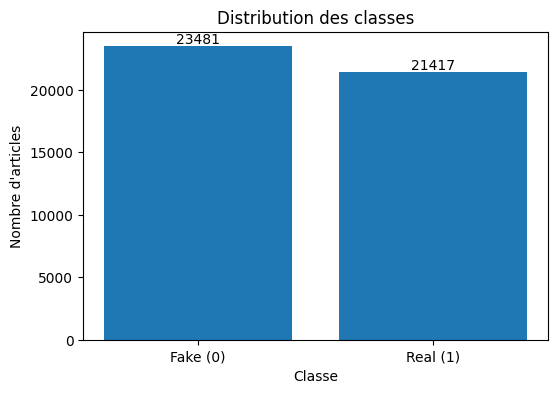

In [9]:
import matplotlib.pyplot as plt

# Compter le nombre d'articles Fake (0) et Real (1)
counts = df['label'].value_counts().reindex([0, 1])

# Créer le graphique
plt.figure(figsize=(6, 4))

plt.bar(['Fake (0)', 'Real (1)'], counts.values)

# Ajouter les valeurs au-dessus des barres
for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

# Titres
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'articles")

plt.show()

In [6]:
print(df['label'].value_counts(normalize=True).reindex([0, 1]) * 100)

label
0    52.298543
1    47.701457
Name: proportion, dtype: float64


# 2. Analyse des valeurs manquantes

In [7]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [8]:
print("Textes vides :", (df['text'] == '').sum())

print(
    "Textes vides ou espaces :",
    (df['text'].str.strip() == '').sum()
)

Textes vides : 0
Textes vides ou espaces : 631


In [9]:
print("Titres vides :", (df['title'].str.strip() == '').sum())

Titres vides : 0


# 3. Analyse des doublons

In [10]:
print("Doublons sur title :", df.duplicated(subset=['title']).sum())
print("Doublons sur text :", df.duplicated(subset=['text']).sum())
print("Doublons sur title + text :", df.duplicated(subset=['title', 'text']).sum())

Doublons sur title : 6169
Doublons sur text : 6252
Doublons sur title + text : 5793


In [11]:
conflicts = df.groupby(['title', 'text'])['label'].nunique()

print(
    "Articles identiques avec labels différents :",
    (conflicts > 1).sum()
)

Articles identiques avec labels différents : 0


In [12]:
same_text_diff_title = (
    df.groupby('text')
      .filter(lambda x: x['title'].nunique() > 1)
      .sort_values('text')
)

same_text_diff_title[['title', 'text', 'label']]

,title,text,label
11,WHERE’S HILLARY? CLINTON SPOTTED Dining Alone,,0
29466,“Your rights are NOT superior to mine!” JUDGE ...,,0
29488,A MUST WATCH! JUDGE NAPOLITANO: “For the first...,,0
29524,Joe Scarborough BERATES Mika Brzezinski Over “...,,0
29532,SHARE THIS EVERYWHERE! DISEASED REFUGEES Get S...,,0
...,...,...,...
22572,Key conservative U.S. lawmaker says making hea...,WASHINGTON (Reuters) - U.S. Representative Mar...,1
43932,Key conservative lawmaker says making headway ...,WASHINGTON (Reuters) - U.S. Representative Mar...,1
20341,ARROGANT ILLEGAL ALIEN Who Voted 5 Times In 20...,Watch:,0
38046,ARROGANT ILLEGAL ALIEN Who Voted 5 Times In 20...,Watch:,0


In [13]:
empty_text = df['text'].str.strip() == ''

print(df.loc[empty_text, 'label'].value_counts())
print(df.loc[empty_text, 'label'].value_counts(normalize=True) * 100)

label
0    630
1      1
Name: count, dtype: int64
label
0    99.841521
1     0.158479
Name: proportion, dtype: float64


In [14]:
empty_rows = df[df['text'].str.strip() == ''].copy()

print("Nombre de lignes :", len(empty_rows))

empty_rows[['title', 'label']]

Nombre de lignes : 631


,title,label
11,WHERE’S HILLARY? CLINTON SPOTTED Dining Alone,0
41,WHOA! RUSH LIMBAUGH RIPS Into Republicans Who ...,0
177,HILLARY TAKES CREDIT For The Arab Spring Disas...,0
324,CHILLING! FOX REPORTER JAMES ROSEN Recounts Be...,0
400,LIVE FEED: INAUGURATION 2017!,0
...,...,...
44530,TRUMP ANNOUNCES Two More Companies Join “Ameri...,0
44782,TUCKER CARLSON Defends Trump On Sweden Comment...,0
44868,AWESOME! HISPANIC TRUMP SUPPORTER Rips Into Pr...,0
44878,DEMOCRAT OPERATIVES Caught Planning To Bully W...,0


In [15]:
pd.set_option('display.max_colwidth', None)

empty_rows[['title', 'label']].head(50)

,title,label
11,WHERE’S HILLARY? CLINTON SPOTTED Dining Alone,0
41,WHOA! RUSH LIMBAUGH RIPS Into Republicans Who Don’t Support Trump [Audio],0
177,HILLARY TAKES CREDIT For The Arab Spring Disaster…AND SHE WANTS TO BE PRESIDENT?,0
324,CHILLING! FOX REPORTER JAMES ROSEN Recounts Being Spied on by the Obama Mafia [Video],0
400,LIVE FEED: INAUGURATION 2017!,0
424,WHICH ONE OF THESE PEOPLE Tried to Lecture the Other on the Constitution….Guesses? [VIDEO],0
431,UNREAL! OBAMA BLAMES SYRIAN CIVIL WAR ON CLIMATE CHANGE…Mocks Those Who Wear Flag Pins [VIDEO],0
458,MICHAEL FLYNN’S LAWYER Releases Statement Scorching “Highly Politicized Witch Hunt”,0
491,BOOM! JULIAN ASSANGE OF WIKILEAKS Drops A Truth Bomb On Hillary…”Disturbing That FBI Director Comey Goes Along With That Game” [Video],0
596,BLACK REPUBLICAN AND BRILLIANT NEUROSURGEON ANNOUNCES RUN FOR PREZ: Huffington Post Places Story Next To Story About Dog Living In Tree Trunk,0


# 3. Détection et suppression des doublons sur title + text

In [16]:
df = df.drop_duplicates(
    subset=['title', 'text']
).reset_index(drop=True)

print("Nouvelle taille du dataset :", df.shape)

print(
    "Doublons restants :",
    df.duplicated(subset=['title', 'text']).sum()
)

Nouvelle taille du dataset : (39105, 5)
Doublons restants : 0


# 4. Analyse de la longueur des titres et des textes

In [17]:
df['title_words'] = df['title'].str.split().str.len()
df['text_words'] = df['text'].str.split().str.len()

In [18]:
df[['title_words', 'text_words']].describe()

,title_words,text_words
count,39105.000000,39105.000000
mean,11.954047,398.522567
std,3.676330,314.998489
min,1.000000,0.000000
25%,9.000000,208.000000
50%,11.000000,366.000000
75%,14.000000,508.000000
max,42.000000,8135.000000


In [19]:
df.groupby('label')[['title_words', 'text_words']].agg(
    ['mean', 'median', 'min', 'max']
)

title_words                 text_words                 
             mean median min max        mean median min   max
label                                                        
0       14.324771   14.0   1  42  414.690306  371.0   0  8135
1        9.951172   10.0   4  20  384.863471  359.0   0  5172

In [20]:
empty_mask = df['text'].str.strip() == ''

print("Textes vides encore présents :", empty_mask.sum())

print(df.loc[empty_mask, ['title', 'text', 'label']].head())

Textes vides encore présents : 447
                                                                                     title  \
11                                           WHERE’S HILLARY? CLINTON SPOTTED Dining Alone   
41               WHOA! RUSH LIMBAUGH RIPS Into Republicans Who Don’t Support Trump [Audio]   
177       HILLARY TAKES CREDIT For The Arab Spring Disaster…AND SHE WANTS TO BE PRESIDENT?   
324  CHILLING! FOX REPORTER JAMES ROSEN Recounts Being Spied on by the Obama Mafia [Video]   
400                                                          LIVE FEED: INAUGURATION 2017!   

    text  label  
11            0  
41            0  
177           0  
324           0  
400           0  


# 5. Analyse de la variable subject

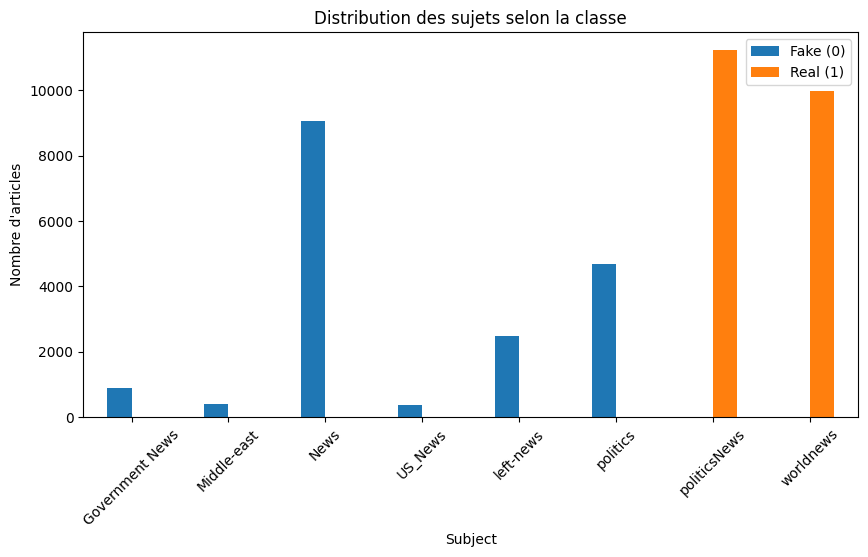

In [21]:
import matplotlib.pyplot as plt

subject_counts = pd.crosstab(df['subject'], df['label'])

subject_counts.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title("Distribution des sujets selon la classe")
plt.xlabel("Subject")
plt.ylabel("Nombre d'articles")
plt.legend(['Fake (0)', 'Real (1)'])
plt.xticks(rotation=45)
plt.show()

Observation : La variable subject est fortement corrélée avec la classe. Certaines catégories apparaissent exclusivement dans les Fake News, tandis que d'autres apparaissent uniquement dans les Real News. Cette variable pourrait donc provoquer une fuite d'information (data leakage) et permettre au modèle de prédire la classe à partir du sujet plutôt qu'à partir du contenu textuel. Pour cette raison, subject ne sera pas utilisé comme variable d'entrée du modèle.

# 6. Analyse de la variable date

In [22]:
df['date'].head(10)

0      February 13, 2017
1         April 5, 2017 
2    September 27, 2017 
3           May 22, 2017
4         June 24, 2016 
5          June 22, 2016
6           Feb 19, 2017
7            Mar 8, 2016
8     December 13, 2017 
9           May 4, 2016 
Name: date, dtype: object

In [23]:
df['date'] = df['date'].str.strip()

In [24]:
df['date_clean'] = pd.to_datetime(
    df['date'],
    format='mixed',
    errors='coerce'
)

In [25]:
df[df['date_clean'].isna()][
    ['date', 'label']
].head(20)

,date,label
6276,https://100percentfedup.com/video-hillary-asked-about-trump-i-just-want-to-eat-some-pie/,0
7199,https://fedup.wpengine.com/wp-content/uploads/2015/04/entitled.jpg,0
9008,https://fedup.wpengine.com/wp-content/uploads/2015/04/hillarystreetart.jpg,0
10529,https://100percentfedup.com/served-roy-moore-vietnamletter-veteran-sets-record-straight-honorable-decent-respectable-patriotic-commander-soldier/,0
18258,MSNBC HOST Rudely Assumes Steel Worker Would Never Let His Son Follow in His Footsteps…He Couldn’t Be More Wrong [Video],0
23910,https://100percentfedup.com/12-yr-old-black-conservative-whose-video-to-obama-went-viral-do-you-really-love-america-receives-death-threats-from-left/,0


In [26]:
print("Dates invalides :", df['date_clean'].isna().sum())

Dates invalides : 6


In [27]:
df_date = df[df['date_clean'].notna()].copy()

df_date['year'] = df_date['date_clean'].dt.year

In [28]:
pd.crosstab(df_date['year'], df_date['label'])

label,0,1
year,,
2015,1645,0
2016,9443,4698
2017,6779,16499
2018,35,0


Observation : La distribution temporelle diffère fortement entre les classes. Certaines années, notamment 2015 et 2018, ne contiennent que des articles Fake dans les données analysées, tandis que 2017 contient une majorité d’articles Real. La date pourrait donc fournir un indice indirect sur la classe. Pour éviter ce biais, la variable date ne sera pas utilisée comme entrée du modèle principal, qui sera basé sur title + text.

# 7. Analyse du vocabulaire : mots les plus fréquents dans Fake vs Real

In [29]:
fake_texts = df[df['label'] == 0]['text']
real_texts = df[df['label'] == 1]['text']

In [30]:
fake_titles = df[df['label'] == 0]['title']
real_titles = df[df['label'] == 1]['title']

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

fake_texts = df[df['label'] == 0]['text']
real_texts = df[df['label'] == 1]['text']

vectorizer_fake = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_fake = vectorizer_fake.fit_transform(fake_texts)

fake_words = pd.DataFrame({
    'word': vectorizer_fake.get_feature_names_out(),
    'frequency': X_fake.sum(axis=0).A1
}).sort_values('frequency', ascending=False)

fake_words

,word,frequency
17,trump,68087
14,said,24814
11,people,21200
12,president,20795
6,just,16744
2,donald,15286
7,like,14371
1,clinton,13529
10,obama,13382
16,time,10709


In [32]:
vectorizer_real = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_real = vectorizer_real.fit_transform(real_texts)

real_words = pd.DataFrame({
    'word': vectorizer_real.get_feature_names_out(),
    'frequency': X_real.sum(axis=0).A1
}).sort_values('frequency', ascending=False)

real_words

,word,frequency
11,said,97831
16,trump,54080
10,reuters,28661
8,president,27861
13,state,20800
3,government,18550
5,new,16740
4,house,16485
14,states,16416
9,republican,16140


In [33]:
print("Reuters dans Fake :",
      df[df['label'] == 0]['text']
      .str.contains('reuters', case=False, na=False)
      .sum())

print("Reuters dans Real :",
      df[df['label'] == 1]['text']
      .str.contains('reuters', case=False, na=False)
      .sum())

Reuters dans Fake : 220
Reuters dans Real : 21159


In [34]:
for label, name in [(0, 'Fake'), (1, 'Real')]:
    subset = df[df['label'] == label]

    n_reuters = subset['text'].str.contains(
        'reuters',
        case=False,
        na=False
    ).sum()

    percentage = (n_reuters / len(subset)) * 100

    print(f"{name}: {n_reuters} articles ({percentage:.2f}%)")

Fake: 220 articles (1.23%)
Real: 21159 articles (99.82%)


# 8. Analyse des bigrammes : Fake vs Real 

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

fake_texts = df[df['label'] == 0]['text']

bigram_fake = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2),
    max_features=20
)

X_fake_bigram = bigram_fake.fit_transform(fake_texts)

fake_bigrams = pd.DataFrame({
    'bigram': bigram_fake.get_feature_names_out(),
    'frequency': X_fake_bigram.sum(axis=0).A1
}).sort_values('frequency', ascending=False)

fake_bigrams

,bigram,frequency
1,donald trump,14026
2,featured image,7691
5,hillary clinton,5431
18,white house,5199
16,twitter com,5125
17,united states,4955
7,pic twitter,4909
4,getty images,4022
8,president obama,3450
6,new york,3154


In [36]:
real_texts = df[df['label'] == 1]['text']

bigram_real = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2),
    max_features=20
)

X_real_bigram = bigram_real.fit_transform(real_texts)

real_bigrams = pd.DataFrame({
    'bigram': bigram_real.get_feature_names_out(),
    'frequency': X_real_bigram.sum(axis=0).A1
}).sort_values('frequency', ascending=False)

real_bigrams

,bigram,frequency
17,united states,12019
1,donald trump,10087
19,white house,8329
18,washington reuters,6640
7,president donald,5867
5,north korea,5504
4,new york,4714
8,prime minister,4106
10,said statement,3895
15,trump said,3522


# 9. Analyse des titres : Fake vs Real 

In [37]:
fake_titles = df[df['label'] == 0]['title']
real_titles = df[df['label'] == 1]['title']

In [38]:
title_vec_fake = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_title_fake = title_vec_fake.fit_transform(fake_titles)

fake_title_words = pd.DataFrame({
    'word': title_vec_fake.get_feature_names_out(),
    'frequency': X_title_fake.sum(axis=0).A1
}).sort_values('frequency', ascending=False)

fake_title_words

,word,frequency
15,trump,7779
17,video,6398
13,obama,1741
18,watch,1561
7,hillary,1542
8,just,1252
3,clinton,827
14,president,823
4,donald,748
6,gop,737


In [39]:
title_vec_real = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_title_real = title_vec_real.fit_transform(real_titles)

real_title_words = pd.DataFrame({
    'word': title_vec_real.get_feature_names_out(),
    'frequency': X_title_real.sum(axis=0).A1
}).sort_values('frequency', ascending=False)

real_title_words

,word,frequency
17,trump,5511
13,says,2959
6,house,1443
12,russia,965
9,north,909
7,korea,883
8,new,871
19,white,812
0,china,774
14,senate,756


# 10. Analyse stylistique des titres

Moyennes des caractéristiques stylistiques :


,exclamation_count,question_count,uppercase_words,title_words
label,,,,
0,0.131394,0.060922,2.902055,14.324771
1,0.000896,0.006605,0.386423,9.951172


,exclamation_count,question_count,uppercase_words,title_words
Fake (0),0.131394,0.060922,2.902055,14.324771
Real (1),0.000896,0.006605,0.386423,9.951172


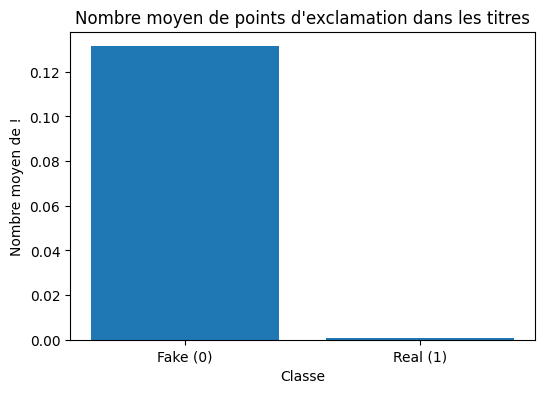

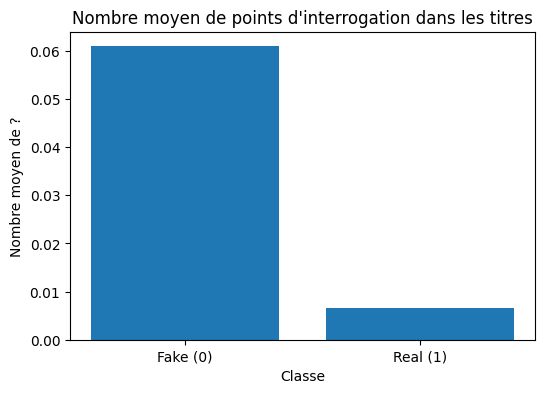

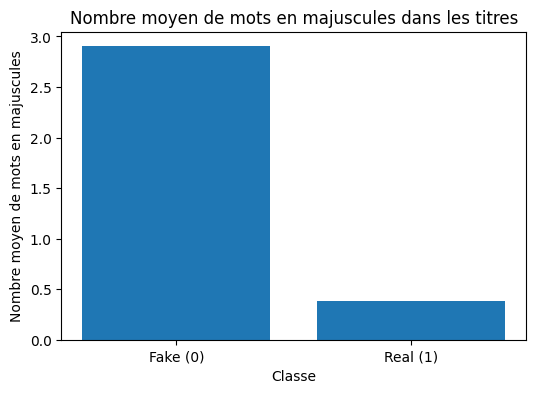

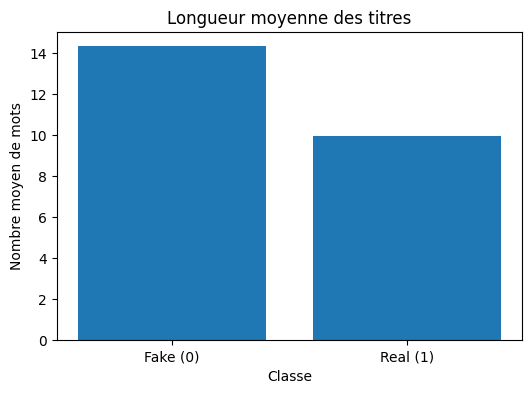

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Créer des variables stylistiques
# =========================

# Nombre de points d'exclamation
df['exclamation_count'] = df['title'].str.count('!')

# Nombre de points d'interrogation
df['question_count'] = df['title'].str.count(r'\?')

# Nombre de mots entièrement en majuscules
df['uppercase_words'] = df['title'].apply(
    lambda x: sum(word.isupper() for word in x.split())
)

# Nombre de mots dans le titre
df['title_words'] = df['title'].str.split().str.len()


# =========================
# 2. Statistiques moyennes par classe
# =========================

style_summary = df.groupby('label')[
    ['exclamation_count',
     'question_count',
     'uppercase_words',
     'title_words']
].mean()

print("Moyennes des caractéristiques stylistiques :")
display(style_summary)


# =========================
# 3. Ajouter des noms plus lisibles
# =========================

style_summary_plot = style_summary.copy()

style_summary_plot.index = [
    'Fake (0)',
    'Real (1)'
]

display(style_summary_plot)


# =========================
# 4. Graphique : points d'exclamation
# =========================

plt.figure(figsize=(6,4))

plt.bar(
    style_summary_plot.index,
    style_summary_plot['exclamation_count']
)

plt.title("Nombre moyen de points d'exclamation dans les titres")
plt.xlabel("Classe")
plt.ylabel("Nombre moyen de !")

plt.show()


# =========================
# 5. Graphique : points d'interrogation
# =========================

plt.figure(figsize=(6,4))

plt.bar(
    style_summary_plot.index,
    style_summary_plot['question_count']
)

plt.title("Nombre moyen de points d'interrogation dans les titres")
plt.xlabel("Classe")
plt.ylabel("Nombre moyen de ?")

plt.show()


# =========================
# 6. Graphique : mots en majuscules
# =========================

plt.figure(figsize=(6,4))

plt.bar(
    style_summary_plot.index,
    style_summary_plot['uppercase_words']
)

plt.title("Nombre moyen de mots en majuscules dans les titres")
plt.xlabel("Classe")
plt.ylabel("Nombre moyen de mots en majuscules")

plt.show()


# =========================
# 7. Graphique : longueur des titres
# =========================

plt.figure(figsize=(6,4))

plt.bar(
    style_summary_plot.index,
    style_summary_plot['title_words']
)

plt.title("Longueur moyenne des titres")
plt.xlabel("Classe")
plt.ylabel("Nombre moyen de mots")

plt.show()

Observation : L’analyse stylistique met en évidence des différences importantes entre les titres Fake et Real. Les titres Fake sont en moyenne plus longs, contiennent davantage de mots entièrement en majuscules et utilisent plus fréquemment les points d’exclamation et d’interrogation. Ces caractéristiques peuvent constituer des indices stylistiques permettant au modèle de distinguer les classes sans nécessairement analyser la véracité du contenu.

# fisher 

In [41]:
import pandas as pd
import numpy as np

# Variables à tester
features = [
    'exclamation_count',
    'question_count',
    'uppercase_words',
    'title_words',
    'text_words'
]

# Fonction Fisher Score pour 2 classes
def fisher_score(feature, target):
    
    class_0 = feature[target == 0]
    class_1 = feature[target == 1]
    
    # Moyennes
    mean_0 = class_0.mean()
    mean_1 = class_1.mean()
    
    # Variances
    var_0 = class_0.var(ddof=0)
    var_1 = class_1.var(ddof=0)
    
    denominator = var_0 + var_1
    
    # Éviter division par zéro
    if denominator == 0:
        return 0
    
    score = ((mean_0 - mean_1) ** 2) / denominator
    
    return score


# Calculer le Fisher Score pour chaque variable
results = []

for feature in features:
    
    score = fisher_score(
        df[feature],
        df['label']
    )
    
    results.append({
        'Feature': feature,
        'Fisher_Score': score
    })


# Créer le tableau final
fisher_results = pd.DataFrame(results)

# Trier du score le plus grand au plus petit
fisher_results = fisher_results.sort_values(
    by='Fisher_Score',
    ascending=False
)

fisher_results

,Feature,Fisher_Score
3,title_words,1.027663
2,uppercase_words,0.735541
0,exclamation_count,0.119241
1,question_count,0.041189
4,text_words,0.004395


In [42]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Transformer les textes en TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    min_df=5
)

X_tfidf = vectorizer.fit_transform(df['text'].fillna(''))

y = df['label'].values

# Noms des mots
words = vectorizer.get_feature_names_out()

print("Nombre de mots analysés :", len(words))

Nombre de mots analysés : 20000


In [43]:
# Séparer Fake (0) et Real (1)
X_fake = X_tfidf[y == 0]
X_real = X_tfidf[y == 1]

# Moyennes TF-IDF de chaque mot
mean_fake = np.asarray(X_fake.mean(axis=0)).ravel()
mean_real = np.asarray(X_real.mean(axis=0)).ravel()

# Variances
mean_sq_fake = np.asarray(X_fake.power(2).mean(axis=0)).ravel()
mean_sq_real = np.asarray(X_real.power(2).mean(axis=0)).ravel()

var_fake = mean_sq_fake - mean_fake**2
var_real = mean_sq_real - mean_real**2

# Fisher Score
fisher_scores = (
    (mean_fake - mean_real) ** 2
    /
    (var_fake + var_real + 1e-10)
)

# Tableau
fisher_words = pd.DataFrame({
    'word': words,
    'Fisher_Score': fisher_scores,
    'mean_fake': mean_fake,
    'mean_real': mean_real
})

# Trier
fisher_words = fisher_words.sort_values(
    'Fisher_Score',
    ascending=False
)

fisher_words.head(30)

,word,Fisher_Score,mean_fake,mean_real
15267,reuters,2.455921,0.000270,0.029138
15701,said,1.125811,0.017515,0.062221
7032,featured,0.673577,0.012741,0.000109
9047,image,0.641562,0.013881,0.000352
10016,just,0.306168,0.020423,0.004083
7848,getty,0.261394,0.008245,0.000002
9049,images,0.223281,0.008328,0.000342
10652,like,0.215438,0.018081,0.004338
19457,washington,0.195241,0.004310,0.018328
11618,minister,0.148959,0.001060,0.014383


In [44]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# 1. Transformer les titres en TF-IDF
# =========================

vectorizer_title = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    min_df=5
)

X_title = vectorizer_title.fit_transform(
    df['title'].fillna('')
)

y = df['label'].values

words_title = vectorizer_title.get_feature_names_out()

print("Nombre de mots analysés :", len(words_title))


# =========================
# 2. Séparer Fake et Real
# =========================

X_fake = X_title[y == 0]
X_real = X_title[y == 1]


# =========================
# 3. Calculer les moyennes TF-IDF
# =========================

mean_fake = np.asarray(
    X_fake.mean(axis=0)
).ravel()

mean_real = np.asarray(
    X_real.mean(axis=0)
).ravel()


# =========================
# 4. Calculer les variances
# =========================

mean_sq_fake = np.asarray(
    X_fake.power(2).mean(axis=0)
).ravel()

mean_sq_real = np.asarray(
    X_real.power(2).mean(axis=0)
).ravel()

var_fake = mean_sq_fake - mean_fake**2
var_real = mean_sq_real - mean_real**2


# =========================
# 5. Fisher Score
# =========================

fisher_scores = (
    (mean_fake - mean_real) ** 2
    /
    (var_fake + var_real + 1e-10)
)


# =========================
# 6. Tableau des résultats
# =========================

fisher_title_words = pd.DataFrame({
    'word': words_title,
    'Fisher_Score': fisher_scores,
    'mean_fake': mean_fake,
    'mean_real': mean_real
})

fisher_title_words = fisher_title_words.sort_values(
    'Fisher_Score',
    ascending=False
)

fisher_title_words.head(30)

Nombre de mots analysés : 7551


,word,Fisher_Score,mean_fake,mean_real
7227,video,0.485380,0.049384,0.000257
5894,says,0.099687,0.004126,0.027839
7328,watch,0.086260,0.018082,0.000340
3181,hillary,0.076412,0.018183,0.000570
3661,just,0.067656,0.015645,0.000304
2912,gop,0.039831,0.010392,0.000104
2102,donald,0.033090,0.011219,0.000818
4552,north,0.031890,0.001165,0.011338
923,breaking,0.031612,0.008370,0.000121
3755,korea,0.031360,0.000781,0.011284


# Expérience 1 — Unigrammes uniquement

# Cellule 1 — Imports

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    StratifiedKFold
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef
)

# Sélectionner title et label

In [46]:
X = df['title'].fillna('')
y = df['label']

print("Nombre d'articles :", len(X))

print("\nDistribution des classes :")
print(y.value_counts())

Nombre d'articles : 39105

Distribution des classes :
label
1    21197
0    17908
Name: count, dtype: int64


# Train / Validation / Test

In [47]:
# 70% Train / 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Les 30% deviennent :
# 15% Validation
# 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

Train      : 27373
Validation : 5866
Test       : 5866


# TF-IDF avec unigrammes

In [48]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 1),
    min_df=2,
    max_features=20000
)

# TF-IDF apprend uniquement sur Train
X_train_tfidf = tfidf.fit_transform(X_train)

# Validation et Test utilisent le vocabulaire appris sur Train
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF      :", X_train_tfidf.shape)
print("Validation TF-IDF :", X_val_tfidf.shape)
print("Test TF-IDF       :", X_test_tfidf.shape)

Train TF-IDF      : (27373, 11239)
Validation TF-IDF : (5866, 11239)
Test TF-IDF       : (5866, 11239)


# Logistic Regression

In [49]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Entraînement terminé.")

Entraînement terminé.


In [50]:
# Classes prédites
y_pred_train = model.predict(X_train_tfidf)
y_pred_val = model.predict(X_val_tfidf)
y_pred_test = model.predict(X_test_tfidf)

# Probabilités de la classe Real = 1
y_prob_train = model.predict_proba(X_train_tfidf)[:, 1]
y_prob_val = model.predict_proba(X_val_tfidf)[:, 1]
y_prob_test = model.predict_proba(X_test_tfidf)[:, 1]

# Fonction pour toutes les métriques

In [51]:
def get_metrics(y_true, y_pred, y_prob):

    return {
        'Accuracy': accuracy_score(
            y_true,
            y_pred
        ),

        'Balanced Accuracy': balanced_accuracy_score(
            y_true,
            y_pred
        ),

        'Precision Macro': precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        'Recall Macro': recall_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        'F1 Macro': f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),

        'Precision Weighted': precision_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0
        ),

        'Recall Weighted': recall_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0
        ),

        'F1 Weighted': f1_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=0
        ),

        'ROC-AUC': roc_auc_score(
            y_true,
            y_prob
        ),

        'Log Loss': log_loss(
            y_true,
            y_prob
        ),

        'MCC': matthews_corrcoef(
            y_true,
            y_pred
        )
    }

In [52]:
results = pd.DataFrame({

    'Train': get_metrics(
        y_train,
        y_pred_train,
        y_prob_train
    ),

    'Validation': get_metrics(
        y_val,
        y_pred_val,
        y_prob_val
    ),

    'Test': get_metrics(
        y_test,
        y_pred_test,
        y_prob_test
    )

}).T

display(results.round(4))

,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC,Log Loss,MCC
Train,0.9591,0.9574,0.9605,0.9574,0.9587,0.9595,0.9591,0.9590,0.9930,0.1794,0.9179
Validation,0.9344,0.9320,0.9362,0.9320,0.9336,0.9350,0.9344,0.9342,0.9816,0.2144,0.8682
Test,0.9383,0.9354,0.9412,0.9354,0.9375,0.9395,0.9383,0.9381,0.9862,0.2039,0.8766


Confusion Matrix :
[[2421  266]
 [  96 3083]]


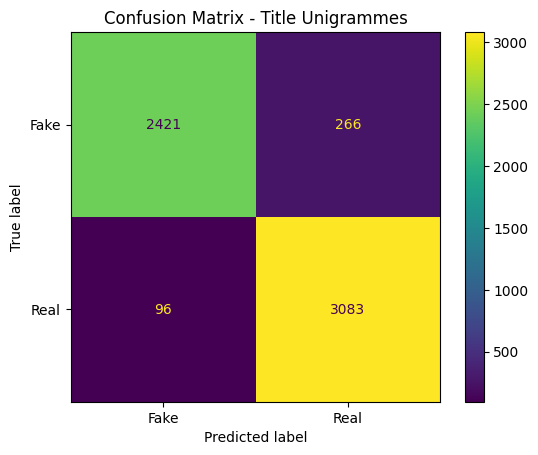

In [53]:
cm = confusion_matrix(
    y_test,
    y_pred_test
)

print("Confusion Matrix :")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fake', 'Real']
)

disp.plot()

plt.title(
    "Confusion Matrix - Title Unigrammes"
)

plt.show()

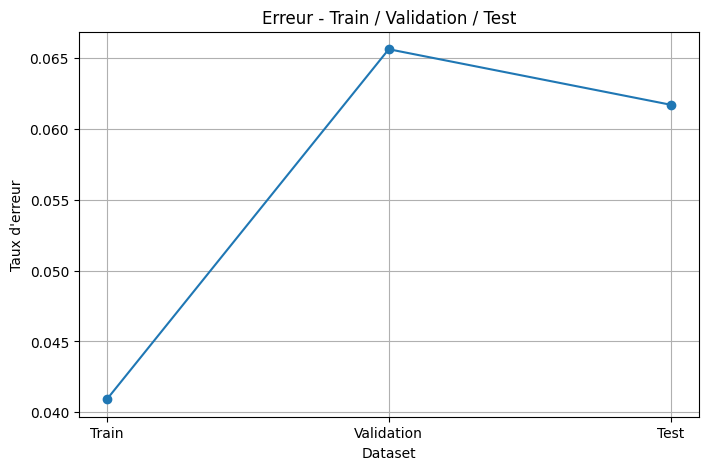

Erreur Train      : 0.0409
Erreur Validation : 0.0656
Erreur Test       : 0.0617


In [54]:
train_error = 1 - accuracy_score(
    y_train,
    y_pred_train
)

val_error = 1 - accuracy_score(
    y_val,
    y_pred_val
)

test_error = 1 - accuracy_score(
    y_test,
    y_pred_test
)

errors = [
    train_error,
    val_error,
    test_error
]

sets = [
    'Train',
    'Validation',
    'Test'
]

plt.figure(figsize=(8, 5))

plt.plot(
    sets,
    errors,
    marker='o'
)

plt.ylabel("Taux d'erreur")
plt.xlabel("Dataset")

plt.title(
    "Erreur - Train / Validation / Test"
)

plt.grid()

plt.show()

print(
    "Erreur Train      :",
    round(train_error, 4)
)

print(
    "Erreur Validation :",
    round(val_error, 4)
)

print(
    "Erreur Test       :",
    round(test_error, 4)
)

In [55]:
pipeline = Pipeline([

    (
        'tfidf',
        TfidfVectorizer(
            stop_words='english',
            ngram_range=(1, 1),
            min_df=2,
            max_features=20000
        )
    ),

    (
        'logistic',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )

])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X_train,
    y_train,

    train_sizes=np.linspace(
        0.1,
        1.0,
        6
    ),

    cv=cv,

    scoring='accuracy',

    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

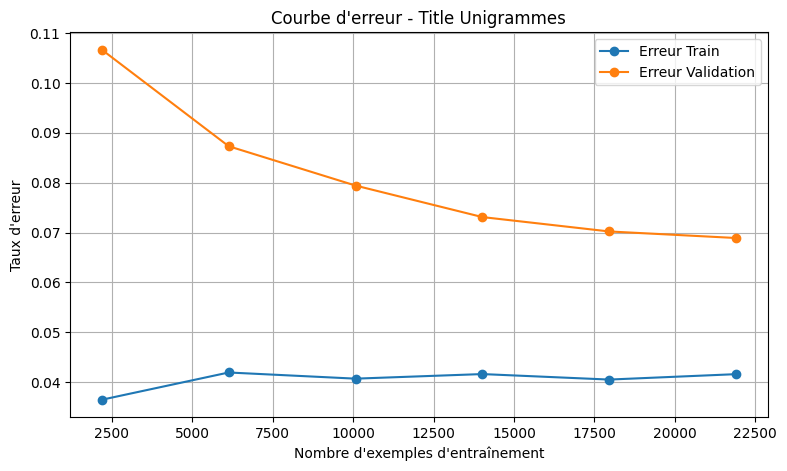

In [56]:
train_error_curve = 1 - train_mean
val_error_curve = 1 - val_mean

plt.figure(figsize=(9, 5))

plt.plot(
    train_sizes,
    train_error_curve,
    marker='o',
    label='Erreur Train'
)

plt.plot(
    train_sizes,
    val_error_curve,
    marker='o',
    label='Erreur Validation'
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Courbe d'erreur - Title Unigrammes"
)

plt.legend()
plt.grid()

plt.show()

TITLE
  ↓
Bigrammes (2,2)
  ↓
TF-IDF
  ↓
Logistic Regression
  ↓
Fake / Real

In [57]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    learning_curve,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [58]:
# On garde exactement le même Train / Validation / Test
# que pour l'expérience unigrammes.

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

print("\nExemple de titre :")
print(X_train.iloc[0])

Train      : 27373
Validation : 5866
Test       : 5866

Exemple de titre :
 John McCain Brushes Off Hispanic Voters, Says The GOP Doesn’t Need Them To Win


In [59]:
tfidf_bi = TfidfVectorizer(
    stop_words='english',
    ngram_range=(2, 2),
    min_df=2,
    max_features=20000
)

# ==========================================
# Mesurer le temps TF-IDF
# ==========================================

start_tfidf = time.perf_counter()

X_train_bi = tfidf_bi.fit_transform(X_train)

X_val_bi = tfidf_bi.transform(X_val)
X_test_bi = tfidf_bi.transform(X_test)

end_tfidf = time.perf_counter()

tfidf_time = end_tfidf - start_tfidf

print("Train TF-IDF      :", X_train_bi.shape)
print("Validation TF-IDF :", X_val_bi.shape)
print("Test TF-IDF       :", X_test_bi.shape)

print(
    f"\nTemps TF-IDF : {tfidf_time:.4f} secondes"
)

Train TF-IDF      : (27373, 20000)
Validation TF-IDF : (5866, 20000)
Test TF-IDF       : (5866, 20000)

Temps TF-IDF : 1.0973 secondes


In [60]:
model_bi = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ==========================================
# Temps d'entraînement Logistic Regression
# ==========================================

start_training = time.perf_counter()

model_bi.fit(
    X_train_bi,
    y_train
)

end_training = time.perf_counter()

training_time = end_training - start_training

print(
    f"Temps Logistic Regression : "
    f"{training_time:.4f} secondes"
)

Temps Logistic Regression : 0.9016 secondes


In [61]:
total_training_time = (
    tfidf_time +
    training_time
)

print(
    f"Temps TF-IDF               : {tfidf_time:.4f} s"
)

print(
    f"Temps Logistic Regression  : {training_time:.4f} s"
)

print(
    f"Temps total entraînement   : {total_training_time:.4f} s"
)

Temps TF-IDF               : 1.0973 s
Temps Logistic Regression  : 0.9016 s
Temps total entraînement   : 1.9989 s


In [62]:
# Classes prédites

pred_train_bi = model_bi.predict(
    X_train_bi
)

pred_val_bi = model_bi.predict(
    X_val_bi
)

pred_test_bi = model_bi.predict(
    X_test_bi
)


# Probabilités de Real = 1

prob_train_bi = model_bi.predict_proba(
    X_train_bi
)[:, 1]

prob_val_bi = model_bi.predict_proba(
    X_val_bi
)[:, 1]

prob_test_bi = model_bi.predict_proba(
    X_test_bi
)[:, 1]

In [63]:
def get_metrics(y_true, y_pred, y_prob):

    return {

        'Accuracy':
            accuracy_score(
                y_true,
                y_pred
            ),

        'Balanced Accuracy':
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        'Precision Macro':
            precision_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Recall Macro':
            recall_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'F1 Macro':
            f1_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Precision Weighted':
            precision_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'Recall Weighted':
            recall_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'F1 Weighted':
            f1_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'ROC-AUC':
            roc_auc_score(
                y_true,
                y_prob
            ),

        'Log Loss':
            log_loss(
                y_true,
                y_prob
            ),

        'MCC':
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }

In [64]:
results_bi = pd.DataFrame({

    'Train': get_metrics(
        y_train,
        pred_train_bi,
        prob_train_bi
    ),

    'Validation': get_metrics(
        y_val,
        pred_val_bi,
        prob_val_bi
    ),

    'Test': get_metrics(
        y_test,
        pred_test_bi,
        prob_test_bi
    )

}).T

display(
    results_bi.round(4)
)

,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC,Log Loss,MCC
Train,0.9370,0.9335,0.9412,0.9335,0.9361,0.9389,0.9370,0.9367,0.9814,0.3455,0.8747
Validation,0.8524,0.8445,0.8637,0.8445,0.8483,0.8598,0.8524,0.8504,0.9236,0.4173,0.7080
Test,0.8493,0.8408,0.8630,0.8408,0.8447,0.8586,0.8493,0.8469,0.9256,0.4145,0.7034


In [65]:
print(
    classification_report(
        y_test,
        pred_test_bi,
        target_names=[
            'Fake',
            'Real'
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

        Fake     0.9156    0.7391    0.8180      2687
        Real     0.8104    0.9424    0.8714      3179

    accuracy                         0.8493      5866
   macro avg     0.8630    0.8408    0.8447      5866
weighted avg     0.8586    0.8493    0.8469      5866



Confusion Matrix :
[[1986  701]
 [ 183 2996]]


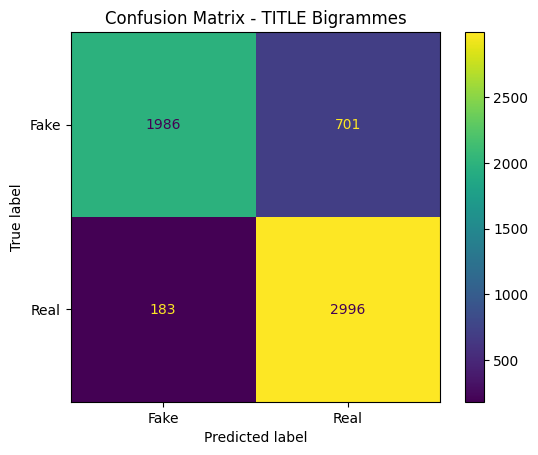

In [66]:
cm_bi = confusion_matrix(
    y_test,
    pred_test_bi
)

print(
    "Confusion Matrix :"
)

print(cm_bi)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bi,
    display_labels=[
        'Fake',
        'Real'
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - TITLE Bigrammes"
)

plt.show()

In [67]:
train_error_bi = (
    1 -
    accuracy_score(
        y_train,
        pred_train_bi
    )
)

val_error_bi = (
    1 -
    accuracy_score(
        y_val,
        pred_val_bi
    )
)

test_error_bi = (
    1 -
    accuracy_score(
        y_test,
        pred_test_bi
    )
)

print(
    "Erreur Train      :",
    round(train_error_bi, 4)
)

print(
    "Erreur Validation :",
    round(val_error_bi, 4)
)

print(
    "Erreur Test       :",
    round(test_error_bi, 4)
)

Erreur Train      : 0.063
Erreur Validation : 0.1476
Erreur Test       : 0.1507


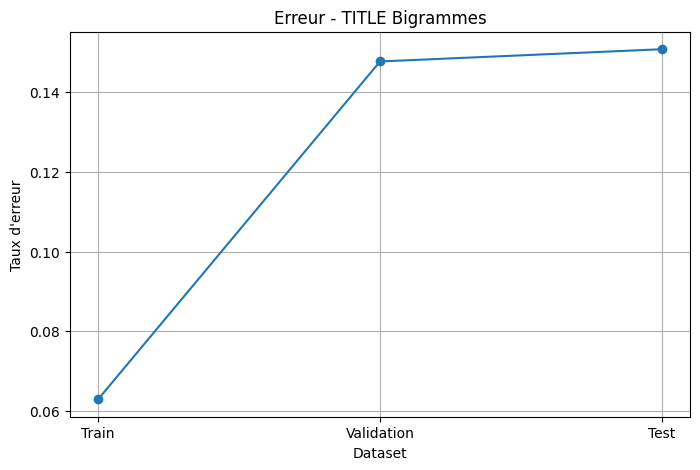

In [68]:
sets = [
    'Train',
    'Validation',
    'Test'
]

errors = [
    train_error_bi,
    val_error_bi,
    test_error_bi
]

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    sets,
    errors,
    marker='o'
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Erreur - TITLE Bigrammes"
)

plt.grid()

plt.show()

In [69]:
pipeline_bi = Pipeline([

    (
        'tfidf',
        TfidfVectorizer(
            stop_words='english',
            ngram_range=(2, 2),
            min_df=2,
            max_features=20000
        )
    ),

    (
        'logistic',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )

])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [70]:
start_learning_curve = time.perf_counter()

train_sizes_bi, train_scores_bi, val_scores_bi = learning_curve(
    pipeline_bi,

    X_train,
    y_train,

    train_sizes=np.linspace(
        0.1,
        1.0,
        6
    ),

    cv=cv,

    scoring='accuracy',

    n_jobs=-1
)

end_learning_curve = time.perf_counter()

learning_curve_time = (
    end_learning_curve -
    start_learning_curve
)

print(
    f"Temps de calcul Learning Curve : "
    f"{learning_curve_time:.2f} secondes"
)

Temps de calcul Learning Curve : 9.87 secondes


In [71]:
train_mean_bi = train_scores_bi.mean(
    axis=1
)

train_std_bi = train_scores_bi.std(
    axis=1
)

val_mean_bi = val_scores_bi.mean(
    axis=1
)

val_std_bi = val_scores_bi.std(
    axis=1
)

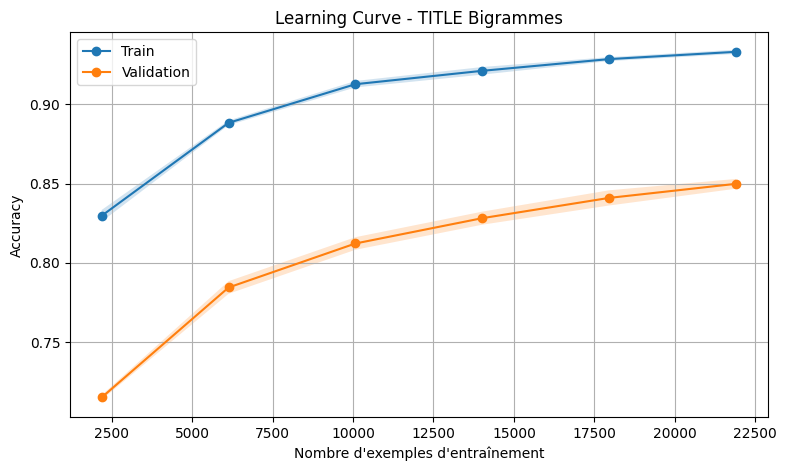

In [72]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes_bi,
    train_mean_bi,
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes_bi,
    val_mean_bi,
    marker='o',
    label='Validation'
)

plt.fill_between(
    train_sizes_bi,
    train_mean_bi - train_std_bi,
    train_mean_bi + train_std_bi,
    alpha=0.2
)

plt.fill_between(
    train_sizes_bi,
    val_mean_bi - val_std_bi,
    val_mean_bi + val_std_bi,
    alpha=0.2
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Learning Curve - TITLE Bigrammes"
)

plt.legend()

plt.grid()

plt.show()

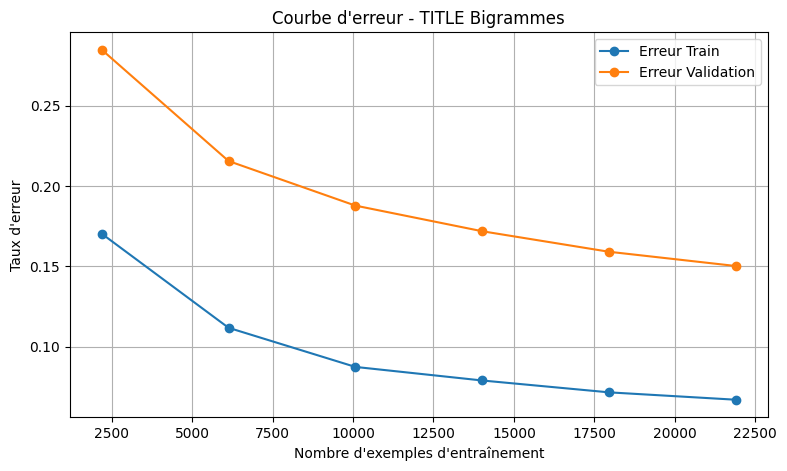

In [73]:
train_error_curve_bi = (
    1 - train_mean_bi
)

val_error_curve_bi = (
    1 - val_mean_bi
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes_bi,
    train_error_curve_bi,
    marker='o',
    label='Erreur Train'
)

plt.plot(
    train_sizes_bi,
    val_error_curve_bi,
    marker='o',
    label='Erreur Validation'
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Courbe d'erreur - TITLE Bigrammes"
)

plt.legend()

plt.grid()

plt.show()

In [74]:
train_final_bi = (
    train_mean_bi[-1]
)

val_final_bi = (
    val_mean_bi[-1]
)

gap_bi = (
    train_final_bi -
    val_final_bi
)

print(
    "Accuracy Train CV finale      :",
    round(train_final_bi, 4)
)

print(
    "Accuracy Validation CV finale :",
    round(val_final_bi, 4)
)

print(
    "Gap Train - Validation        :",
    round(gap_bi, 4)
)

Accuracy Train CV finale      : 0.9331
Accuracy Validation CV finale : 0.8498
Gap Train - Validation        : 0.0833


In [75]:
new_title = """
Trump says new government policy will be announced tomorrow
"""

print(new_title)


Trump says new government policy will be announced tomorrow



In [76]:
start_prediction = time.perf_counter()

# Transformer le nouveau titre
new_title_tfidf = tfidf_bi.transform(
    [new_title]
)

# Prédiction
prediction = model_bi.predict(
    new_title_tfidf
)[0]

# Probabilité
probability = model_bi.predict_proba(
    new_title_tfidf
)[0]

end_prediction = time.perf_counter()

prediction_time = (
    end_prediction -
    start_prediction
)

print(
    "Prédiction :",
    "Real" if prediction == 1 else "Fake"
)

print(
    f"Probabilité Fake : {probability[0]:.4f}"
)

print(
    f"Probabilité Real : {probability[1]:.4f}"
)

print(
    f"\nTemps d'une prédiction : "
    f"{prediction_time:.6f} seconde"
)

print(
    f"Temps d'une prédiction : "
    f"{prediction_time * 1000:.3f} ms"
)

Prédiction : Real
Probabilité Fake : 0.0592
Probabilité Real : 0.9408

Temps d'une prédiction : 0.001695 seconde
Temps d'une prédiction : 1.695 ms


In [77]:
# ============================================================
# CELLULE 1
# TEXT + UNIGRAMMES + TF-IDF + LOGISTIC REGRESSION
# Préparation + entraînement + temps
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    StratifiedKFold
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. TEXT + LABEL
# ============================================================

X = df['text'].fillna('')
y = df['label']

print("Nombre total d'articles :", len(X))


# ============================================================
# 2. TRAIN / VALIDATION / TEST
# 70% / 15% / 15%
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n===== TAILLE DES DATASETS =====")

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))


print("\n===== DISTRIBUTION TRAIN =====")
print(y_train.value_counts(normalize=True))

print("\n===== DISTRIBUTION VALIDATION =====")
print(y_val.value_counts(normalize=True))

print("\n===== DISTRIBUTION TEST =====")
print(y_test.value_counts(normalize=True))


# ============================================================
# 3. TF-IDF — UNIGRAMMES
# ============================================================

tfidf_text_uni = TfidfVectorizer(
    stop_words='english',

    # uniquement mots isolés
    ngram_range=(1, 1),

    min_df=2,
    max_features=20000
)


# ============================================================
# 4. MESURER LE TEMPS TF-IDF
# ============================================================

start_tfidf = time.perf_counter()

# Apprentissage TF-IDF uniquement sur Train
X_train_tfidf = tfidf_text_uni.fit_transform(
    X_train
)

# Validation et Test :
# uniquement transform
X_val_tfidf = tfidf_text_uni.transform(
    X_val
)

X_test_tfidf = tfidf_text_uni.transform(
    X_test
)

end_tfidf = time.perf_counter()

tfidf_time = (
    end_tfidf - start_tfidf
)


print("\n===== SHAPES TF-IDF =====")

print(
    "Train      :",
    X_train_tfidf.shape
)

print(
    "Validation :",
    X_val_tfidf.shape
)

print(
    "Test       :",
    X_test_tfidf.shape
)


# ============================================================
# 5. LOGISTIC REGRESSION
# ============================================================

model_text_uni = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ============================================================
# 6. TEMPS D'ENTRAÎNEMENT DU MODÈLE
# ============================================================

start_training = time.perf_counter()

model_text_uni.fit(
    X_train_tfidf,
    y_train
)

end_training = time.perf_counter()

training_time = (
    end_training - start_training
)

total_training_time = (
    tfidf_time +
    training_time
)


# ============================================================
# 7. TEMPS
# ============================================================

print("\n===== TEMPS =====")

print(
    f"Temps TF-IDF              : "
    f"{tfidf_time:.4f} secondes"
)

print(
    f"Temps Logistic Regression : "
    f"{training_time:.4f} secondes"
)

print(
    f"Temps total entraînement  : "
    f"{total_training_time:.4f} secondes"
)


# ============================================================
# 8. PRÉDICTIONS TRAIN / VALIDATION / TEST
# ============================================================

pred_train = model_text_uni.predict(
    X_train_tfidf
)

pred_val = model_text_uni.predict(
    X_val_tfidf
)

pred_test = model_text_uni.predict(
    X_test_tfidf
)


# Probabilités de la classe Real = 1

prob_train = model_text_uni.predict_proba(
    X_train_tfidf
)[:, 1]

prob_val = model_text_uni.predict_proba(
    X_val_tfidf
)[:, 1]

prob_test = model_text_uni.predict_proba(
    X_test_tfidf
)[:, 1]

print("\nEntraînement et prédictions terminés.")

Nombre total d'articles : 39105

===== TAILLE DES DATASETS =====
Train      : 27373
Validation : 5866
Test       : 5866

===== DISTRIBUTION TRAIN =====
label
1    0.542067
0    0.457933
Name: proportion, dtype: float64

===== DISTRIBUTION VALIDATION =====
label
1    0.542107
0    0.457893
Name: proportion, dtype: float64

===== DISTRIBUTION TEST =====
label
1    0.541937
0    0.458063
Name: proportion, dtype: float64

===== SHAPES TF-IDF =====
Train      : (27373, 20000)
Validation : (5866, 20000)
Test       : (5866, 20000)

===== TEMPS =====
Temps TF-IDF              : 11.0208 secondes
Temps Logistic Regression : 1.0106 secondes
Temps total entraînement  : 12.0313 secondes

Entraînement et prédictions terminés.


===== TOUTES LES MÉTRIQUES =====


,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC,Log Loss,MCC
Train,0.9893,0.9889,0.9897,0.9889,0.9892,0.9894,0.9893,0.9893,0.9991,0.0826,0.9785
Validation,0.9818,0.9812,0.9821,0.9812,0.9816,0.9818,0.9818,0.9818,0.9976,0.0949,0.9633
Test,0.9857,0.9851,0.9861,0.9851,0.9856,0.9857,0.9857,0.9857,0.9981,0.0908,0.9712



===== CLASSIFICATION REPORT — TEST =====

              precision    recall  f1-score   support

        Fake     0.9902    0.9784    0.9843      2687
        Real     0.9819    0.9918    0.9869      3179

    accuracy                         0.9857      5866
   macro avg     0.9861    0.9851    0.9856      5866
weighted avg     0.9857    0.9857    0.9857      5866


===== CONFUSION MATRIX =====
[[2629   58]
 [  26 3153]]


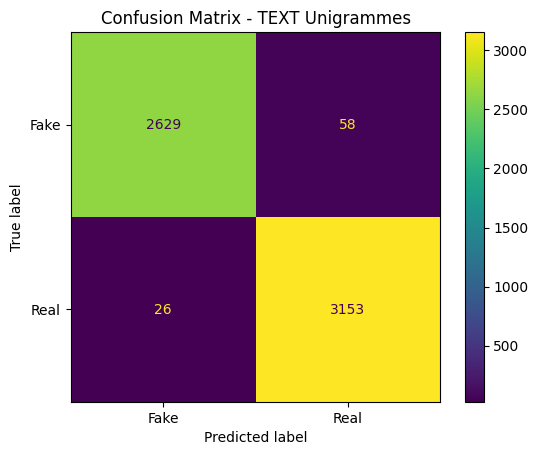


===== TAUX D'ERREUR =====
Erreur Train      : 0.0107
Erreur Validation : 0.0182
Erreur Test       : 0.0143


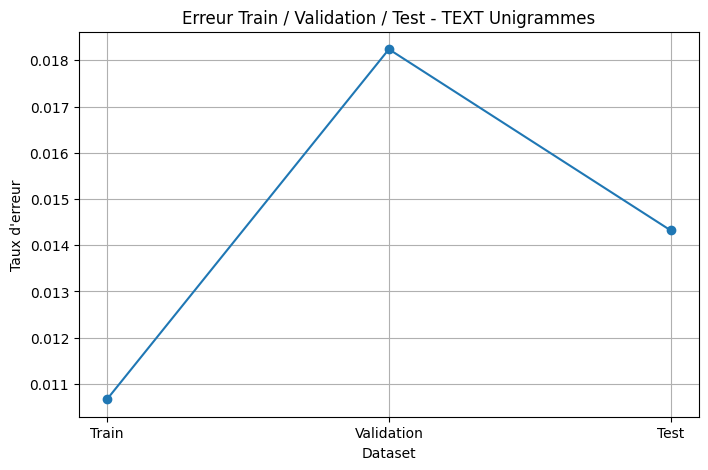


===== GAP TRAIN / VALIDATION =====
Accuracy Train      : 0.9893
Accuracy Validation : 0.9818
Gap                 : 0.0076


In [78]:
# ============================================================
# CELLULE 2
# MÉTRIQUES + CONFUSION MATRIX + ERREURS
# ============================================================


# ============================================================
# 1. FONCTION POUR CALCULER LES MÉTRIQUES
# ============================================================

def get_metrics(y_true, y_pred, y_prob):

    return {

        'Accuracy':
            accuracy_score(
                y_true,
                y_pred
            ),

        'Balanced Accuracy':
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        'Precision Macro':
            precision_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Recall Macro':
            recall_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'F1 Macro':
            f1_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Precision Weighted':
            precision_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'Recall Weighted':
            recall_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'F1 Weighted':
            f1_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'ROC-AUC':
            roc_auc_score(
                y_true,
                y_prob
            ),

        'Log Loss':
            log_loss(
                y_true,
                y_prob
            ),

        'MCC':
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }


# ============================================================
# 2. TABLEAU TRAIN / VALIDATION / TEST
# ============================================================

results_text_uni = pd.DataFrame({

    'Train': get_metrics(
        y_train,
        pred_train,
        prob_train
    ),

    'Validation': get_metrics(
        y_val,
        pred_val,
        prob_val
    ),

    'Test': get_metrics(
        y_test,
        pred_test,
        prob_test
    )

}).T


print("===== TOUTES LES MÉTRIQUES =====")

display(
    results_text_uni.round(4)
)


# ============================================================
# 3. CLASSIFICATION REPORT — TEST
# ============================================================

print(
    "\n===== CLASSIFICATION REPORT — TEST =====\n"
)

print(
    classification_report(
        y_test,
        pred_test,

        target_names=[
            'Fake',
            'Real'
        ],

        digits=4
    )
)


# ============================================================
# 4. CONFUSION MATRIX — TEST
# ============================================================

cm = confusion_matrix(
    y_test,
    pred_test
)

print(
    "\n===== CONFUSION MATRIX ====="
)

print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,

    display_labels=[
        'Fake',
        'Real'
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - TEXT Unigrammes"
)

plt.show()


# ============================================================
# 5. TAUX D'ERREUR
# ============================================================

train_error = (
    1 -
    accuracy_score(
        y_train,
        pred_train
    )
)

val_error = (
    1 -
    accuracy_score(
        y_val,
        pred_val
    )
)

test_error = (
    1 -
    accuracy_score(
        y_test,
        pred_test
    )
)


print("\n===== TAUX D'ERREUR =====")

print(
    "Erreur Train      :",
    round(train_error, 4)
)

print(
    "Erreur Validation :",
    round(val_error, 4)
)

print(
    "Erreur Test       :",
    round(test_error, 4)
)


# ============================================================
# 6. GRAPHE DES ERREURS
# ============================================================

datasets = [
    'Train',
    'Validation',
    'Test'
]

errors = [
    train_error,
    val_error,
    test_error
]

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    datasets,
    errors,
    marker='o'
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Erreur Train / Validation / Test - TEXT Unigrammes"
)

plt.grid()

plt.show()


# ============================================================
# 7. GAP TRAIN / VALIDATION DIRECT
# ============================================================

accuracy_train = accuracy_score(
    y_train,
    pred_train
)

accuracy_val = accuracy_score(
    y_val,
    pred_val
)

gap_direct = (
    accuracy_train -
    accuracy_val
)

print("\n===== GAP TRAIN / VALIDATION =====")

print(
    "Accuracy Train      :",
    round(accuracy_train, 4)
)

print(
    "Accuracy Validation :",
    round(accuracy_val, 4)
)

print(
    "Gap                 :",
    round(gap_direct, 4)
)

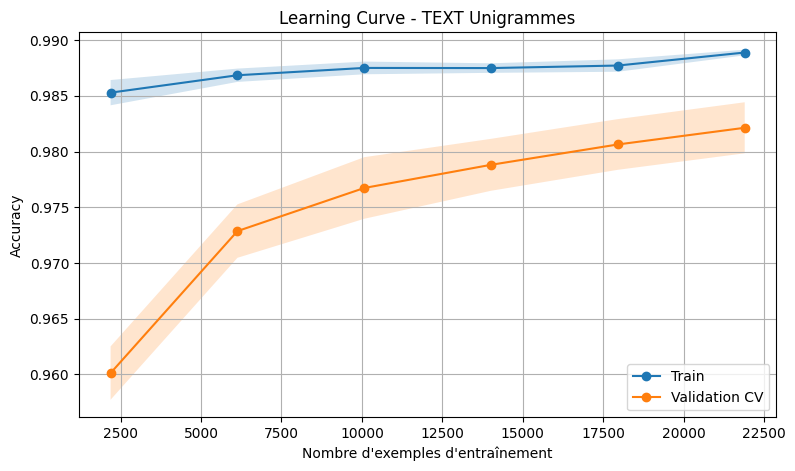

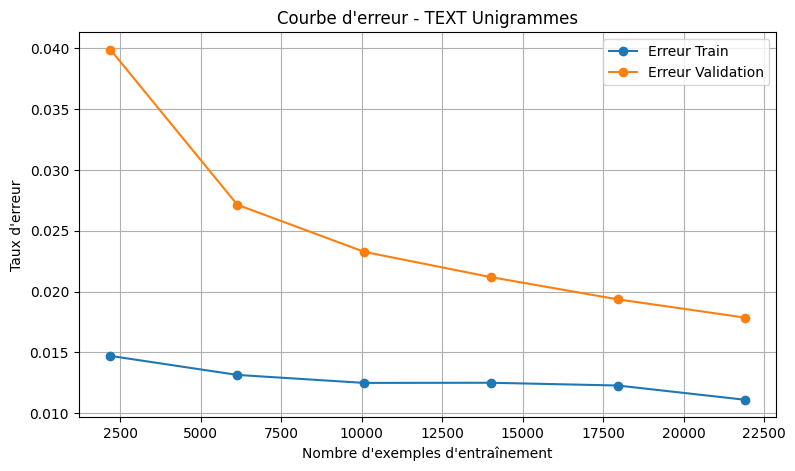

===== LEARNING CURVE =====
Accuracy Train CV finale      : 0.9889
Accuracy Validation CV finale : 0.9821
Gap Train - Validation        : 0.0068
Temps Learning Curve          : 125.90 secondes

===== NOUVELLE PRÉDICTION =====
Prédiction : Real
Probabilité Fake : 0.0205
Probabilité Real : 0.9795
Temps d'une prédiction : 1.9638 ms

===== LATENCE MOYENNE =====
Temps moyen  : 0.6497 ms
Temps médian : 0.6170 ms
Temps minimum : 0.5398 ms
Temps maximum : 1.1640 ms

===== RÉSUMÉ FINAL — TEXT UNIGRAMMES =====


,Metric,Value
0,TF-IDF Time (s),11.0208
1,Logistic Regression Training Time (s),1.0106
2,Total Training Time (s),12.0313
3,Single Prediction Time (ms),1.9638
4,Average Prediction Time (ms),0.6497
5,Test Accuracy,0.9857
6,Test Balanced Accuracy,0.9851
7,Test Precision Macro,0.9861
8,Test Recall Macro,0.9851
9,Test F1 Macro,0.9856


In [79]:
# ============================================================
# CELLULE 3
# LEARNING CURVE + OVERFITTING + TEMPS DE PRÉDICTION
# ============================================================


# ============================================================
# 1. PIPELINE POUR LEARNING CURVE
# ============================================================

pipeline_text_uni = Pipeline([

    (
        'tfidf',
        TfidfVectorizer(
            stop_words='english',
            ngram_range=(1, 1),
            min_df=2,
            max_features=20000
        )
    ),

    (
        'logistic',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )

])


# ============================================================
# 2. CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. CALCUL DE LA LEARNING CURVE
# ============================================================

start_lc = time.perf_counter()

train_sizes, train_scores, val_scores = learning_curve(

    pipeline_text_uni,

    # uniquement TRAIN
    X_train,
    y_train,

    train_sizes=np.linspace(
        0.1,
        1.0,
        6
    ),

    cv=cv,

    scoring='accuracy',

    n_jobs=-1
)

end_lc = time.perf_counter()

learning_curve_time = (
    end_lc - start_lc
)


# ============================================================
# 4. MOYENNES ET ÉCARTS-TYPES
# ============================================================

train_mean = train_scores.mean(
    axis=1
)

train_std = train_scores.std(
    axis=1
)

val_mean = val_scores.mean(
    axis=1
)

val_std = val_scores.std(
    axis=1
)


# ============================================================
# 5. LEARNING CURVE — ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation CV'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Learning Curve - TEXT Unigrammes"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 6. LEARNING CURVE — ERREUR
# ============================================================

train_error_curve = (
    1 - train_mean
)

val_error_curve = (
    1 - val_mean
)


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes,
    train_error_curve,
    marker='o',
    label='Erreur Train'
)

plt.plot(
    train_sizes,
    val_error_curve,
    marker='o',
    label='Erreur Validation'
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Courbe d'erreur - TEXT Unigrammes"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 7. GAP FINAL
# ============================================================

train_final = (
    train_mean[-1]
)

val_final = (
    val_mean[-1]
)

gap_cv = (
    train_final -
    val_final
)


print(
    "===== LEARNING CURVE ====="
)

print(
    "Accuracy Train CV finale      :",
    round(train_final, 4)
)

print(
    "Accuracy Validation CV finale :",
    round(val_final, 4)
)

print(
    "Gap Train - Validation        :",
    round(gap_cv, 4)
)

print(
    f"Temps Learning Curve          : "
    f"{learning_curve_time:.2f} secondes"
)


# ============================================================
# 8. NOUVEL ARTICLE POUR TESTER LA LATENCE
# ============================================================

new_text = """
President Donald Trump said the government would announce
a new policy following discussions with officials in Washington.
"""


# ============================================================
# 9. UNE SEULE PRÉDICTION COMPLÈTE
# TF-IDF + Logistic Regression
# ============================================================

start_prediction = time.perf_counter()

new_text_tfidf = tfidf_text_uni.transform(
    [new_text]
)

new_prediction = model_text_uni.predict(
    new_text_tfidf
)[0]

new_probability = model_text_uni.predict_proba(
    new_text_tfidf
)[0]

end_prediction = time.perf_counter()

prediction_time = (
    end_prediction -
    start_prediction
)


print(
    "\n===== NOUVELLE PRÉDICTION ====="
)

print(
    "Prédiction :",
    "Real" if new_prediction == 1 else "Fake"
)

print(
    f"Probabilité Fake : "
    f"{new_probability[0]:.4f}"
)

print(
    f"Probabilité Real : "
    f"{new_probability[1]:.4f}"
)

print(
    f"Temps d'une prédiction : "
    f"{prediction_time * 1000:.4f} ms"
)


# ============================================================
# 10. TEMPS MOYEN SUR 1000 PRÉDICTIONS
# ============================================================

# Warm-up
_ = tfidf_text_uni.transform(
    [new_text]
)

n_runs = 1000

prediction_times = []

for _ in range(n_runs):

    start = time.perf_counter()

    x_new = tfidf_text_uni.transform(
        [new_text]
    )

    _ = model_text_uni.predict(
        x_new
    )

    end = time.perf_counter()

    prediction_times.append(
        end - start
    )


prediction_times = np.array(
    prediction_times
)


print(
    "\n===== LATENCE MOYENNE ====="
)

print(
    f"Temps moyen  : "
    f"{prediction_times.mean() * 1000:.4f} ms"
)

print(
    f"Temps médian : "
    f"{np.median(prediction_times) * 1000:.4f} ms"
)

print(
    f"Temps minimum : "
    f"{prediction_times.min() * 1000:.4f} ms"
)

print(
    f"Temps maximum : "
    f"{prediction_times.max() * 1000:.4f} ms"
)


# ============================================================
# 11. RÉSUMÉ FINAL
# ============================================================

summary_text_uni = pd.DataFrame({

    'Metric': [

        'TF-IDF Time (s)',
        'Logistic Regression Training Time (s)',
        'Total Training Time (s)',

        'Single Prediction Time (ms)',
        'Average Prediction Time (ms)',

        'Test Accuracy',
        'Test Balanced Accuracy',

        'Test Precision Macro',
        'Test Recall Macro',
        'Test F1 Macro',

        'Test Precision Weighted',
        'Test Recall Weighted',
        'Test F1 Weighted',

        'Test ROC-AUC',
        'Test Log Loss',
        'Test MCC',

        'Train-Validation CV Gap'
    ],

    'Value': [

        tfidf_time,
        training_time,
        total_training_time,

        prediction_time * 1000,
        prediction_times.mean() * 1000,

        results_text_uni.loc[
            'Test',
            'Accuracy'
        ],

        results_text_uni.loc[
            'Test',
            'Balanced Accuracy'
        ],

        results_text_uni.loc[
            'Test',
            'Precision Macro'
        ],

        results_text_uni.loc[
            'Test',
            'Recall Macro'
        ],

        results_text_uni.loc[
            'Test',
            'F1 Macro'
        ],

        results_text_uni.loc[
            'Test',
            'Precision Weighted'
        ],

        results_text_uni.loc[
            'Test',
            'Recall Weighted'
        ],

        results_text_uni.loc[
            'Test',
            'F1 Weighted'
        ],

        results_text_uni.loc[
            'Test',
            'ROC-AUC'
        ],

        results_text_uni.loc[
            'Test',
            'Log Loss'
        ],

        results_text_uni.loc[
            'Test',
            'MCC'
        ],

        gap_cv
    ]
})


print(
    "\n===== RÉSUMÉ FINAL — TEXT UNIGRAMMES ====="
)

display(
    summary_text_uni.round(4)
)

# content + Unigrammes + TF-IDF + entraînement

In [81]:
# ============================================================
# CELLULE 1
# TITLE + TEXT = CONTENT
# UNIGRAMMES + TF-IDF + LOGISTIC REGRESSION
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    StratifiedKFold
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CRÉER LA COLONNE CONTENT
# ============================================================

df['content'] = (
    df['title'].fillna('').str.strip()
    + ' '
    + df['text'].fillna('').str.strip()
)

print("Colonnes du dataset :")
print(df.columns)

print("\nExemple de content :")
print(df['content'].iloc[0][:500])


# ============================================================
# 2. X ET y
# ============================================================

X = df['content']
y = df['label']

print("\nNombre total d'articles :", len(X))


# ============================================================
# 3. TRAIN / VALIDATION / TEST
# 70% / 15% / 15%
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("\n===== TAILLE DES DATASETS =====")

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))


print("\n===== DISTRIBUTION TRAIN =====")
print(y_train.value_counts(normalize=True))

print("\n===== DISTRIBUTION VALIDATION =====")
print(y_val.value_counts(normalize=True))

print("\n===== DISTRIBUTION TEST =====")
print(y_test.value_counts(normalize=True))


# ============================================================
# 4. TF-IDF — UNIGRAMMES
# ============================================================

tfidf_content_uni = TfidfVectorizer(
    stop_words='english',

    # mots isolés uniquement
    ngram_range=(1, 1),

    min_df=2,
    max_features=20000
)


# ============================================================
# 5. TEMPS TF-IDF
# ============================================================

start_tfidf = time.perf_counter()

# Apprentissage uniquement sur Train
X_train_tfidf = tfidf_content_uni.fit_transform(
    X_train
)

# Validation et Test utilisent le vocabulaire du Train
X_val_tfidf = tfidf_content_uni.transform(
    X_val
)

X_test_tfidf = tfidf_content_uni.transform(
    X_test
)

end_tfidf = time.perf_counter()

tfidf_time = (
    end_tfidf - start_tfidf
)


print("\n===== SHAPES TF-IDF =====")

print("Train      :", X_train_tfidf.shape)
print("Validation :", X_val_tfidf.shape)
print("Test       :", X_test_tfidf.shape)


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

model_content_uni = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ============================================================
# 7. TEMPS D'ENTRAÎNEMENT
# ============================================================

start_training = time.perf_counter()

model_content_uni.fit(
    X_train_tfidf,
    y_train
)

end_training = time.perf_counter()

training_time = (
    end_training - start_training
)

total_training_time = (
    tfidf_time +
    training_time
)


print("\n===== TEMPS =====")

print(
    f"Temps TF-IDF              : "
    f"{tfidf_time:.4f} secondes"
)

print(
    f"Temps Logistic Regression : "
    f"{training_time:.4f} secondes"
)

print(
    f"Temps total entraînement  : "
    f"{total_training_time:.4f} secondes"
)


# ============================================================
# 8. PRÉDICTIONS
# ============================================================

pred_train = model_content_uni.predict(
    X_train_tfidf
)

pred_val = model_content_uni.predict(
    X_val_tfidf
)

pred_test = model_content_uni.predict(
    X_test_tfidf
)


# Probabilités de la classe Real = 1

prob_train = model_content_uni.predict_proba(
    X_train_tfidf
)[:, 1]

prob_val = model_content_uni.predict_proba(
    X_val_tfidf
)[:, 1]

prob_test = model_content_uni.predict_proba(
    X_test_tfidf
)[:, 1]


print(
    "\nEntraînement et prédictions terminés."
)

Colonnes du dataset :
Index(['title', 'text', 'subject', 'date', 'label', 'title_words',
       'text_words', 'date_clean', 'exclamation_count', 'question_count',
       'uppercase_words', 'content'],
      dtype='object')

Exemple de content :
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto

Nombre total d'articles : 39105

===== TAILLE DES DATASETS =====
Train      : 27373
Validation : 5866
Test       : 5866

===== DISTRIBUTION TRAIN =====
label
1    0.542067
0    0.457933
Name: proportion, dtype: float64

===== DISTRIBUTION VALIDATION ===

===== TOUTES LES MÉTRIQUES =====


,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC,Log Loss,MCC
Train,0.9904,0.9899,0.9907,0.9899,0.9903,0.9904,0.9904,0.9904,0.9993,0.0804,0.9806
Validation,0.9838,0.9833,0.9841,0.9833,0.9837,0.9838,0.9838,0.9838,0.9978,0.0930,0.9674
Test,0.9872,0.9866,0.9877,0.9866,0.9871,0.9873,0.9872,0.9872,0.9984,0.0883,0.9743



===== CLASSIFICATION REPORT — TEST =====

              precision    recall  f1-score   support

        Fake     0.9925    0.9795    0.9860      2687
        Real     0.9829    0.9937    0.9883      3179

    accuracy                         0.9872      5866
   macro avg     0.9877    0.9866    0.9871      5866
weighted avg     0.9873    0.9872    0.9872      5866


===== CONFUSION MATRIX =====
[[2632   55]
 [  20 3159]]


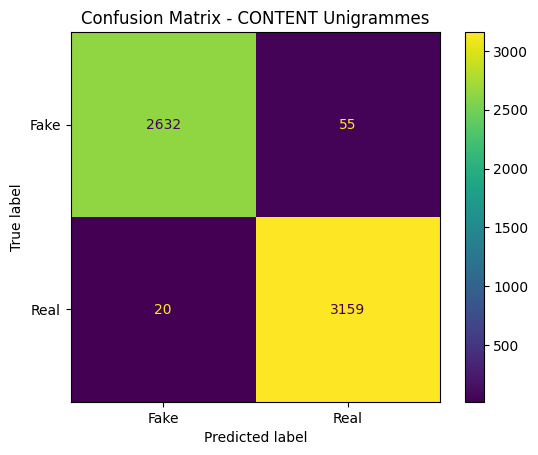


===== TAUX D'ERREUR =====
Erreur Train      : 0.0096
Erreur Validation : 0.0162
Erreur Test       : 0.0128


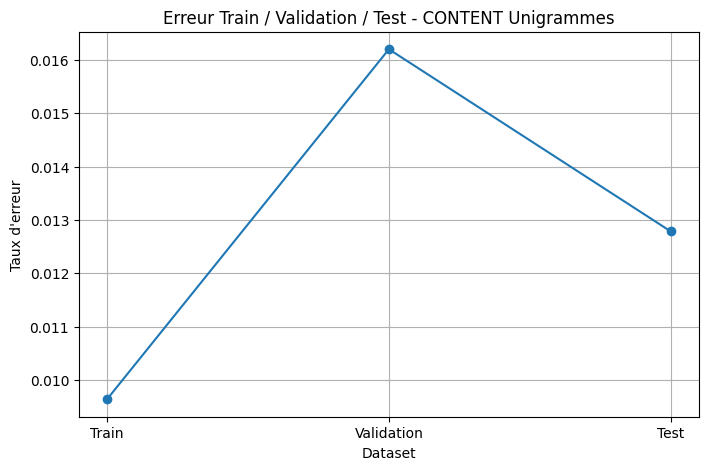


===== GAP TRAIN / VALIDATION =====
Accuracy Train      : 0.9904
Accuracy Validation : 0.9838
Gap                 : 0.0066


In [82]:
# ============================================================
# CELLULE 2
# MÉTRIQUES + CONFUSION MATRIX + ERREURS
# CONTENT UNIGRAMMES
# ============================================================


# ============================================================
# 1. FONCTION DES MÉTRIQUES
# ============================================================

def get_metrics(y_true, y_pred, y_prob):

    return {

        'Accuracy':
            accuracy_score(
                y_true,
                y_pred
            ),

        'Balanced Accuracy':
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        'Precision Macro':
            precision_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Recall Macro':
            recall_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'F1 Macro':
            f1_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Precision Weighted':
            precision_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'Recall Weighted':
            recall_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'F1 Weighted':
            f1_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'ROC-AUC':
            roc_auc_score(
                y_true,
                y_prob
            ),

        'Log Loss':
            log_loss(
                y_true,
                y_prob
            ),

        'MCC':
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }


# ============================================================
# 2. TRAIN / VALIDATION / TEST
# ============================================================

results_content_uni = pd.DataFrame({

    'Train': get_metrics(
        y_train,
        pred_train,
        prob_train
    ),

    'Validation': get_metrics(
        y_val,
        pred_val,
        prob_val
    ),

    'Test': get_metrics(
        y_test,
        pred_test,
        prob_test
    )

}).T


print(
    "===== TOUTES LES MÉTRIQUES ====="
)

display(
    results_content_uni.round(4)
)


# ============================================================
# 3. CLASSIFICATION REPORT — TEST
# ============================================================

print(
    "\n===== CLASSIFICATION REPORT — TEST =====\n"
)

print(
    classification_report(
        y_test,
        pred_test,

        target_names=[
            'Fake',
            'Real'
        ],

        digits=4
    )
)


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    pred_test
)

print(
    "\n===== CONFUSION MATRIX ====="
)

print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,

    display_labels=[
        'Fake',
        'Real'
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - CONTENT Unigrammes"
)

plt.show()


# ============================================================
# 5. TAUX D'ERREUR
# ============================================================

train_error = (
    1 -
    accuracy_score(
        y_train,
        pred_train
    )
)

val_error = (
    1 -
    accuracy_score(
        y_val,
        pred_val
    )
)

test_error = (
    1 -
    accuracy_score(
        y_test,
        pred_test
    )
)


print(
    "\n===== TAUX D'ERREUR ====="
)

print(
    "Erreur Train      :",
    round(train_error, 4)
)

print(
    "Erreur Validation :",
    round(val_error, 4)
)

print(
    "Erreur Test       :",
    round(test_error, 4)
)


# ============================================================
# 6. GRAPHE DES ERREURS
# ============================================================

datasets = [
    'Train',
    'Validation',
    'Test'
]

errors = [
    train_error,
    val_error,
    test_error
]


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    datasets,
    errors,
    marker='o'
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Erreur Train / Validation / Test - CONTENT Unigrammes"
)

plt.grid()

plt.show()


# ============================================================
# 7. GAP TRAIN / VALIDATION
# ============================================================

accuracy_train = accuracy_score(
    y_train,
    pred_train
)

accuracy_val = accuracy_score(
    y_val,
    pred_val
)

gap_direct = (
    accuracy_train -
    accuracy_val
)


print(
    "\n===== GAP TRAIN / VALIDATION ====="
)

print(
    "Accuracy Train      :",
    round(accuracy_train, 4)
)

print(
    "Accuracy Validation :",
    round(accuracy_val, 4)
)

print(
    "Gap                 :",
    round(gap_direct, 4)
)

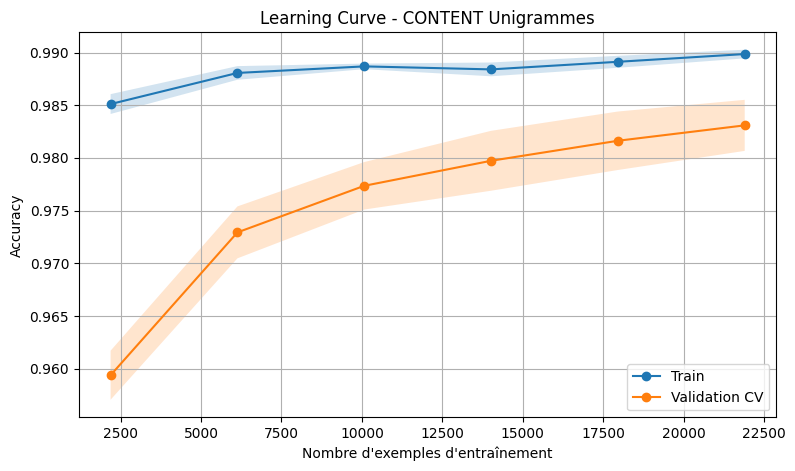

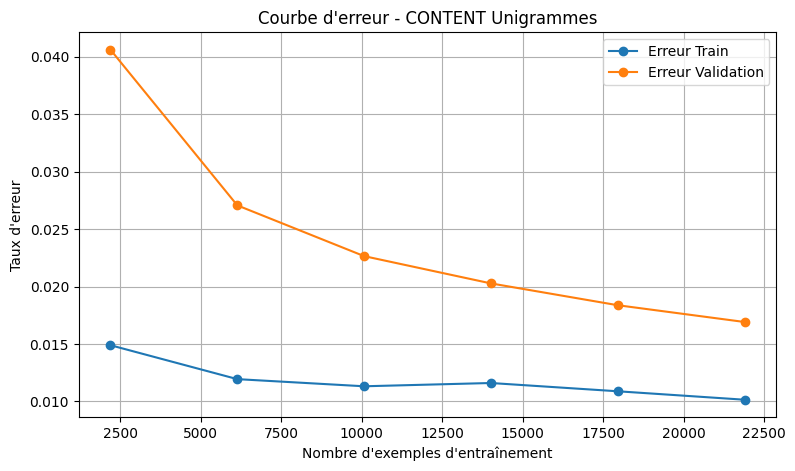

===== LEARNING CURVE =====
Accuracy Train CV finale      : 0.9899
Accuracy Validation CV finale : 0.9831
Gap Train - Validation        : 0.0068
Temps Learning Curve          : 132.55 secondes

===== NOUVELLE PRÉDICTION =====
Prédiction : Real
Probabilité Fake : 0.0944
Probabilité Real : 0.9056
Temps d'une prédiction : 1.7342 ms

===== LATENCE MOYENNE =====
Temps moyen   : 0.6316 ms
Temps médian  : 0.6103 ms
Temps minimum : 0.5619 ms
Temps maximum : 1.3508 ms

===== RÉSUMÉ FINAL — CONTENT UNIGRAMMES =====


,Metric,Value
0,TF-IDF Time (s),11.7956
1,Logistic Regression Training Time (s),0.5967
2,Total Training Time (s),12.3923
3,Single Prediction Time (ms),1.7342
4,Average Prediction Time (ms),0.6316
5,Test Accuracy,0.9872
6,Test Balanced Accuracy,0.9866
7,Test Precision Macro,0.9877
8,Test Recall Macro,0.9866
9,Test F1 Macro,0.9871


In [83]:
# ============================================================
# CELLULE 3
# LEARNING CURVE + OVERFITTING
# + TEMPS DE PRÉDICTION
# CONTENT UNIGRAMMES
# ============================================================


# ============================================================
# 1. PIPELINE
# ============================================================

pipeline_content_uni = Pipeline([

    (
        'tfidf',
        TfidfVectorizer(
            stop_words='english',
            ngram_range=(1, 1),
            min_df=2,
            max_features=20000
        )
    ),

    (
        'logistic',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )

])


# ============================================================
# 2. CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. LEARNING CURVE
# ============================================================

start_lc = time.perf_counter()

train_sizes, train_scores, val_scores = learning_curve(

    pipeline_content_uni,

    # uniquement les données Train
    X_train,
    y_train,

    train_sizes=np.linspace(
        0.1,
        1.0,
        6
    ),

    cv=cv,

    scoring='accuracy',

    n_jobs=-1
)

end_lc = time.perf_counter()

learning_curve_time = (
    end_lc - start_lc
)


# ============================================================
# 4. MOYENNES
# ============================================================

train_mean = train_scores.mean(
    axis=1
)

train_std = train_scores.std(
    axis=1
)

val_mean = val_scores.mean(
    axis=1
)

val_std = val_scores.std(
    axis=1
)


# ============================================================
# 5. LEARNING CURVE — ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation CV'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Learning Curve - CONTENT Unigrammes"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 6. LEARNING CURVE — ERREUR
# ============================================================

train_error_curve = (
    1 - train_mean
)

val_error_curve = (
    1 - val_mean
)


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes,
    train_error_curve,
    marker='o',
    label='Erreur Train'
)

plt.plot(
    train_sizes,
    val_error_curve,
    marker='o',
    label='Erreur Validation'
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Courbe d'erreur - CONTENT Unigrammes"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 7. GAP FINAL
# ============================================================

train_final = train_mean[-1]

val_final = val_mean[-1]

gap_cv = (
    train_final -
    val_final
)


print(
    "===== LEARNING CURVE ====="
)

print(
    "Accuracy Train CV finale      :",
    round(train_final, 4)
)

print(
    "Accuracy Validation CV finale :",
    round(val_final, 4)
)

print(
    "Gap Train - Validation        :",
    round(gap_cv, 4)
)

print(
    f"Temps Learning Curve          : "
    f"{learning_curve_time:.2f} secondes"
)


# ============================================================
# 8. NOUVEL ARTICLE
# ============================================================

new_title = """
Government announces new policy after meeting
"""

new_text = """
The government announced a new policy following discussions
with officials in Washington. The president said more details
would be released during a press conference.
"""


# ============================================================
# 9. CONSTRUIRE CONTENT COMME PENDANT L'ENTRAÎNEMENT
# ============================================================

new_content = (
    new_title.strip()
    + ' '
    + new_text.strip()
)


# ============================================================
# 10. UNE SEULE PRÉDICTION
# TF-IDF + LOGISTIC REGRESSION
# ============================================================

start_prediction = time.perf_counter()

new_vector = tfidf_content_uni.transform(
    [new_content]
)

new_prediction = model_content_uni.predict(
    new_vector
)[0]

new_probability = model_content_uni.predict_proba(
    new_vector
)[0]

end_prediction = time.perf_counter()

prediction_time = (
    end_prediction -
    start_prediction
)


print(
    "\n===== NOUVELLE PRÉDICTION ====="
)

print(
    "Prédiction :",
    "Real" if new_prediction == 1 else "Fake"
)

print(
    f"Probabilité Fake : "
    f"{new_probability[0]:.4f}"
)

print(
    f"Probabilité Real : "
    f"{new_probability[1]:.4f}"
)

print(
    f"Temps d'une prédiction : "
    f"{prediction_time * 1000:.4f} ms"
)


# ============================================================
# 11. LATENCE MOYENNE SUR 1000 PRÉDICTIONS
# ============================================================

# Warm-up
_ = tfidf_content_uni.transform(
    [new_content]
)

n_runs = 1000

prediction_times = []


for _ in range(n_runs):

    start = time.perf_counter()

    x_new = tfidf_content_uni.transform(
        [new_content]
    )

    _ = model_content_uni.predict(
        x_new
    )

    end = time.perf_counter()

    prediction_times.append(
        end - start
    )


prediction_times = np.array(
    prediction_times
)


print(
    "\n===== LATENCE MOYENNE ====="
)

print(
    f"Temps moyen   : "
    f"{prediction_times.mean() * 1000:.4f} ms"
)

print(
    f"Temps médian  : "
    f"{np.median(prediction_times) * 1000:.4f} ms"
)

print(
    f"Temps minimum : "
    f"{prediction_times.min() * 1000:.4f} ms"
)

print(
    f"Temps maximum : "
    f"{prediction_times.max() * 1000:.4f} ms"
)


# ============================================================
# 12. RÉSUMÉ FINAL
# ============================================================

summary_content_uni = pd.DataFrame({

    'Metric': [

        'TF-IDF Time (s)',

        'Logistic Regression Training Time (s)',

        'Total Training Time (s)',

        'Single Prediction Time (ms)',

        'Average Prediction Time (ms)',

        'Test Accuracy',

        'Test Balanced Accuracy',

        'Test Precision Macro',

        'Test Recall Macro',

        'Test F1 Macro',

        'Test Precision Weighted',

        'Test Recall Weighted',

        'Test F1 Weighted',

        'Test ROC-AUC',

        'Test Log Loss',

        'Test MCC',

        'Train-Validation CV Gap'
    ],

    'Value': [

        tfidf_time,

        training_time,

        total_training_time,

        prediction_time * 1000,

        prediction_times.mean() * 1000,

        results_content_uni.loc[
            'Test',
            'Accuracy'
        ],

        results_content_uni.loc[
            'Test',
            'Balanced Accuracy'
        ],

        results_content_uni.loc[
            'Test',
            'Precision Macro'
        ],

        results_content_uni.loc[
            'Test',
            'Recall Macro'
        ],

        results_content_uni.loc[
            'Test',
            'F1 Macro'
        ],

        results_content_uni.loc[
            'Test',
            'Precision Weighted'
        ],

        results_content_uni.loc[
            'Test',
            'Recall Weighted'
        ],

        results_content_uni.loc[
            'Test',
            'F1 Weighted'
        ],

        results_content_uni.loc[
            'Test',
            'ROC-AUC'
        ],

        results_content_uni.loc[
            'Test',
            'Log Loss'
        ],

        results_content_uni.loc[
            'Test',
            'MCC'
        ],

        gap_cv
    ]
})


print(
    "\n===== RÉSUMÉ FINAL — CONTENT UNIGRAMMES ====="
)

display(
    summary_content_uni.round(4)
)

# content + Bigrammes + TF-IDF + entraînement + temps

In [84]:
# ============================================================
# CELLULE 1
# TITLE + TEXT = CONTENT
# BIGRAMMES + TF-IDF + LOGISTIC REGRESSION
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    StratifiedKFold
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CRÉER CONTENT = TITLE + TEXT
# ============================================================

df['content'] = (
    df['title'].fillna('').str.strip()
    + ' '
    + df['text'].fillna('').str.strip()
)

print("Exemple de content :")
print(df['content'].iloc[0][:500])


# ============================================================
# 2. X ET y
# ============================================================

X = df['content']
y = df['label']

print("\nNombre total d'articles :", len(X))


# ============================================================
# 3. TRAIN / VALIDATION / TEST
# 70% / 15% / 15%
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("\n===== TAILLE DES DATASETS =====")

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))


print("\n===== DISTRIBUTION TRAIN =====")
print(y_train.value_counts(normalize=True))

print("\n===== DISTRIBUTION VALIDATION =====")
print(y_val.value_counts(normalize=True))

print("\n===== DISTRIBUTION TEST =====")
print(y_test.value_counts(normalize=True))


# ============================================================
# 4. TF-IDF — BIGRAMMES
# ============================================================

tfidf_content_bi = TfidfVectorizer(
    stop_words='english',

    # uniquement bigrammes
    ngram_range=(2, 2),

    min_df=2,
    max_features=20000
)


# ============================================================
# 5. TEMPS TF-IDF
# ============================================================

start_tfidf_bi = time.perf_counter()

# Apprentissage TF-IDF uniquement sur Train
X_train_bi = tfidf_content_bi.fit_transform(
    X_train
)

# Validation et Test : transform uniquement
X_val_bi = tfidf_content_bi.transform(
    X_val
)

X_test_bi = tfidf_content_bi.transform(
    X_test
)

end_tfidf_bi = time.perf_counter()

tfidf_time_bi = (
    end_tfidf_bi - start_tfidf_bi
)


print("\n===== SHAPES TF-IDF =====")

print(
    "Train      :",
    X_train_bi.shape
)

print(
    "Validation :",
    X_val_bi.shape
)

print(
    "Test       :",
    X_test_bi.shape
)


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

model_content_bi = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ============================================================
# 7. TEMPS D'ENTRAÎNEMENT
# ============================================================

start_training_bi = time.perf_counter()

model_content_bi.fit(
    X_train_bi,
    y_train
)

end_training_bi = time.perf_counter()

training_time_bi = (
    end_training_bi - start_training_bi
)

total_training_time_bi = (
    tfidf_time_bi +
    training_time_bi
)


print("\n===== TEMPS =====")

print(
    f"Temps TF-IDF              : "
    f"{tfidf_time_bi:.4f} secondes"
)

print(
    f"Temps Logistic Regression : "
    f"{training_time_bi:.4f} secondes"
)

print(
    f"Temps total entraînement  : "
    f"{total_training_time_bi:.4f} secondes"
)


# ============================================================
# 8. PRÉDICTIONS
# ============================================================

pred_train_bi = model_content_bi.predict(
    X_train_bi
)

pred_val_bi = model_content_bi.predict(
    X_val_bi
)

pred_test_bi = model_content_bi.predict(
    X_test_bi
)


# Probabilités de Real = 1

prob_train_bi = model_content_bi.predict_proba(
    X_train_bi
)[:, 1]

prob_val_bi = model_content_bi.predict_proba(
    X_val_bi
)[:, 1]

prob_test_bi = model_content_bi.predict_proba(
    X_test_bi
)[:, 1]


print(
    "\nEntraînement et prédictions terminés."
)

Exemple de content :
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto

Nombre total d'articles : 39105

===== TAILLE DES DATASETS =====
Train      : 27373
Validation : 5866
Test       : 5866

===== DISTRIBUTION TRAIN =====
label
1    0.542067
0    0.457933
Name: proportion, dtype: float64

===== DISTRIBUTION VALIDATION =====
label
1    0.542107
0    0.457893
Name: proportion, dtype: float64

===== DISTRIBUTION TEST =====
label
1    0.541937
0    0.458063
Name: proportion, dtype: float64

===== SHAPES TF-IDF =====
Train      : (27373, 20000)
V

===== TOUTES LES MÉTRIQUES =====


,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC,Log Loss,MCC
Train,0.9913,0.9910,0.9916,0.9910,0.9913,0.9914,0.9913,0.9913,0.9994,0.1092,0.9826
Validation,0.9826,0.9820,0.9830,0.9820,0.9825,0.9827,0.9826,0.9826,0.9975,0.1249,0.9650
Test,0.9826,0.9819,0.9831,0.9819,0.9825,0.9827,0.9826,0.9826,0.9977,0.1243,0.9650



===== CLASSIFICATION REPORT — TEST =====

              precision    recall  f1-score   support

        Fake     0.9879    0.9739    0.9809      2687
        Real     0.9782    0.9899    0.9841      3179

    accuracy                         0.9826      5866
   macro avg     0.9831    0.9819    0.9825      5866
weighted avg     0.9827    0.9826    0.9826      5866


===== CONFUSION MATRIX =====
[[2617   70]
 [  32 3147]]


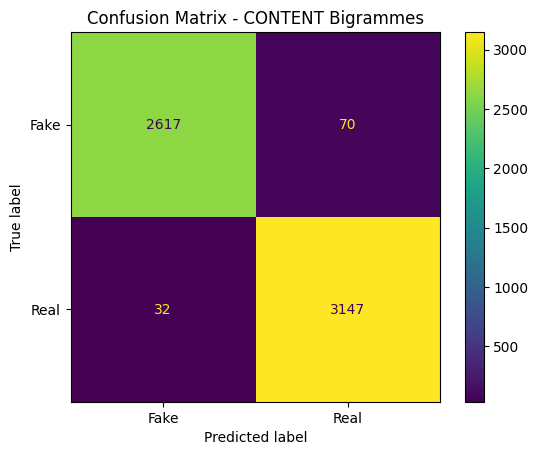


===== TAUX D'ERREUR =====
Erreur Train      : 0.0087
Erreur Validation : 0.0174
Erreur Test       : 0.0174


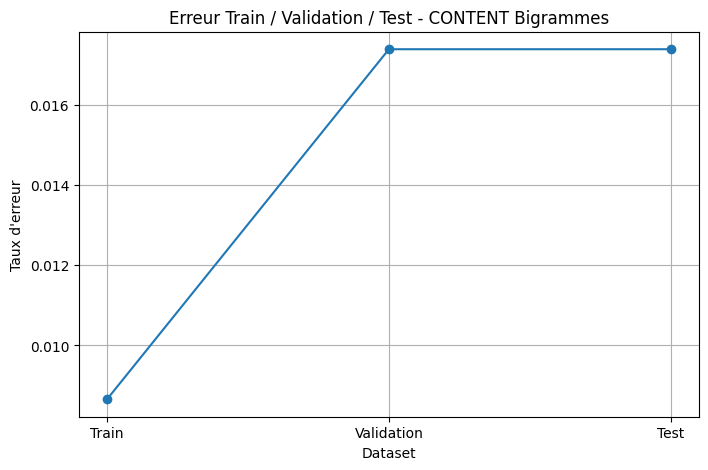


===== GAP TRAIN / VALIDATION =====
Accuracy Train      : 0.9913
Accuracy Validation : 0.9826
Gap                 : 0.0087


In [85]:
# ============================================================
# CELLULE 2
# MÉTRIQUES + CONFUSION MATRIX + ERREURS
# CONTENT BIGRAMMES
# ============================================================


# ============================================================
# 1. FONCTION DES MÉTRIQUES
# ============================================================

def get_metrics(y_true, y_pred, y_prob):

    return {

        'Accuracy':
            accuracy_score(
                y_true,
                y_pred
            ),

        'Balanced Accuracy':
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        'Precision Macro':
            precision_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Recall Macro':
            recall_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'F1 Macro':
            f1_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Precision Weighted':
            precision_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'Recall Weighted':
            recall_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'F1 Weighted':
            f1_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'ROC-AUC':
            roc_auc_score(
                y_true,
                y_prob
            ),

        'Log Loss':
            log_loss(
                y_true,
                y_prob
            ),

        'MCC':
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }


# ============================================================
# 2. MÉTRIQUES TRAIN / VALIDATION / TEST
# ============================================================

results_content_bi = pd.DataFrame({

    'Train': get_metrics(
        y_train,
        pred_train_bi,
        prob_train_bi
    ),

    'Validation': get_metrics(
        y_val,
        pred_val_bi,
        prob_val_bi
    ),

    'Test': get_metrics(
        y_test,
        pred_test_bi,
        prob_test_bi
    )

}).T


print(
    "===== TOUTES LES MÉTRIQUES ====="
)

display(
    results_content_bi.round(4)
)


# ============================================================
# 3. CLASSIFICATION REPORT — TEST
# ============================================================

print(
    "\n===== CLASSIFICATION REPORT — TEST =====\n"
)

print(
    classification_report(
        y_test,
        pred_test_bi,

        target_names=[
            'Fake',
            'Real'
        ],

        digits=4
    )
)


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

cm_bi = confusion_matrix(
    y_test,
    pred_test_bi
)

print(
    "\n===== CONFUSION MATRIX ====="
)

print(cm_bi)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bi,

    display_labels=[
        'Fake',
        'Real'
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - CONTENT Bigrammes"
)

plt.show()


# ============================================================
# 5. TAUX D'ERREUR
# ============================================================

train_error_bi = (
    1 -
    accuracy_score(
        y_train,
        pred_train_bi
    )
)

val_error_bi = (
    1 -
    accuracy_score(
        y_val,
        pred_val_bi
    )
)

test_error_bi = (
    1 -
    accuracy_score(
        y_test,
        pred_test_bi
    )
)


print(
    "\n===== TAUX D'ERREUR ====="
)

print(
    "Erreur Train      :",
    round(train_error_bi, 4)
)

print(
    "Erreur Validation :",
    round(val_error_bi, 4)
)

print(
    "Erreur Test       :",
    round(test_error_bi, 4)
)


# ============================================================
# 6. GRAPHE DES ERREURS
# ============================================================

datasets = [
    'Train',
    'Validation',
    'Test'
]

errors_bi = [
    train_error_bi,
    val_error_bi,
    test_error_bi
]


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    datasets,
    errors_bi,
    marker='o'
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Erreur Train / Validation / Test - CONTENT Bigrammes"
)

plt.grid()

plt.show()


# ============================================================
# 7. GAP TRAIN / VALIDATION
# ============================================================

accuracy_train_bi = accuracy_score(
    y_train,
    pred_train_bi
)

accuracy_val_bi = accuracy_score(
    y_val,
    pred_val_bi
)

gap_direct_bi = (
    accuracy_train_bi -
    accuracy_val_bi
)


print(
    "\n===== GAP TRAIN / VALIDATION ====="
)

print(
    "Accuracy Train      :",
    round(accuracy_train_bi, 4)
)

print(
    "Accuracy Validation :",
    round(accuracy_val_bi, 4)
)

print(
    "Gap                 :",
    round(gap_direct_bi, 4)
)

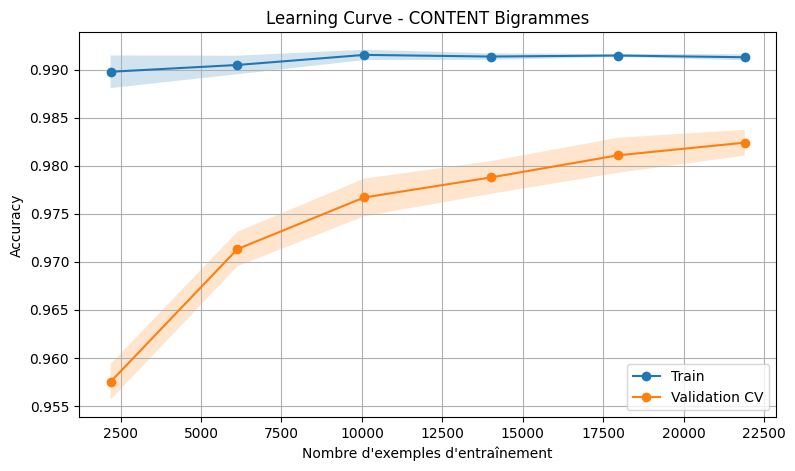

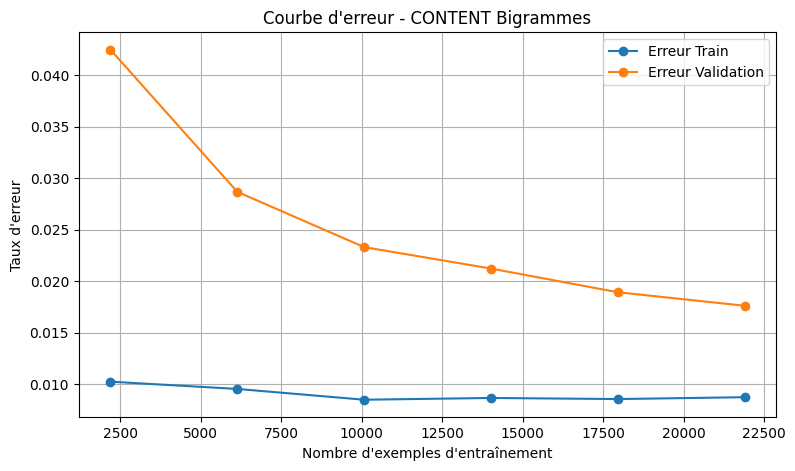

===== LEARNING CURVE =====
Accuracy Train CV finale      : 0.9913
Accuracy Validation CV finale : 0.9824
Gap Train - Validation        : 0.0089
Temps Learning Curve          : 229.28 secondes

===== NOUVELLE PRÉDICTION =====
Prédiction : Fake
Probabilité Fake : 0.6822
Probabilité Real : 0.3178
Temps d'une prédiction : 1.8275 ms

===== LATENCE MOYENNE =====
Temps moyen   : 0.7281 ms
Temps médian  : 0.7303 ms
Temps minimum : 0.5662 ms
Temps maximum : 1.4593 ms

===== RÉSUMÉ FINAL — CONTENT BIGRAMMES =====


,Metric,Value
0,TF-IDF Time (s),31.8461
1,Logistic Regression Training Time (s),0.5156
2,Total Training Time (s),32.3617
3,Single Prediction Time (ms),1.8275
4,Average Prediction Time (ms),0.7281
5,Test Accuracy,0.9826
6,Test Balanced Accuracy,0.9819
7,Test Precision Macro,0.9831
8,Test Recall Macro,0.9819
9,Test F1 Macro,0.9825


In [86]:
# ============================================================
# CELLULE 3
# LEARNING CURVE + OVERFITTING
# + TEMPS D'UNE NOUVELLE PRÉDICTION
# CONTENT BIGRAMMES
# ============================================================


# ============================================================
# 1. PIPELINE
# ============================================================

pipeline_content_bi = Pipeline([

    (
        'tfidf',
        TfidfVectorizer(
            stop_words='english',

            # bigrammes uniquement
            ngram_range=(2, 2),

            min_df=2,
            max_features=20000
        )
    ),

    (
        'logistic',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )

])


# ============================================================
# 2. CROSS-VALIDATION
# ============================================================

cv_bi = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. LEARNING CURVE
# ============================================================

start_lc_bi = time.perf_counter()

train_sizes_bi, train_scores_bi, val_scores_bi = learning_curve(

    pipeline_content_bi,

    # uniquement Train
    X_train,
    y_train,

    train_sizes=np.linspace(
        0.1,
        1.0,
        6
    ),

    cv=cv_bi,

    scoring='accuracy',

    n_jobs=-1
)

end_lc_bi = time.perf_counter()

learning_curve_time_bi = (
    end_lc_bi -
    start_lc_bi
)


# ============================================================
# 4. MOYENNES
# ============================================================

train_mean_bi = train_scores_bi.mean(
    axis=1
)

train_std_bi = train_scores_bi.std(
    axis=1
)

val_mean_bi = val_scores_bi.mean(
    axis=1
)

val_std_bi = val_scores_bi.std(
    axis=1
)


# ============================================================
# 5. LEARNING CURVE — ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes_bi,
    train_mean_bi,
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes_bi,
    val_mean_bi,
    marker='o',
    label='Validation CV'
)

plt.fill_between(
    train_sizes_bi,
    train_mean_bi - train_std_bi,
    train_mean_bi + train_std_bi,
    alpha=0.2
)

plt.fill_between(
    train_sizes_bi,
    val_mean_bi - val_std_bi,
    val_mean_bi + val_std_bi,
    alpha=0.2
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Learning Curve - CONTENT Bigrammes"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 6. LEARNING CURVE — ERREUR
# ============================================================

train_error_curve_bi = (
    1 - train_mean_bi
)

val_error_curve_bi = (
    1 - val_mean_bi
)


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    train_sizes_bi,
    train_error_curve_bi,
    marker='o',
    label='Erreur Train'
)

plt.plot(
    train_sizes_bi,
    val_error_curve_bi,
    marker='o',
    label='Erreur Validation'
)

plt.xlabel(
    "Nombre d'exemples d'entraînement"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Courbe d'erreur - CONTENT Bigrammes"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 7. GAP FINAL
# ============================================================

train_final_bi = train_mean_bi[-1]

val_final_bi = val_mean_bi[-1]

gap_cv_bi = (
    train_final_bi -
    val_final_bi
)


print(
    "===== LEARNING CURVE ====="
)

print(
    "Accuracy Train CV finale      :",
    round(train_final_bi, 4)
)

print(
    "Accuracy Validation CV finale :",
    round(val_final_bi, 4)
)

print(
    "Gap Train - Validation        :",
    round(gap_cv_bi, 4)
)

print(
    f"Temps Learning Curve          : "
    f"{learning_curve_time_bi:.2f} secondes"
)


# ============================================================
# 8. NOUVEL ARTICLE
# ============================================================

new_title = """
Government announces new policy after meeting
"""

new_text = """
The government announced a new policy following discussions
with officials in Washington. The president said more details
would be released during a press conference.
"""


# ============================================================
# 9. CONSTRUIRE CONTENT
# ============================================================

new_content = (
    new_title.strip()
    + ' '
    + new_text.strip()
)


# ============================================================
# 10. UNE SEULE PRÉDICTION
# ============================================================

start_prediction_bi = time.perf_counter()

new_vector_bi = tfidf_content_bi.transform(
    [new_content]
)

new_prediction_bi = model_content_bi.predict(
    new_vector_bi
)[0]

new_probability_bi = model_content_bi.predict_proba(
    new_vector_bi
)[0]

end_prediction_bi = time.perf_counter()

prediction_time_bi = (
    end_prediction_bi -
    start_prediction_bi
)


print(
    "\n===== NOUVELLE PRÉDICTION ====="
)

print(
    "Prédiction :",
    "Real" if new_prediction_bi == 1 else "Fake"
)

print(
    f"Probabilité Fake : "
    f"{new_probability_bi[0]:.4f}"
)

print(
    f"Probabilité Real : "
    f"{new_probability_bi[1]:.4f}"
)

print(
    f"Temps d'une prédiction : "
    f"{prediction_time_bi * 1000:.4f} ms"
)


# ============================================================
# 11. LATENCE MOYENNE SUR 1000 PRÉDICTIONS
# ============================================================

# Warm-up
_ = tfidf_content_bi.transform(
    [new_content]
)

n_runs = 1000

prediction_times_bi = []


for _ in range(n_runs):

    start = time.perf_counter()

    x_new_bi = tfidf_content_bi.transform(
        [new_content]
    )

    _ = model_content_bi.predict(
        x_new_bi
    )

    end = time.perf_counter()

    prediction_times_bi.append(
        end - start
    )


prediction_times_bi = np.array(
    prediction_times_bi
)


print(
    "\n===== LATENCE MOYENNE ====="
)

print(
    f"Temps moyen   : "
    f"{prediction_times_bi.mean() * 1000:.4f} ms"
)

print(
    f"Temps médian  : "
    f"{np.median(prediction_times_bi) * 1000:.4f} ms"
)

print(
    f"Temps minimum : "
    f"{prediction_times_bi.min() * 1000:.4f} ms"
)

print(
    f"Temps maximum : "
    f"{prediction_times_bi.max() * 1000:.4f} ms"
)


# ============================================================
# 12. RÉSUMÉ FINAL
# ============================================================

summary_content_bi = pd.DataFrame({

    'Metric': [

        'TF-IDF Time (s)',

        'Logistic Regression Training Time (s)',

        'Total Training Time (s)',

        'Single Prediction Time (ms)',

        'Average Prediction Time (ms)',

        'Test Accuracy',

        'Test Balanced Accuracy',

        'Test Precision Macro',

        'Test Recall Macro',

        'Test F1 Macro',

        'Test Precision Weighted',

        'Test Recall Weighted',

        'Test F1 Weighted',

        'Test ROC-AUC',

        'Test Log Loss',

        'Test MCC',

        'Train-Validation CV Gap'
    ],

    'Value': [

        tfidf_time_bi,

        training_time_bi,

        total_training_time_bi,

        prediction_time_bi * 1000,

        prediction_times_bi.mean() * 1000,

        results_content_bi.loc[
            'Test',
            'Accuracy'
        ],

        results_content_bi.loc[
            'Test',
            'Balanced Accuracy'
        ],

        results_content_bi.loc[
            'Test',
            'Precision Macro'
        ],

        results_content_bi.loc[
            'Test',
            'Recall Macro'
        ],

        results_content_bi.loc[
            'Test',
            'F1 Macro'
        ],

        results_content_bi.loc[
            'Test',
            'Precision Weighted'
        ],

        results_content_bi.loc[
            'Test',
            'Recall Weighted'
        ],

        results_content_bi.loc[
            'Test',
            'F1 Weighted'
        ],

        results_content_bi.loc[
            'Test',
            'ROC-AUC'
        ],

        results_content_bi.loc[
            'Test',
            'Log Loss'
        ],

        results_content_bi.loc[
            'Test',
            'MCC'
        ],

        gap_cv_bi
    ]
})


print(
    "\n===== RÉSUMÉ FINAL — CONTENT BIGRAMMES ====="
)

display(
    summary_content_bi.round(4)
)

Nombre de features : 20000
Classes du modèle : [0 1]
Intercept : -0.5910896984790415

TOP 20 BIGRAMMES → REAL


,feature,coefficient
0,washington reuters,15.567921
1,president donald,9.103263
2,told reuters,8.211550
3,said statement,7.001179
4,reuters president,6.406538
5,told reporters,5.312380
6,prime minister,5.069078
7,said wednesday,4.958058
8,london reuters,4.878623
9,york reuters,4.828320



TOP 20 BIGRAMMES → FAKE


,feature,coefficient
19999,featured image,-14.313881
19998,getty images,-9.025355
19997,president trump,-6.417057
19996,twitter com,-6.264164
19995,president obama,-5.933330
19994,pic twitter,-5.822091
19993,hillary clinton,-4.141355
19992,daily mail,-3.946541
19991,century wire,-3.666025
19990,screen capture,-3.527673


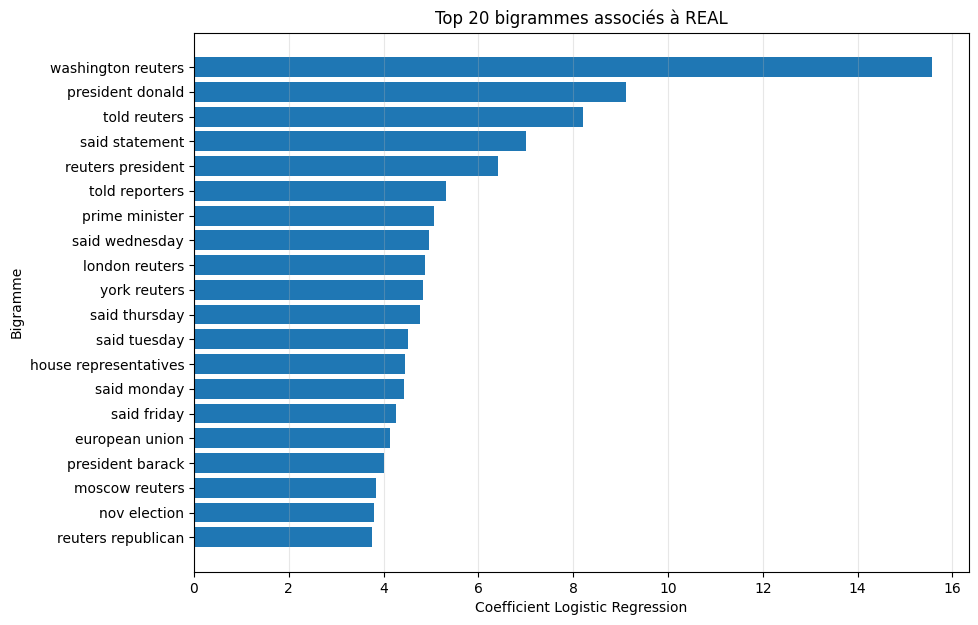

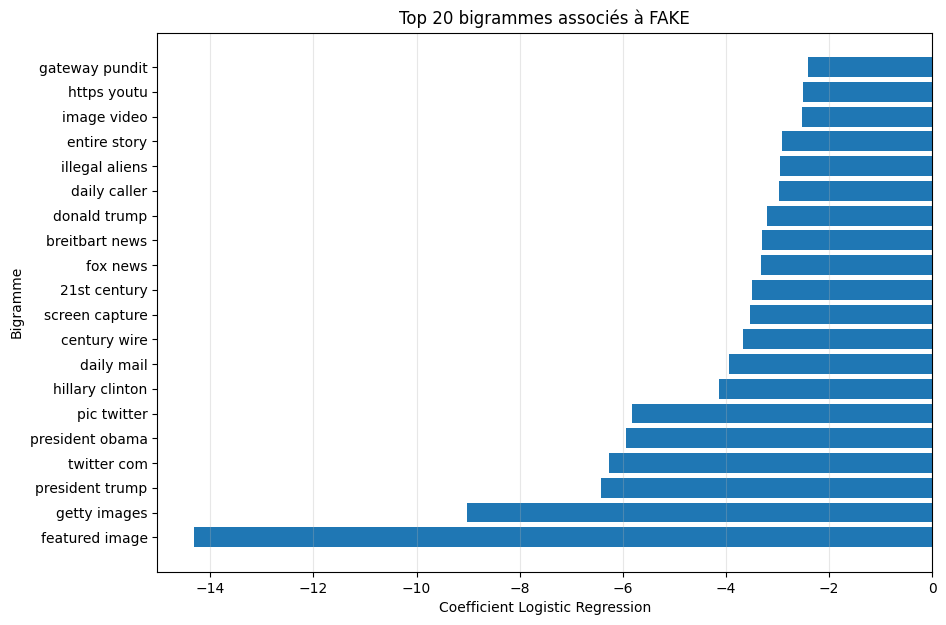


PRÉDICTION DU MODÈLE
Classe prédite : FAKE
Probabilité Fake : 0.6822
Probabilité Real : 0.3178
Score brut : -0.7639
Intercept : -0.5911

BIGRAMMES QUI POUSSENT VERS REAL


,feature,tfidf,coefficient,contribution
0,new policy,0.6300,0.2485,0.1566
1,president said,0.2449,0.3266,0.0800
2,officials washington,0.3360,0.2037,0.0684
3,said details,0.3607,0.0556,0.0201
4,announced new,0.3422,0.0078,0.0027



BIGRAMMES QUI POUSSENT VERS FAKE


,feature,tfidf,coefficient,contribution
6,press conference,0.2348,-2.1286,-0.4998
5,washington president,0.3575,-0.0021,-0.0008



DÉCOMPOSITION DE LA DÉCISION
Intercept               : -0.5911
Somme des contributions : -0.1728
Score reconstruit        : -0.7639
Score du modèle          : -0.7639


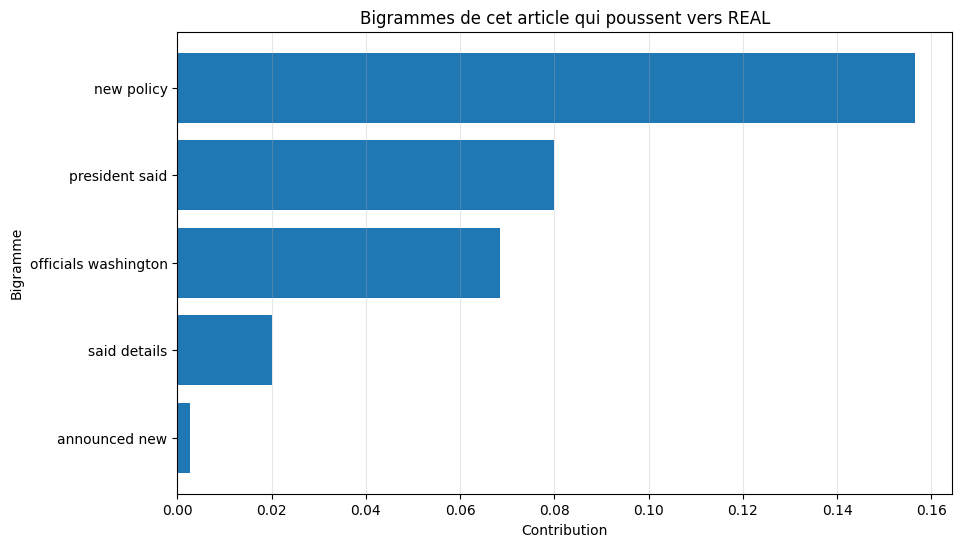

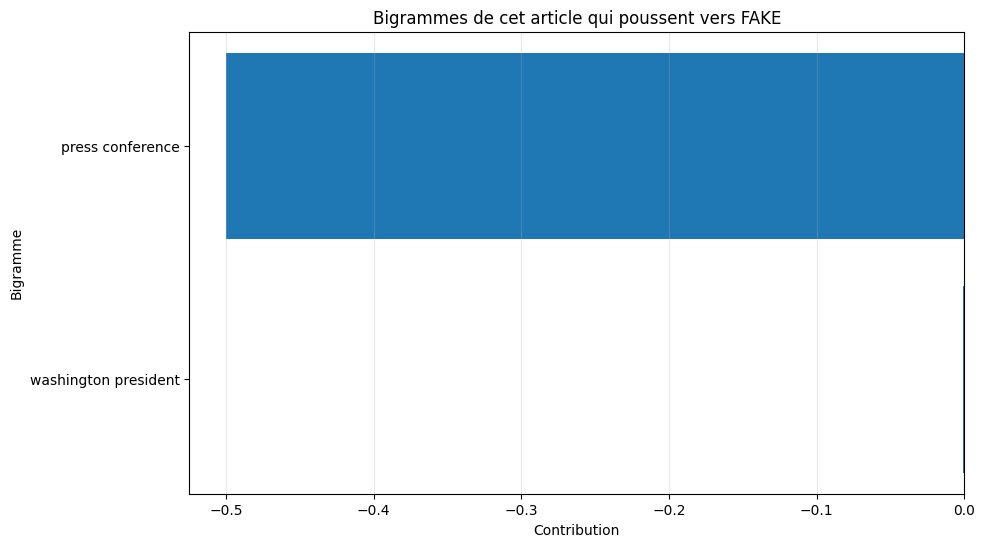

In [87]:
# ============================================================
# EXPLICABILITÉ DU MODÈLE
# CONTENT + BIGRAMMES + TF-IDF + LOGISTIC REGRESSION
#
# Labels :
# 0 = Fake
# 1 = Real
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. RÉCUPÉRER LES FEATURES ET LES COEFFICIENTS
# ============================================================

features = tfidf_content_bi.get_feature_names_out()

coefficients = model_content_bi.coef_[0]

intercept = model_content_bi.intercept_[0]


print("Nombre de features :", len(features))

print(
    "Classes du modèle :",
    model_content_bi.classes_
)

print(
    "Intercept :",
    intercept
)


# ============================================================
# 2. DATAFRAME DES COEFFICIENTS
# ============================================================

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': coefficients
})


# Trier du plus positif au plus négatif
coef_df = coef_df.sort_values(
    'coefficient',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 3. FEATURES QUI POUSSENT LE PLUS VERS REAL
# ============================================================

# Comme :
# 0 = Fake
# 1 = Real
#
# coefficient positif → Real
# coefficient négatif → Fake

top_real = coef_df.nlargest(
    20,
    'coefficient'
)

print("\n======================================")
print("TOP 20 BIGRAMMES → REAL")
print("======================================")

display(top_real)


# ============================================================
# 4. FEATURES QUI POUSSENT LE PLUS VERS FAKE
# ============================================================

top_fake = coef_df.nsmallest(
    20,
    'coefficient'
)

print("\n======================================")
print("TOP 20 BIGRAMMES → FAKE")
print("======================================")

display(top_fake)


# ============================================================
# 5. GRAPHIQUE DES FEATURES → REAL
# ============================================================

plt.figure(figsize=(10, 7))

plt.barh(
    top_real['feature'][::-1],
    top_real['coefficient'][::-1]
)

plt.xlabel(
    "Coefficient Logistic Regression"
)

plt.ylabel(
    "Bigramme"
)

plt.title(
    "Top 20 bigrammes associés à REAL"
)

plt.grid(axis='x', alpha=0.3)

plt.show()


# ============================================================
# 6. GRAPHIQUE DES FEATURES → FAKE
# ============================================================

plt.figure(figsize=(10, 7))

plt.barh(
    top_fake['feature'],
    top_fake['coefficient']
)

plt.xlabel(
    "Coefficient Logistic Regression"
)

plt.ylabel(
    "Bigramme"
)

plt.title(
    "Top 20 bigrammes associés à FAKE"
)

plt.grid(axis='x', alpha=0.3)

plt.show()


# ============================================================
# 7. FONCTION POUR EXPLIQUER UNE NOUVELLE PRÉDICTION
# ============================================================

def explain_prediction(
    title,
    text,
    vectorizer,
    model,
    top_n=15
):

    # --------------------------------------------------------
    # Construire content exactement comme pendant l'entraînement
    # --------------------------------------------------------

    content = (
        str(title).strip()
        + " "
        + str(text).strip()
    )


    # --------------------------------------------------------
    # Transformer avec le TF-IDF déjà entraîné
    # --------------------------------------------------------

    x = vectorizer.transform(
        [content]
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    prediction = model.predict(
        x
    )[0]


    # --------------------------------------------------------
    # Probabilités
    # --------------------------------------------------------

    probabilities = model.predict_proba(
        x
    )[0]


    prob_fake = probabilities[
        list(model.classes_).index(0)
    ]

    prob_real = probabilities[
        list(model.classes_).index(1)
    ]


    # --------------------------------------------------------
    # Score brut de Logistic Regression
    # --------------------------------------------------------

    decision_score = model.decision_function(
        x
    )[0]


    # --------------------------------------------------------
    # Récupérer les features
    # --------------------------------------------------------

    feature_names = vectorizer.get_feature_names_out()

    coef = model.coef_[0]


    # --------------------------------------------------------
    # IMPORTANT :
    # On travaille directement avec la matrice sparse
    # pour récupérer uniquement les bigrammes présents.
    # --------------------------------------------------------

    indices_present = x.indices

    tfidf_values = x.data


    # Coefficients correspondant aux features présentes
    local_coefficients = coef[
        indices_present
    ]


    # --------------------------------------------------------
    # CONTRIBUTION =
    # TF-IDF × coefficient
    # --------------------------------------------------------

    contributions = (
        tfidf_values
        *
        local_coefficients
    )


    # --------------------------------------------------------
    # DataFrame explicatif
    # --------------------------------------------------------

    explanation = pd.DataFrame({

        'feature':
            feature_names[
                indices_present
            ],

        'tfidf':
            tfidf_values,

        'coefficient':
            local_coefficients,

        'contribution':
            contributions

    })


    # Trier
    explanation = explanation.sort_values(
        'contribution',
        ascending=False
    ).reset_index(drop=True)


    # --------------------------------------------------------
    # Features qui poussent vers REAL
    # --------------------------------------------------------

    toward_real = (
        explanation[
            explanation['contribution'] > 0
        ]
        .head(top_n)
        .copy()
    )


    # --------------------------------------------------------
    # Features qui poussent vers FAKE
    # --------------------------------------------------------

    toward_fake = (
        explanation[
            explanation['contribution'] < 0
        ]
        .sort_values(
            'contribution'
        )
        .head(top_n)
        .copy()
    )


    # ========================================================
    # AFFICHAGE DE LA PRÉDICTION
    # ========================================================

    print(
        "\n======================================"
    )

    print(
        "PRÉDICTION DU MODÈLE"
    )

    print(
        "======================================"
    )


    print(
        "Classe prédite :",
        "REAL" if prediction == 1 else "FAKE"
    )

    print(
        f"Probabilité Fake : "
        f"{prob_fake:.4f}"
    )

    print(
        f"Probabilité Real : "
        f"{prob_real:.4f}"
    )

    print(
        f"Score brut : "
        f"{decision_score:.4f}"
    )

    print(
        f"Intercept : "
        f"{model.intercept_[0]:.4f}"
    )


    # ========================================================
    # BIGRAMMES QUI POUSSENT VERS REAL
    # ========================================================

    print(
        "\n======================================"
    )

    print(
        "BIGRAMMES QUI POUSSENT VERS REAL"
    )

    print(
        "======================================"
    )

    if len(toward_real) > 0:

        display(
            toward_real[
                [
                    'feature',
                    'tfidf',
                    'coefficient',
                    'contribution'
                ]
            ].round(4)
        )

    else:

        print(
            "Aucun bigramme ne pousse vers Real."
        )


    # ========================================================
    # BIGRAMMES QUI POUSSENT VERS FAKE
    # ========================================================

    print(
        "\n======================================"
    )

    print(
        "BIGRAMMES QUI POUSSENT VERS FAKE"
    )

    print(
        "======================================"
    )

    if len(toward_fake) > 0:

        display(
            toward_fake[
                [
                    'feature',
                    'tfidf',
                    'coefficient',
                    'contribution'
                ]
            ].round(4)
        )

    else:

        print(
            "Aucun bigramme ne pousse vers Fake."
        )


    # ========================================================
    # VÉRIFIER LA SOMME DES CONTRIBUTIONS
    # ========================================================

    sum_contributions = (
        explanation['contribution'].sum()
    )

    reconstructed_score = (
        model.intercept_[0]
        +
        sum_contributions
    )


    print(
        "\n======================================"
    )

    print(
        "DÉCOMPOSITION DE LA DÉCISION"
    )

    print(
        "======================================"
    )

    print(
        f"Intercept               : "
        f"{model.intercept_[0]:.4f}"
    )

    print(
        f"Somme des contributions : "
        f"{sum_contributions:.4f}"
    )

    print(
        f"Score reconstruit        : "
        f"{reconstructed_score:.4f}"
    )

    print(
        f"Score du modèle          : "
        f"{decision_score:.4f}"
    )


    # ========================================================
    # GRAPHIQUE LOCAL → REAL
    # ========================================================

    if len(toward_real) > 0:

        plot_real = toward_real.sort_values(
            'contribution'
        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.barh(
            plot_real['feature'],
            plot_real['contribution']
        )

        plt.xlabel(
            "Contribution"
        )

        plt.ylabel(
            "Bigramme"
        )

        plt.title(
            "Bigrammes de cet article qui poussent vers REAL"
        )

        plt.grid(
            axis='x',
            alpha=0.3
        )

        plt.show()


    # ========================================================
    # GRAPHIQUE LOCAL → FAKE
    # ========================================================

    if len(toward_fake) > 0:

        plot_fake = toward_fake.sort_values(
            'contribution',
            ascending=False
        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.barh(
            plot_fake['feature'],
            plot_fake['contribution']
        )

        plt.xlabel(
            "Contribution"
        )

        plt.ylabel(
            "Bigramme"
        )

        plt.title(
            "Bigrammes de cet article qui poussent vers FAKE"
        )

        plt.grid(
            axis='x',
            alpha=0.3
        )

        plt.show()


    # ========================================================
    # RETOURNER LES RÉSULTATS
    # ========================================================

    return {
        'prediction': prediction,
        'prob_fake': prob_fake,
        'prob_real': prob_real,
        'decision_score': decision_score,
        'explanation': explanation,
        'toward_real': toward_real,
        'toward_fake': toward_fake
    }


# ============================================================
# 8. EXEMPLE DE NOUVEL ARTICLE
# ============================================================

new_title = """
Government announces new policy after meeting
"""

new_text = """
The government announced a new policy following discussions
with officials in Washington. The president said more details
would be released during a press conference.
"""


# ============================================================
# 9. EXPLIQUER CETTE PRÉDICTION
# ============================================================

result_explanation = explain_prediction(

    title=new_title,

    text=new_text,

    vectorizer=tfidf_content_bi,

    model=model_content_bi,

    top_n=15
)

# DeBERTa gelé + extraction des embeddings

In [6]:
# ============================================================
# CELLULE 1
# DeBERTa-v3-base GELÉ comme extracteur de features
# content = title + text
# Mean Pooling
# ============================================================

# Si nécessaire sur Kaggle :
# !pip install -q transformers sentencepiece accelerate

import time
import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel
)

from sklearn.model_selection import train_test_split


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print(
        "GPU :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 2. CRÉER CONTENT = TITLE + TEXT
# ============================================================

df['content'] = (
    df['title'].fillna('').str.strip()
    + ' '
    + df['text'].fillna('').str.strip()
)

print(
    "Nombre d'articles :",
    len(df)
)

print(
    "\nExemple de content :\n",
    df['content'].iloc[0][:500]
)


# ============================================================
# 3. TRAIN / VALIDATION / TEST
# 70% / 15% / 15%
# ============================================================

indices = df.index
y = df['label']


train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)


val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=df.loc[temp_idx, 'label']
)


X_train = df.loc[
    train_idx,
    'content'
].reset_index(drop=True)

X_val = df.loc[
    val_idx,
    'content'
].reset_index(drop=True)

X_test = df.loc[
    test_idx,
    'content'
].reset_index(drop=True)


y_train = df.loc[
    train_idx,
    'label'
].reset_index(drop=True)

y_val = df.loc[
    val_idx,
    'label'
].reset_index(drop=True)

y_test = df.loc[
    test_idx,
    'label'
].reset_index(drop=True)


print("\n===== SPLIT =====")

print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))


# ============================================================
# 4. CHARGER DeBERTa-v3-base
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

deberta = AutoModel.from_pretrained(
    MODEL_NAME
)

deberta.to(device)


# ============================================================
# 5. GELER DeBERTa
# ============================================================

for param in deberta.parameters():
    param.requires_grad = False

deberta.eval()


print(
    "\nTous les paramètres DeBERTa sont gelés :",
    not any(
        p.requires_grad
        for p in deberta.parameters()
    )
)


# ============================================================
# 6. DATASET PYTORCH
# ============================================================

class NewsDataset(Dataset):

    def __init__(
        self,
        texts,
        tokenizer,
        max_length=512
    ):

        self.texts = texts.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        text = str(
            self.texts[idx]
        )

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids':
                encoding[
                    'input_ids'
                ].squeeze(0),

            'attention_mask':
                encoding[
                    'attention_mask'
                ].squeeze(0)
        }


# ============================================================
# 7. DATA LOADERS
# ============================================================

BATCH_SIZE = 16
MAX_LENGTH = 512


train_dataset = NewsDataset(
    X_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = NewsDataset(
    X_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = NewsDataset(
    X_test,
    tokenizer,
    MAX_LENGTH
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 8. MEAN POOLING
# ============================================================

def mean_pooling(
    token_embeddings,
    attention_mask
):

    # attention_mask :
    # 1 = vrai token
    # 0 = padding

    mask = attention_mask.unsqueeze(
        -1
    ).expand(
        token_embeddings.size()
    ).float()

    # Somme uniquement sur les vrais tokens
    summed_embeddings = torch.sum(
        token_embeddings * mask,
        dim=1
    )

    # Nombre de vrais tokens
    summed_mask = torch.clamp(
        mask.sum(dim=1),
        min=1e-9
    )

    # Moyenne
    return (
        summed_embeddings /
        summed_mask
    )


# ============================================================
# 9. FONCTION D'EXTRACTION
# ============================================================

def extract_embeddings(
    model,
    dataloader,
    device
):

    all_embeddings = []

    model.eval()

    with torch.no_grad():

        for batch_num, batch in enumerate(
            dataloader
        ):

            input_ids = batch[
                'input_ids'
            ].to(device)

            attention_mask = batch[
                'attention_mask'
            ].to(device)


            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )


            # Shape :
            # batch × tokens × 768

            token_embeddings = (
                outputs.last_hidden_state
            )


            # Mean Pooling :
            # batch × 768

            sentence_embeddings = mean_pooling(
                token_embeddings,
                attention_mask
            )


            all_embeddings.append(
                sentence_embeddings.cpu().numpy()
            )


            if (batch_num + 1) % 100 == 0:

                print(
                    f"Batch {batch_num + 1}"
                    f"/{len(dataloader)}"
                )


    return np.vstack(
        all_embeddings
    )


# ============================================================
# 10. EXTRAIRE LES EMBEDDINGS
# ============================================================

print(
    "\n===== EXTRACTION TRAIN ====="
)

start_train_emb = time.perf_counter()

X_train_emb = extract_embeddings(
    deberta,
    train_loader,
    device
)

train_embedding_time = (
    time.perf_counter()
    -
    start_train_emb
)


print(
    "\n===== EXTRACTION VALIDATION ====="
)

start_val_emb = time.perf_counter()

X_val_emb = extract_embeddings(
    deberta,
    val_loader,
    device
)

val_embedding_time = (
    time.perf_counter()
    -
    start_val_emb
)


print(
    "\n===== EXTRACTION TEST ====="
)

start_test_emb = time.perf_counter()

X_test_emb = extract_embeddings(
    deberta,
    test_loader,
    device
)

test_embedding_time = (
    time.perf_counter()
    -
    start_test_emb
)


# ============================================================
# 11. VÉRIFIER LES SHAPES
# ============================================================

print(
    "\n===== SHAPES EMBEDDINGS ====="
)

print(
    "Train      :",
    X_train_emb.shape
)

print(
    "Validation :",
    X_val_emb.shape
)

print(
    "Test       :",
    X_test_emb.shape
)


print(
    "\n===== TEMPS EXTRACTION ====="
)

print(
    f"Train      : "
    f"{train_embedding_time:.2f} s"
)

print(
    f"Validation : "
    f"{val_embedding_time:.2f} s"
)

print(
    f"Test       : "
    f"{test_embedding_time:.2f} s"
)

Device : cuda
GPU : Tesla T4
Nombre d'articles : 44898

Exemple de content :
 Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto

===== SPLIT =====
Train      : 31428
Validation : 6735
Test       : 6735


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]


Tous les paramètres DeBERTa sont gelés : True

===== EXTRACTION TRAIN =====
Batch 100/1965
Batch 200/1965
Batch 300/1965
Batch 400/1965
Batch 500/1965
Batch 600/1965
Batch 700/1965
Batch 800/1965
Batch 900/1965
Batch 1000/1965
Batch 1100/1965
Batch 1200/1965
Batch 1300/1965
Batch 1400/1965
Batch 1500/1965
Batch 1600/1965
Batch 1700/1965
Batch 1800/1965
Batch 300/421
Batch 400/421

===== EXTRACTION TEST =====
Batch 100/421
Batch 200/421
Batch 300/421
Batch 400/421

===== SHAPES EMBEDDINGS =====
Train      : (31428, 768)
Validation : (6735, 768)
Test       : (6735, 768)

===== TEMPS EXTRACTION =====
Train      : 646.07 s
Validation : 138.35 s
Test       : 138.77 s


# Logistic Regression + toutes les métriques

Temps entraînement Logistic Regression : 9.4650 secondes

===== MÉTRIQUES =====


,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,ROC-AUC,Log Loss,MCC
Train,0.9983,0.9983,0.9984,0.9983,0.9983,0.9983,0.9983,0.9983,1.0000,0.0096,0.9967
Validation,0.9966,0.9966,0.9965,0.9966,0.9966,0.9966,0.9966,0.9966,0.9998,0.0139,0.9932
Test,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9997,0.0142,0.9940



===== CLASSIFICATION REPORT TEST =====

              precision    recall  f1-score   support

        Fake     0.9974    0.9969    0.9972      3523
        Real     0.9966    0.9972    0.9969      3212

    accuracy                         0.9970      6735
   macro avg     0.9970    0.9970    0.9970      6735
weighted avg     0.9970    0.9970    0.9970      6735


===== CONFUSION MATRIX =====
[[3512   11]
 [   9 3203]]


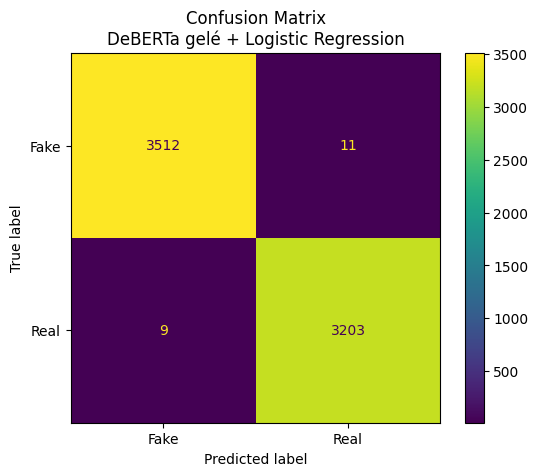


===== TAUX D'ERREUR =====
Train      : 0.0017
Validation : 0.0034
Test       : 0.003


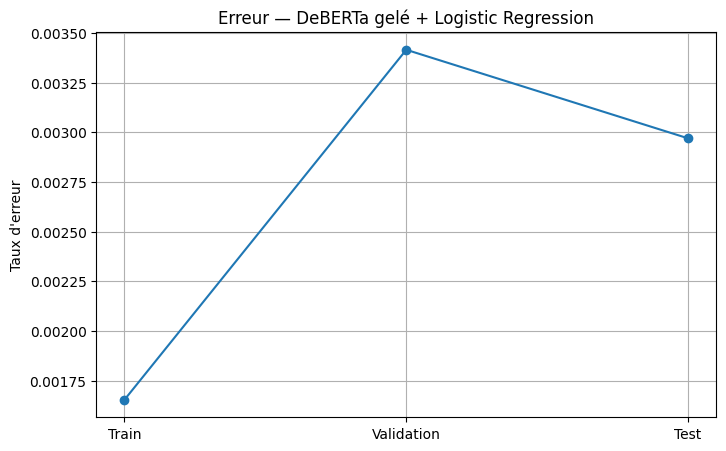


===== OVERFITTING =====
Accuracy Train      : 0.9983
Accuracy Validation : 0.9966
Gap                 : 0.0018


In [7]:
# ============================================================
# CELLULE 2
# LOGISTIC REGRESSION SUR LES EMBEDDINGS DeBERTa
# + MÉTRIQUES + CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. LOGISTIC REGRESSION
# ============================================================

classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)


# ============================================================
# 2. TEMPS D'ENTRAÎNEMENT
# ============================================================

start_training = time.perf_counter()

classifier.fit(
    X_train_emb,
    y_train
)

training_time = (
    time.perf_counter()
    -
    start_training
)


print(
    f"Temps entraînement Logistic Regression : "
    f"{training_time:.4f} secondes"
)


# ============================================================
# 3. PRÉDICTIONS
# ============================================================

pred_train = classifier.predict(
    X_train_emb
)

pred_val = classifier.predict(
    X_val_emb
)

pred_test = classifier.predict(
    X_test_emb
)


# Probabilités classe 1 = Real

prob_train = classifier.predict_proba(
    X_train_emb
)[:, 1]

prob_val = classifier.predict_proba(
    X_val_emb
)[:, 1]

prob_test = classifier.predict_proba(
    X_test_emb
)[:, 1]


# ============================================================
# 4. FONCTION MÉTRIQUES
# ============================================================

def get_metrics(
    y_true,
    y_pred,
    y_prob
):

    return {

        'Accuracy':
            accuracy_score(
                y_true,
                y_pred
            ),

        'Balanced Accuracy':
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        'Precision Macro':
            precision_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Recall Macro':
            recall_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'F1 Macro':
            f1_score(
                y_true,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Precision Weighted':
            precision_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'Recall Weighted':
            recall_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'F1 Weighted':
            f1_score(
                y_true,
                y_pred,
                average='weighted',
                zero_division=0
            ),

        'ROC-AUC':
            roc_auc_score(
                y_true,
                y_prob
            ),

        'Log Loss':
            log_loss(
                y_true,
                y_prob
            ),

        'MCC':
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }


# ============================================================
# 5. TABLEAU TRAIN / VALIDATION / TEST
# ============================================================

results_deberta = pd.DataFrame({

    'Train': get_metrics(
        y_train,
        pred_train,
        prob_train
    ),

    'Validation': get_metrics(
        y_val,
        pred_val,
        prob_val
    ),

    'Test': get_metrics(
        y_test,
        pred_test,
        prob_test
    )

}).T


print(
    "\n===== MÉTRIQUES ====="
)

display(
    results_deberta.round(4)
)


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print(
    "\n===== CLASSIFICATION REPORT TEST =====\n"
)

print(
    classification_report(
        y_test,
        pred_test,
        target_names=[
            'Fake',
            'Real'
        ],
        digits=4
    )
)


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    pred_test
)

print(
    "\n===== CONFUSION MATRIX ====="
)

print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Fake',
        'Real'
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix\n"
    "DeBERTa gelé + Logistic Regression"
)

plt.show()


# ============================================================
# 8. ERREUR TRAIN / VALIDATION / TEST
# ============================================================

train_error = (
    1 -
    accuracy_score(
        y_train,
        pred_train
    )
)

val_error = (
    1 -
    accuracy_score(
        y_val,
        pred_val
    )
)

test_error = (
    1 -
    accuracy_score(
        y_test,
        pred_test
    )
)


print(
    "\n===== TAUX D'ERREUR ====="
)

print(
    "Train      :",
    round(train_error, 4)
)

print(
    "Validation :",
    round(val_error, 4)
)

print(
    "Test       :",
    round(test_error, 4)
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    ['Train', 'Validation', 'Test'],
    [
        train_error,
        val_error,
        test_error
    ],
    marker='o'
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Erreur — DeBERTa gelé + Logistic Regression"
)

plt.grid()

plt.show()


# ============================================================
# 9. GAP
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    pred_train
)

val_accuracy = accuracy_score(
    y_val,
    pred_val
)

gap = (
    train_accuracy -
    val_accuracy
)


print(
    "\n===== OVERFITTING ====="
)

print(
    "Accuracy Train      :",
    round(train_accuracy, 4)
)

print(
    "Accuracy Validation :",
    round(val_accuracy, 4)
)

print(
    "Gap                 :",
    round(gap, 4)
)

# Nouvelle prédiction + temps de réponse

In [8]:
# ============================================================
# CELLULE 3
# NOUVELLE PRÉDICTION
# + LATENCE COMPLÈTE
# ============================================================


# ============================================================
# 1. FONCTION POUR EXTRAIRE UN SEUL EMBEDDING
# ============================================================

def encode_single_text(
    text,
    tokenizer,
    model,
    device,
    max_length=512
):

    encoding = tokenizer(
        text,
        max_length=max_length,
        truncation=True,
        padding=True,
        return_tensors='pt'
    )


    input_ids = encoding[
        'input_ids'
    ].to(device)

    attention_mask = encoding[
        'attention_mask'
    ].to(device)


    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        token_embeddings = (
            outputs.last_hidden_state
        )


        embedding = mean_pooling(
            token_embeddings,
            attention_mask
        )


    return embedding.cpu().numpy()


# ============================================================
# 2. NOUVEL ARTICLE
# ============================================================

new_title = """
Government announces new policy after meeting
"""

new_text = """
The government announced a new policy following discussions
with officials in Washington. The president said more details
would be released during a press conference.
"""


new_content = (
    new_title.strip()
    + " "
    + new_text.strip()
)


# ============================================================
# 3. WARM-UP GPU
# ============================================================

_ = encode_single_text(
    new_content,
    tokenizer,
    deberta,
    device
)

if torch.cuda.is_available():
    torch.cuda.synchronize()


# ============================================================
# 4. UNE PRÉDICTION COMPLÈTE
# ============================================================

if torch.cuda.is_available():
    torch.cuda.synchronize()

start_prediction = time.perf_counter()


# Feature extraction
new_embedding = encode_single_text(
    new_content,
    tokenizer,
    deberta,
    device
)


# Logistic Regression
prediction = classifier.predict(
    new_embedding
)[0]

probability = classifier.predict_proba(
    new_embedding
)[0]


if torch.cuda.is_available():
    torch.cuda.synchronize()

end_prediction = time.perf_counter()


prediction_time = (
    end_prediction -
    start_prediction
)


print(
    "===== NOUVELLE PRÉDICTION ====="
)

print(
    "Prédiction :",
    "Real" if prediction == 1 else "Fake"
)

print(
    f"Probabilité Fake : "
    f"{probability[0]:.4f}"
)

print(
    f"Probabilité Real : "
    f"{probability[1]:.4f}"
)

print(
    f"\nTemps total de réponse : "
    f"{prediction_time * 1000:.2f} ms"
)


# ============================================================
# 5. LATENCE MOYENNE
# ============================================================

n_runs = 50

times = []


for _ in range(n_runs):

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()


    embedding = encode_single_text(
        new_content,
        tokenizer,
        deberta,
        device
    )


    _ = classifier.predict(
        embedding
    )


    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()


    times.append(
        end - start
    )


times = np.array(
    times
)


print(
    "\n===== LATENCE ====="
)

print(
    f"Temps moyen   : "
    f"{times.mean() * 1000:.2f} ms"
)

print(
    f"Temps médian  : "
    f"{np.median(times) * 1000:.2f} ms"
)

print(
    f"Temps minimum : "
    f"{times.min() * 1000:.2f} ms"
)

print(
    f"Temps maximum : "
    f"{times.max() * 1000:.2f} ms"
)


# ============================================================
# 6. RÉSUMÉ FINAL
# ============================================================

summary_deberta = pd.DataFrame({

    'Metric': [

        'Train embedding extraction time (s)',

        'Validation embedding extraction time (s)',

        'Test embedding extraction time (s)',

        'Logistic Regression training time (s)',

        'Single prediction latency (ms)',

        'Average prediction latency (ms)',

        'Test Accuracy',

        'Test Balanced Accuracy',

        'Test Precision Macro',

        'Test Recall Macro',

        'Test F1 Macro',

        'Test Precision Weighted',

        'Test Recall Weighted',

        'Test F1 Weighted',

        'Test ROC-AUC',

        'Test Log Loss',

        'Test MCC',

        'Train-Validation Gap'
    ],

    'Value': [

        train_embedding_time,

        val_embedding_time,

        test_embedding_time,

        training_time,

        prediction_time * 1000,

        times.mean() * 1000,

        results_deberta.loc[
            'Test',
            'Accuracy'
        ],

        results_deberta.loc[
            'Test',
            'Balanced Accuracy'
        ],

        results_deberta.loc[
            'Test',
            'Precision Macro'
        ],

        results_deberta.loc[
            'Test',
            'Recall Macro'
        ],

        results_deberta.loc[
            'Test',
            'F1 Macro'
        ],

        results_deberta.loc[
            'Test',
            'Precision Weighted'
        ],

        results_deberta.loc[
            'Test',
            'Recall Weighted'
        ],

        results_deberta.loc[
            'Test',
            'F1 Weighted'
        ],

        results_deberta.loc[
            'Test',
            'ROC-AUC'
        ],

        results_deberta.loc[
            'Test',
            'Log Loss'
        ],

        results_deberta.loc[
            'Test',
            'MCC'
        ],

        gap
    ]

})


print(
    "\n===== RÉSUMÉ FINAL ====="
)

display(
    summary_deberta.round(4)
)

===== NOUVELLE PRÉDICTION =====
Prédiction : Fake
Probabilité Fake : 0.5259
Probabilité Real : 0.4741

Temps total de réponse : 127.75 ms

===== LATENCE =====
Temps moyen   : 23.91 ms
Temps médian  : 23.98 ms
Temps minimum : 22.29 ms
Temps maximum : 26.24 ms

===== RÉSUMÉ FINAL =====


,Metric,Value
0,Train embedding extraction time (s),646.0656
1,Validation embedding extraction time (s),138.3545
2,Test embedding extraction time (s),138.7720
3,Logistic Regression training time (s),9.4650
4,Single prediction latency (ms),127.7513
5,Average prediction latency (ms),23.9132
6,Test Accuracy,0.9970
7,Test Balanced Accuracy,0.9970
8,Test Precision Macro,0.9970
9,Test Recall Macro,0.9970


===== TAUX D'ERREUR =====
Train      : 0.0017
Validation : 0.0034
Test       : 0.0030


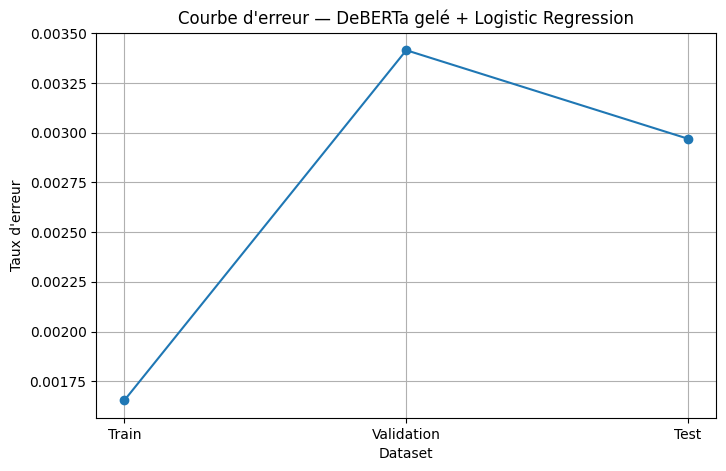

In [9]:
# ============================================================
# COURBE D'ERREUR
# DeBERTa gelé + Logistic Regression
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


# 1. Calcul des erreurs
train_error = 1 - accuracy_score(
    y_train,
    pred_train
)

val_error = 1 - accuracy_score(
    y_val,
    pred_val
)

test_error = 1 - accuracy_score(
    y_test,
    pred_test
)


# 2. Afficher les valeurs
print("===== TAUX D'ERREUR =====")

print(
    f"Train      : {train_error:.4f}"
)

print(
    f"Validation : {val_error:.4f}"
)

print(
    f"Test       : {test_error:.4f}"
)


# 3. Préparer le graphique
datasets = [
    'Train',
    'Validation',
    'Test'
]

errors = [
    train_error,
    val_error,
    test_error
]


# 4. Plot
plt.figure(figsize=(8, 5))

plt.plot(
    datasets,
    errors,
    marker='o'
)

plt.xlabel(
    "Dataset"
)

plt.ylabel(
    "Taux d'erreur"
)

plt.title(
    "Courbe d'erreur — DeBERTa gelé + Logistic Regression"
)

plt.grid()

plt.show()

===== LEARNING CURVE =====
Train size:  2514 | Train Error: 0.0026 | Validation Error: 0.0152
Train size:  7039 | Train Error: 0.0021 | Validation Error: 0.0076
Train size: 11565 | Train Error: 0.0016 | Validation Error: 0.0059
Train size: 16090 | Train Error: 0.0018 | Validation Error: 0.0047
Train size: 20616 | Train Error: 0.0016 | Validation Error: 0.0043
Train size: 25142 | Train Error: 0.0016 | Validation Error: 0.0037


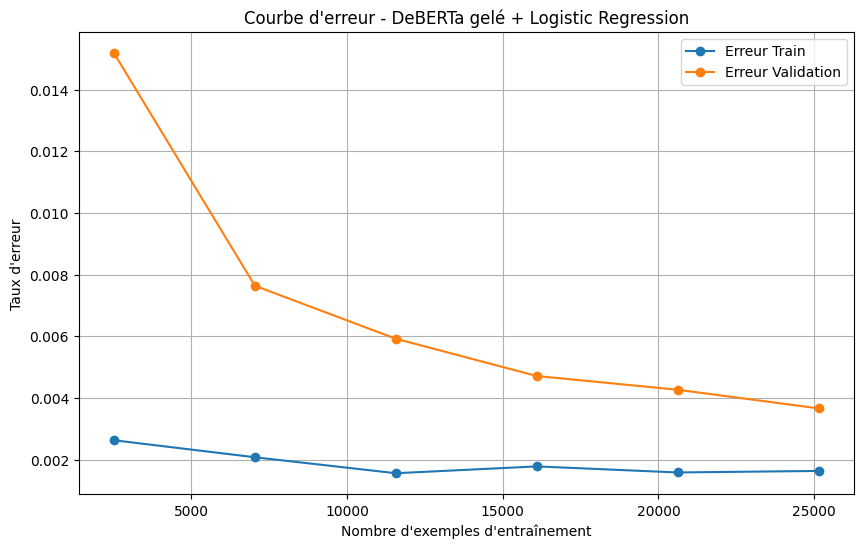

In [13]:
# ============================================================
# COURBE D'ERREUR - DeBERTa gelé + Logistic Regression
# même style que ton image
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, StratifiedKFold


# ============================================================
# 1. MODÈLE
# ============================================================

model_lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)


# ============================================================
# 2. CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. LEARNING CURVE
# ============================================================

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_lr,
    X=X_train_emb,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)


# ============================================================
# 4. MOYENNES
# ============================================================

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)


# ============================================================
# 5. CONVERSION EN ERREUR
# ============================================================

train_error = 1 - train_mean
val_error = 1 - val_mean


# ============================================================
# 6. AFFICHAGE DES VALEURS
# ============================================================

print("===== LEARNING CURVE =====")

for size, tr_err, va_err in zip(train_sizes, train_error, val_error):
    print(
        f"Train size: {size:5d} | "
        f"Train Error: {tr_err:.4f} | "
        f"Validation Error: {va_err:.4f}"
    )


# ============================================================
# 7. PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_error,
    marker='o',
    label='Erreur Train'
)

plt.plot(
    train_sizes,
    val_error,
    marker='o',
    label='Erreur Validation'
)

plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("Taux d'erreur")
plt.title("Courbe d'erreur - DeBERTa gelé + Logistic Regression")
plt.legend()
plt.grid()

plt.show()

# Préparation des données + DeBERTa pour classification

Device : cuda
GPU : Tesla T4

Labels : [np.int64(0), np.int64(1)]
Nombre total d'articles : 44898

========== SPLIT ==========
Train      : 31428
Validation : 6735
Test       : 6735

Distribution Train :
label
0    0.522973
1    0.477027
Name: proportion, dtype: float64

========== CONFIGURATION ==========
Epochs          : 1
Batch size      : 8
Learning rate   : 5e-06
Weight decay    : 0.01
Dropout         : 0.1
Label smoothing : 0.05


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]


Nombre batches Train : 3929
Nombre batches Validation : 842
Nombre batches Test : 842

Dropout configuré : 0.1


...

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight      

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Type poids : torch.float32

Paramètres totaux : 184,423,682
Paramètres entraînables : 184,423,682

Label smoothing : 0.05

Total training steps : 3929
Warmup steps : 392

Logits initiaux valides : True
Loss initiale : 0.6702308058738708

EPOCH 1/1
Batch 1 | Loss: 0.664695 | Grad: 7.3039 | LR: 1.28e-08
Batch 2 | Loss: 0.674583 | Grad: 8.7776 | LR: 2.55e-08
Batch 3 | Loss: 0.718205 | Grad: 7.4984 | LR: 3.83e-08
Batch 4 | Loss: 0.678056 | Grad: 9.1843 | LR: 5.10e-08
Batch 5 | Loss: 0.629512 | Grad: 7.1780 | LR: 6.38e-08
Batch 6 | Loss: 0.686531 | Grad: 8.6832 | LR: 7.65e-08
Batch 7 | Loss: 0.704263 | Grad: 6.2792 | LR: 8.93e-08
Batch 8 | Loss: 0.706565 | Grad: 8.9448 | LR: 1.02e-07
Batch 9 | Loss: 0.705390 | Grad: 9.1835 | LR: 1.15e-07
Batch 10 | Loss: 0.705925 | Grad: 15.6810 | LR: 1.28e-07
Batch 200/3929 | Loss: 0.186082
Batch 400/3929 | Loss: 0.120282
Batch 600/3929 | Loss: 0.117450
Batch 800/3929 | Loss: 0.117373
Batch 1000/3929 | Loss: 0.117211
Batch 1200/3929 | Loss: 0.117031
Batch 

,Metric,Value
0,Test Loss,0.117572
1,Accuracy,1.000000
2,Balanced Accuracy,1.000000
3,Precision Macro,1.000000
4,Recall Macro,1.000000
5,F1 Macro,1.000000
6,Precision Weighted,1.000000
7,Recall Weighted,1.000000
8,F1 Weighted,1.000000
9,ROC-AUC,1.000000



CLASSIFICATION REPORT

              precision    recall  f1-score   support

        Fake     1.0000    1.0000    1.0000      3523
        Real     1.0000    1.0000    1.0000      3212

    accuracy                         1.0000      6735
   macro avg     1.0000    1.0000    1.0000      6735
weighted avg     1.0000    1.0000    1.0000      6735


Confusion Matrix :
[[3523    0]
 [   0 3212]]


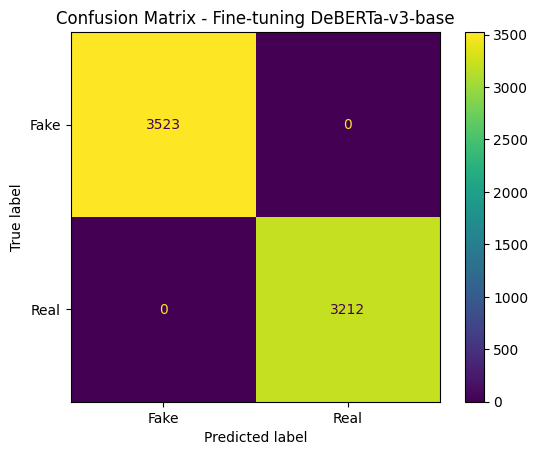

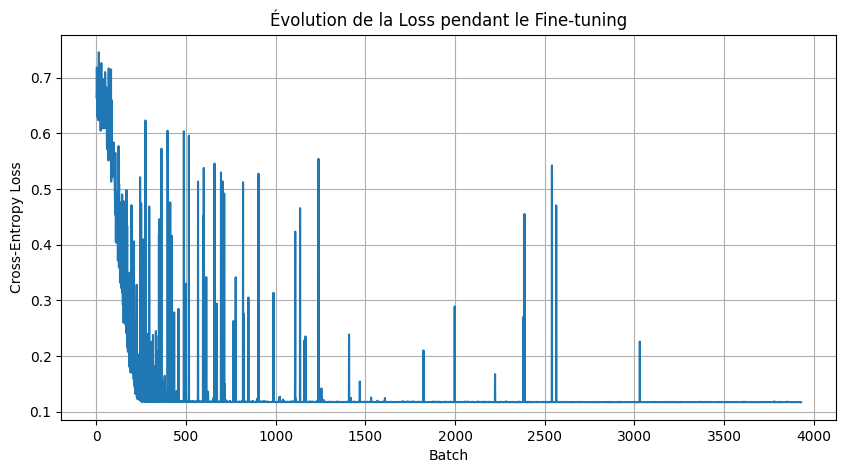

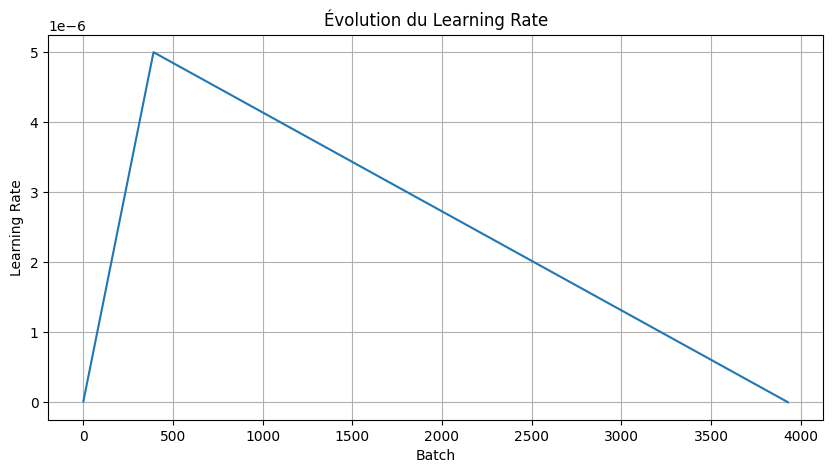


CONFIGURATION FINALE
Model            : microsoft/deberta-v3-base
Epochs           : 1
Batch size       : 8
Max length       : 512
Learning rate    : 5e-06
Weight decay     : 0.01
Dropout          : 0.1
Label smoothing  : 0.05
Gradient clipping: 0.5
Warmup           : 10%


In [5]:
# ================================================================
# FINE-TUNING COMPLET DeBERTa-v3-base
# VERSION FINALE
#
# 0 = Fake
# 1 = Real
#
# Train      = 70 %
# Validation = 15 %
# Test       = 15 %
#
# Régularisation :
# - 1 epoch
# - Dropout = 0.10
# - Label smoothing = 0.05
# - Weight decay = 0.01
# - Learning rate = 5e-6
#
# Stabilité :
# - Float32
# - Gradient clipping = 0.5
# - Warmup = 10 %
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ================================================================
# 2. REPRODUCTIBILITÉ
# ================================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


# ================================================================
# 3. DEVICE
# ================================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device :",
    device
)


if torch.cuda.is_available():

    print(
        "GPU :",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# 4. CONSTRUCTION DE CONTENT = TITLE + TEXT
# ================================================================

df = df.copy()


df["content"] = (

    df["title"]
    .fillna("")
    .astype(str)
    .str.strip()

    + " " +

    df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ================================================================
# 5. VÉRIFIER LES LABELS
# ================================================================

print(
    "\nLabels :",
    sorted(
        df["label"].unique()
    )
)


assert set(
    df["label"].unique()
).issubset({0, 1}), \
    "Les labels doivent être 0 et 1."


print(
    "Nombre total d'articles :",
    len(df)
)


# ================================================================
# 6. SPLIT 70 / 15 / 15
# ================================================================

train_df, temp_df = train_test_split(

    df[
        [
            "content",
            "label"
        ]
    ],

    test_size=0.30,

    random_state=SEED,

    stratify=df["label"]
)


val_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_df["label"]
)


train_df = (
    train_df
    .reset_index(drop=True)
)

val_df = (
    val_df
    .reset_index(drop=True)
)

test_df = (
    test_df
    .reset_index(drop=True)
)


print(
    "\n========== SPLIT =========="
)

print(
    "Train      :",
    len(train_df)
)

print(
    "Validation :",
    len(val_df)
)

print(
    "Test       :",
    len(test_df)
)


print(
    "\nDistribution Train :"
)

print(
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
)


# ================================================================
# 7. HYPERPARAMÈTRES
# ================================================================

MODEL_NAME = (
    "microsoft/deberta-v3-base"
)

MAX_LENGTH = 512

BATCH_SIZE = 8


# ------------------------------------------------
# Régularisation
# ------------------------------------------------

EPOCHS = 1

LEARNING_RATE = 5e-6

WEIGHT_DECAY = 0.01

DROPOUT = 0.10

LABEL_SMOOTHING = 0.05


# ------------------------------------------------
# Gradient clipping
# ------------------------------------------------

MAX_GRAD_NORM = 0.5


# ------------------------------------------------
# Chemin du meilleur modèle
# ------------------------------------------------

BEST_MODEL_PATH = (
    "/kaggle/working/"
    "best_deberta_v3_finetuned.pt"
)


print(
    "\n========== CONFIGURATION =========="
)

print(
    "Epochs          :",
    EPOCHS
)

print(
    "Batch size      :",
    BATCH_SIZE
)

print(
    "Learning rate   :",
    LEARNING_RATE
)

print(
    "Weight decay    :",
    WEIGHT_DECAY
)

print(
    "Dropout         :",
    DROPOUT
)

print(
    "Label smoothing :",
    LABEL_SMOOTHING
)


# ================================================================
# 8. TOKENIZER
# ================================================================

tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME
    )
)


# ================================================================
# 9. DATASET PYTORCH
# ================================================================

class NewsDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length
    ):

        self.texts = (

            dataframe["content"]
            .astype(str)
            .tolist()
        )


        self.labels = (

            dataframe["label"]
            .astype(int)
            .tolist()
        )


        self.tokenizer = tokenizer

        self.max_length = max_length


    def __len__(self):

        return len(
            self.texts
        )


    def __getitem__(
        self,
        idx
    ):

        text = self.texts[idx]

        label = self.labels[idx]


        encoding = self.tokenizer(

            text,

            max_length=self.max_length,

            truncation=True,

            padding="max_length",

            return_tensors="pt"
        )


        return {

            "input_ids":
                encoding[
                    "input_ids"
                ].squeeze(0),

            "attention_mask":
                encoding[
                    "attention_mask"
                ].squeeze(0),

            "labels":
                torch.tensor(
                    label,
                    dtype=torch.long
                )
        }


# ================================================================
# 10. DATASETS
# ================================================================

train_dataset = NewsDataset(
    train_df,
    tokenizer,
    MAX_LENGTH
)


val_dataset = NewsDataset(
    val_df,
    tokenizer,
    MAX_LENGTH
)


test_dataset = NewsDataset(
    test_df,
    tokenizer,
    MAX_LENGTH
)


# ================================================================
# 11. DATALOADERS
# ================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


# Train sans shuffle pour l'évaluation finale
train_eval_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print(
    "\nNombre batches Train :",
    len(train_loader)
)

print(
    "Nombre batches Validation :",
    len(val_loader)
)

print(
    "Nombre batches Test :",
    len(test_loader)
)


# ================================================================
# 12. NETTOYER L'ANCIEN MODÈLE
# ================================================================

try:

    del model

except:

    pass


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ================================================================
# 13. CONFIGURATION DeBERTa + DROPOUT
# ================================================================

config = AutoConfig.from_pretrained(

    MODEL_NAME,

    num_labels=2
)


# ------------------------------------------------
# Dropout interne du Transformer
# ------------------------------------------------

config.hidden_dropout_prob = (
    DROPOUT
)


# ------------------------------------------------
# Dropout sur attention
# ------------------------------------------------

config.attention_probs_dropout_prob = (
    DROPOUT
)


# ------------------------------------------------
# Dropout classification
# ------------------------------------------------

config.cls_dropout = (
    DROPOUT
)


print(
    "\nDropout configuré :",
    DROPOUT
)


# ================================================================
# 14. CHARGER DeBERTa NEUF EN FLOAT32
# ================================================================

torch.set_default_dtype(
    torch.float32
)


model = (
    AutoModelForSequenceClassification
    .from_pretrained(

        MODEL_NAME,

        config=config,

        torch_dtype=torch.float32
    )
)


model = model.float()

model.to(device)


print(
    "Type poids :",
    next(
        model.parameters()
    ).dtype
)


# ================================================================
# 15. VÉRIFIER PARAMÈTRES ENTRAÎNABLES
# ================================================================

total_parameters = sum(

    p.numel()

    for p in model.parameters()
)


trainable_parameters = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print(
    "\nParamètres totaux :",
    f"{total_parameters:,}"
)

print(
    "Paramètres entraînables :",
    f"{trainable_parameters:,}"
)


# ================================================================
# 16. LOSS + LABEL SMOOTHING
# ================================================================

criterion = torch.nn.CrossEntropyLoss(

    label_smoothing=LABEL_SMOOTHING
)


print(
    "\nLabel smoothing :",
    LABEL_SMOOTHING
)


# ================================================================
# 17. OPTIMIZER ADAMW
# ================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY,

    eps=1e-6
)


# ================================================================
# 18. SCHEDULER + WARMUP
# ================================================================

total_steps = (

    len(train_loader)

    * EPOCHS
)


warmup_steps = int(

    0.10

    * total_steps
)


scheduler = (
    get_linear_schedule_with_warmup(

        optimizer,

        num_warmup_steps=warmup_steps,

        num_training_steps=total_steps
    )
)


print(
    "\nTotal training steps :",
    total_steps
)

print(
    "Warmup steps :",
    warmup_steps
)


# ================================================================
# 19. TEST AVANT ENTRAÎNEMENT
# ================================================================

first_batch = next(
    iter(train_loader)
)


model.eval()


with torch.no_grad():


    input_ids = (

        first_batch[
            "input_ids"
        ]

        .to(device)
    )


    attention_mask = (

        first_batch[
            "attention_mask"
        ]

        .to(device)
    )


    labels = (

        first_batch[
            "labels"
        ]

        .to(device)
    )


    outputs = model(

        input_ids=input_ids,

        attention_mask=attention_mask
    )


    logits = (
        outputs.logits
    )


    initial_loss = criterion(

        logits,

        labels
    )


print(
    "\nLogits initiaux valides :",
    torch.isfinite(
        logits
    ).all().item()
)


print(
    "Loss initiale :",
    initial_loss.item()
)


if not torch.isfinite(
    initial_loss
):

    raise RuntimeError(
        "NaN avant entraînement."
    )


# ================================================================
# 20. FONCTION D'ÉVALUATION
# ================================================================

def evaluate_model(
    model,
    dataloader
):


    model.eval()


    total_loss = 0.0


    y_true = []

    y_pred = []

    y_prob = []


    with torch.no_grad():


        for batch in dataloader:


            input_ids = (

                batch[
                    "input_ids"
                ]

                .to(device)
            )


            attention_mask = (

                batch[
                    "attention_mask"
                ]

                .to(device)
            )


            labels = (

                batch[
                    "labels"
                ]

                .to(device)
            )


            outputs = model(

                input_ids=input_ids,

                attention_mask=attention_mask
            )


            logits = (
                outputs.logits
            )


            # ----------------------------------------
            # Vérification NaN
            # ----------------------------------------

            if not torch.isfinite(
                logits
            ).all():

                raise RuntimeError(
                    "NaN/Inf pendant évaluation."
                )


            loss = criterion(

                logits,

                labels
            )


            total_loss += (
                loss.item()
            )


            # ----------------------------------------
            # Probabilités
            # ----------------------------------------

            probabilities = (
                torch.softmax(
                    logits,
                    dim=1
                )
            )


            # ----------------------------------------
            # Classe finale
            # ----------------------------------------

            predictions = (
                torch.argmax(
                    probabilities,
                    dim=1
                )
            )


            y_true.extend(

                labels
                .cpu()
                .numpy()
            )


            y_pred.extend(

                predictions
                .cpu()
                .numpy()
            )


            # Probabilité classe 1 = Real
            y_prob.extend(

                probabilities[:, 1]
                .cpu()
                .numpy()
            )


    y_true = np.array(
        y_true
    )


    y_pred = np.array(
        y_pred
    )


    y_prob = np.array(
        y_prob
    )


    avg_loss = (

        total_loss

        / len(dataloader)
    )


    accuracy = accuracy_score(

        y_true,

        y_pred
    )


    f1_macro = f1_score(

        y_true,

        y_pred,

        average="macro",

        zero_division=0
    )


    return (

        avg_loss,

        accuracy,

        f1_macro,

        y_true,

        y_pred,

        y_prob
    )


# ================================================================
# 21. HISTORIQUE DE LA LOSS PAR BATCH
# ================================================================

batch_losses = []

batch_numbers = []

batch_lrs = []


# ================================================================
# 22. VARIABLES POUR MEILLEUR MODÈLE
# ================================================================

best_val_f1 = -np.inf

best_val_loss = np.inf

best_epoch = None


# ================================================================
# 23. TEMPS D'ENTRAÎNEMENT
# ================================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


training_start = (
    time.perf_counter()
)


# ================================================================
# 24. FINE-TUNING
# ================================================================

for epoch in range(EPOCHS):


    print(
        "\n===================================="
    )

    print(
        f"EPOCH {epoch + 1}/{EPOCHS}"
    )

    print(
        "===================================="
    )


    model.train()


    # ============================================================
    # BOUCLE TRAIN
    # ============================================================

    for batch_num, batch in enumerate(
        train_loader
    ):


        input_ids = (

            batch[
                "input_ids"
            ]

            .to(device)
        )


        attention_mask = (

            batch[
                "attention_mask"
            ]

            .to(device)
        )


        labels = (

            batch[
                "labels"
            ]

            .to(device)
        )


        # --------------------------------------------------------
        # Reset gradients
        # --------------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # --------------------------------------------------------
        # Forward
        # --------------------------------------------------------

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask
        )


        logits = (
            outputs.logits
        )


        # --------------------------------------------------------
        # Vérification logits
        # --------------------------------------------------------

        if not torch.isfinite(
            logits
        ).all():

            raise RuntimeError(

                f"NaN/Inf logits "
                f"au batch {batch_num+1}"
            )


        # --------------------------------------------------------
        # Loss
        # --------------------------------------------------------

        loss = criterion(

            logits,

            labels
        )


        if not torch.isfinite(
            loss
        ):

            raise RuntimeError(

                f"NaN Loss "
                f"au batch {batch_num+1}"
            )


        # --------------------------------------------------------
        # Backpropagation
        # --------------------------------------------------------

        loss.backward()


        # --------------------------------------------------------
        # Gradient clipping
        # --------------------------------------------------------

        grad_norm = (
            torch.nn.utils
            .clip_grad_norm_(

                model.parameters(),

                max_norm=MAX_GRAD_NORM
            )
        )


        if not torch.isfinite(
            grad_norm
        ):

            raise RuntimeError(

                f"NaN gradients "
                f"au batch {batch_num+1}"
            )


        # --------------------------------------------------------
        # Mise à jour poids
        # --------------------------------------------------------

        optimizer.step()


        # --------------------------------------------------------
        # Scheduler
        # --------------------------------------------------------

        scheduler.step()


        # --------------------------------------------------------
        # Historique
        # --------------------------------------------------------

        batch_losses.append(
            loss.item()
        )


        batch_numbers.append(
            batch_num + 1
        )


        batch_lrs.append(

            optimizer
            .param_groups[0]["lr"]
        )


        # --------------------------------------------------------
        # Affichage
        # --------------------------------------------------------

        if batch_num < 10:

            print(

                f"Batch {batch_num+1}"

                f" | Loss: "
                f"{loss.item():.6f}"

                f" | Grad: "
                f"{float(grad_norm):.4f}"

                f" | LR: "
                f"{optimizer.param_groups[0]['lr']:.2e}"
            )


        elif (
            batch_num + 1
        ) % 200 == 0:

            print(

                f"Batch "
                f"{batch_num+1}"
                f"/{len(train_loader)}"

                f" | Loss: "
                f"{loss.item():.6f}"
            )


    # ============================================================
    # TRAIN FINAL DE CETTE EPOCH
    # ============================================================

    (
        train_loss,
        train_accuracy,
        train_f1,
        y_train_true,
        y_train_pred,
        y_train_prob

    ) = evaluate_model(

        model,

        train_eval_loader
    )


    # ============================================================
    # VALIDATION
    # ============================================================

    (
        val_loss,
        val_accuracy,
        val_f1,
        y_val_true,
        y_val_pred,
        y_val_prob

    ) = evaluate_model(

        model,

        val_loader
    )


    # ============================================================
    # AFFICHER TRAIN / VALIDATION
    # ============================================================

    print(
        "\n========== TRAIN / VALIDATION =========="
    )


    print(
        f"Train Loss       : "
        f"{train_loss:.6f}"
    )


    print(
        f"Validation Loss  : "
        f"{val_loss:.6f}"
    )


    print(
        f"\nTrain Accuracy   : "
        f"{train_accuracy:.6f}"
    )


    print(
        f"Val Accuracy     : "
        f"{val_accuracy:.6f}"
    )


    print(
        f"\nTrain F1 Macro   : "
        f"{train_f1:.6f}"
    )


    print(
        f"Val F1 Macro     : "
        f"{val_f1:.6f}"
    )


    # ============================================================
    # SAUVEGARDE DU MEILLEUR MODÈLE
    #
    # 1. priorité : meilleur Validation F1
    # 2. si égalité : plus petite Validation Loss
    # ============================================================

    better_model = (

        (val_f1 > best_val_f1)

        or

        (
            np.isclose(
                val_f1,
                best_val_f1
            )

            and

            val_loss < best_val_loss
        )
    )


    if better_model:


        best_val_f1 = (
            val_f1
        )


        best_val_loss = (
            val_loss
        )


        best_epoch = (
            epoch + 1
        )


        torch.save(

            model.state_dict(),

            BEST_MODEL_PATH
        )


        print(
            "\n→ Meilleur modèle sauvegardé"
        )


        print(
            f"   Epoch          : "
            f"{best_epoch}"
        )


        print(
            f"   Validation F1  : "
            f"{best_val_f1:.6f}"
        )


        print(
            f"   Validation Loss: "
            f"{best_val_loss:.6f}"
        )


# ================================================================
# 25. FIN TEMPS D'ENTRAÎNEMENT
# ================================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


training_time = (

    time.perf_counter()

    - training_start
)


print(
    "\n===================================="
)

print(
    "FINE-TUNING TERMINÉ"
)

print(
    "===================================="
)


print(
    f"Temps total entraînement : "
    f"{training_time:.2f} secondes"
)


print(
    f"Soit : "
    f"{training_time / 60:.2f} minutes"
)


# ================================================================
# 26. RECHARGER LE MEILLEUR MODÈLE
# ================================================================

model.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,

        map_location=device,

        weights_only=True
    )
)


model.to(device)

model.eval()


print(
    "\nMeilleur modèle rechargé."
)

print(
    "Best epoch :",
    best_epoch
)

print(
    "Best Val F1 :",
    best_val_f1
)

print(
    "Best Val Loss :",
    best_val_loss
)


# ================================================================
# 27. TEMPS DE TEST
# ================================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


test_start = (
    time.perf_counter()
)


(
    test_loss,
    test_accuracy,
    test_f1,
    y_test_true,
    y_test_pred,
    y_test_prob

) = evaluate_model(

    model,

    test_loader
)


if torch.cuda.is_available():

    torch.cuda.synchronize()


test_time = (

    time.perf_counter()

    - test_start
)


# ================================================================
# 28. TEMPS MOYEN PAR ARTICLE
# ================================================================

average_test_time = (

    test_time

    / len(test_df)
)


print(
    "\nTemps total Test :",
    f"{test_time:.4f} secondes"
)


print(
    "Temps moyen/article :",
    f"{average_test_time * 1000:.4f} ms"
)


# ================================================================
# 29. MÉTRIQUES TEST
# ================================================================

test_balanced_accuracy = (
    balanced_accuracy_score(

        y_test_true,

        y_test_pred
    )
)


# ------------------------------------------------
# Macro
# ------------------------------------------------

test_precision_macro = (
    precision_score(

        y_test_true,

        y_test_pred,

        average="macro",

        zero_division=0
    )
)


test_recall_macro = (
    recall_score(

        y_test_true,

        y_test_pred,

        average="macro",

        zero_division=0
    )
)


test_f1_macro = (
    f1_score(

        y_test_true,

        y_test_pred,

        average="macro",

        zero_division=0
    )
)


# ------------------------------------------------
# Weighted
# ------------------------------------------------

test_precision_weighted = (
    precision_score(

        y_test_true,

        y_test_pred,

        average="weighted",

        zero_division=0
    )
)


test_recall_weighted = (
    recall_score(

        y_test_true,

        y_test_pred,

        average="weighted",

        zero_division=0
    )
)


test_f1_weighted = (
    f1_score(

        y_test_true,

        y_test_pred,

        average="weighted",

        zero_division=0
    )
)


# ------------------------------------------------
# ROC-AUC
# ------------------------------------------------

test_auc = (
    roc_auc_score(

        y_test_true,

        y_test_prob
    )
)


# ------------------------------------------------
# Log Loss
#
# Celle-ci utilise les probabilités finales,
# indépendamment du label smoothing utilisé
# pendant l'entraînement.
# ------------------------------------------------

test_logloss = (
    log_loss(

        y_test_true,

        y_test_prob
    )
)


# ------------------------------------------------
# MCC
# ------------------------------------------------

test_mcc = (
    matthews_corrcoef(

        y_test_true,

        y_test_pred
    )
)


# ================================================================
# 30. TABLEAU FINAL
# ================================================================

results = pd.DataFrame({

    "Metric": [

        "Test Loss",

        "Accuracy",

        "Balanced Accuracy",

        "Precision Macro",

        "Recall Macro",

        "F1 Macro",

        "Precision Weighted",

        "Recall Weighted",

        "F1 Weighted",

        "ROC-AUC",

        "Log Loss",

        "MCC",

        "Training Time (s)",

        "Training Time (min)",

        "Test Time (s)",

        "Average Test Time / Article (ms)"
    ],


    "Value": [

        test_loss,

        test_accuracy,

        test_balanced_accuracy,

        test_precision_macro,

        test_recall_macro,

        test_f1_macro,

        test_precision_weighted,

        test_recall_weighted,

        test_f1_weighted,

        test_auc,

        test_logloss,

        test_mcc,

        training_time,

        training_time / 60,

        test_time,

        average_test_time * 1000
    ]
})


print(
    "\n===================================="
)

print(
    "RÉSULTATS TEST"
)

print(
    "===================================="
)


display(
    results.round(6)
)


# ================================================================
# 31. CLASSIFICATION REPORT
# ================================================================

print(
    "\n===================================="
)

print(
    "CLASSIFICATION REPORT"
)

print(
    "====================================\n"
)


print(

    classification_report(

        y_test_true,

        y_test_pred,

        target_names=[
            "Fake",
            "Real"
        ],

        digits=4,

        zero_division=0
    )
)


# ================================================================
# 32. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    y_test_true,

    y_test_pred
)


print(
    "\nConfusion Matrix :"
)

print(
    cm
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Fake",
        "Real"
    ]
)


disp.plot()


plt.title(
    "Confusion Matrix - Fine-tuning DeBERTa-v3-base"
)


plt.show()


# ================================================================
# 33. COURBE DE LOSS PAR BATCH
# ================================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(

    batch_numbers,

    batch_losses
)


plt.xlabel(
    "Batch"
)


plt.ylabel(
    "Cross-Entropy Loss"
)


plt.title(
    "Évolution de la Loss pendant le Fine-tuning"
)


plt.grid()


plt.show()


# ================================================================
# 34. COURBE LEARNING RATE
# ================================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(

    batch_numbers,

    batch_lrs
)


plt.xlabel(
    "Batch"
)


plt.ylabel(
    "Learning Rate"
)


plt.title(
    "Évolution du Learning Rate"
)


plt.grid()


plt.show()


# ================================================================
# 35. RÉSUMÉ DE LA CONFIGURATION
# ================================================================

print(
    "\n===================================="
)

print(
    "CONFIGURATION FINALE"
)

print(
    "===================================="
)


print(
    f"Model            : {MODEL_NAME}"
)

print(
    f"Epochs           : {EPOCHS}"
)

print(
    f"Batch size       : {BATCH_SIZE}"
)

print(
    f"Max length       : {MAX_LENGTH}"
)

print(
    f"Learning rate    : {LEARNING_RATE}"
)

print(
    f"Weight decay     : {WEIGHT_DECAY}"
)

print(
    f"Dropout          : {DROPOUT}"
)

print(
    f"Label smoothing  : {LABEL_SMOOTHING}"
)

print(
    f"Gradient clipping: {MAX_GRAD_NORM}"
)

print(
    f"Warmup           : 10%"
)

batch 400
batch 600
batch 800
batch 1000
battch 1200 
batch 1400
batch 1600
batch 1800
batch 2000
batch 220explique
batch 3200
batch 3400
batch 3800

In [11]:
# ============================================================
# RECRÉER test_df POUR LE TEST DU LLM
# ============================================================

from sklearn.model_selection import train_test_split

SEED = 42


# ============================================================
# 1. Vérifier que df existe
# ============================================================

print("Colonnes df :", df.columns.tolist())
print("Nombre total d'articles :", len(df))


# ============================================================
# 2. Recréer content = title + text
# ============================================================

df = df.copy()

df["content"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.strip()
    +
    " "
    +
    df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ============================================================
# 3. SPLIT 70% TRAIN / 30% TEMP
# ============================================================

train_df, temp_df = train_test_split(
    df[
        [
            "content",
            "label"
        ]
    ],

    test_size=0.30,

    random_state=SEED,

    stratify=df["label"]
)


# ============================================================
# 4. DIVISER TEMP EN 15% VALIDATION / 15% TEST
# ============================================================

val_df, test_df = train_test_split(
    temp_df,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_df["label"]
)


# ============================================================
# 5. RESET INDEX
# ============================================================

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)


# ============================================================
# 6. VÉRIFICATION
# ============================================================

print("\n===== SPLIT =====")

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))


print("\nColonnes test_df :")

print(
    test_df.columns.tolist()
)


print("\nDistribution Test :")

print(
    test_df["label"]
    .value_counts()
    .sort_index()
)


display(
    test_df.head()
)

Colonnes df : ['title', 'text', 'subject', 'date', 'label']
Nombre total d'articles : 44898

===== SPLIT =====
Train      : 31428
Validation : 6735
Test       : 6735

Colonnes test_df :
['content', 'label']

Distribution Test :
label
0    3523
1    3212
Name: count, dtype: int64


,content,label
0,MEET THE NASTY WOMEN Responsible For Promoting...,0
1,WOW! Watch Side By Side Comparison Of Hillary’...,0
2,Top Republican Senator BLISTERS Trump For Dema...,0
3,"Trump says U.S. committed to Japan security, i...",1
4,Catalan separatists win election in rebuke to ...,1


Device : cuda
GPU : Tesla T4

Colonnes test_df : ['content', 'label']
Nombre total d'articles Test : 6735

Distribution :
label
0    3523
1    3212
Name: count, dtype: int64

ÉCHANTILLON LLM
Nombre articles : 100

Distribution :
label
0    50
1    50
Name: count, dtype: int64

Modèle : Qwen/Qwen2.5-1.5B-Instruct


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


LLM chargé.
Temps de chargement : 29.78 secondes
Type poids : torch.float16

TEST SUR 1 ARTICLE
Vrai label : Real
Réponse LLM : REAL
Prediction numérique : 1
Temps : 1.6341 secondes

DÉBUT TEST LLM
1/100 | vrai=1 | prédit=1 | temps=0.312s
10/100 | vrai=0 | prédit=0 | temps=0.192s
20/100 | vrai=0 | prédit=0 | temps=0.251s
30/100 | vrai=1 | prédit=0 | temps=0.166s
40/100 | vrai=0 | prédit=0 | temps=0.261s
50/100 | vrai=0 | prédit=0 | temps=0.387s
60/100 | vrai=1 | prédit=0 | temps=0.177s
70/100 | vrai=1 | prédit=1 | temps=0.252s
80/100 | vrai=1 | prédit=1 | temps=0.136s
90/100 | vrai=1 | prédit=0 | temps=0.171s
100/100 | vrai=1 | prédit=0 | temps=0.165s

TEST LLM TERMINÉ
Prédictions valides : 100
Réponses invalides : 0
Temps total Test : 22.30 secondes

RÉSULTATS LLM ZERO-SHOT


,Metric,Value
0,Accuracy,0.710000
1,Balanced Accuracy,0.710000
2,Precision Macro,0.766362
3,Recall Macro,0.710000
4,F1 Macro,0.693802
5,Precision Weighted,0.766362
6,Recall Weighted,0.710000
7,F1 Weighted,0.693802
8,MCC,0.473016
9,Model Loading Time (s),29.780475



CLASSIFICATION REPORT

              precision    recall  f1-score   support

        Fake     0.6438    0.9400    0.7642        50
        Real     0.8889    0.4800    0.6234        50

    accuracy                         0.7100       100
   macro avg     0.7664    0.7100    0.6938       100
weighted avg     0.7664    0.7100    0.6938       100


Confusion Matrix :
[[47  3]
 [26 24]]


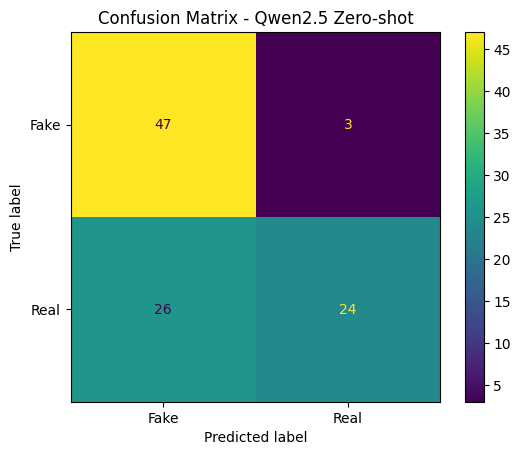


EXEMPLES DE PRÉDICTIONS


,true_label,prediction,answer,latency_seconds,true_class,predicted_class,correct
0,1,1,REAL,0.312084,Real,Real,True
1,1,1,REAL,0.161122,Real,Real,True
2,1,0,FAKE,0.201859,Real,Fake,False
3,0,0,FAKE,0.375069,Fake,Fake,True
4,0,0,FAKE,0.227763,Fake,Fake,True
5,0,0,FAKE,0.174729,Fake,Fake,True
6,0,0,FAKE,0.352020,Fake,Fake,True
7,1,0,FAKE,0.165965,Real,Fake,False
8,0,0,FAKE,0.226434,Fake,Fake,True
9,0,0,FAKE,0.192312,Fake,Fake,True



Nombre d'erreurs : 29


,true_label,prediction,answer,latency_seconds,true_class,predicted_class,correct
2,1,0,FAKE,0.201859,Real,Fake,False
7,1,0,FAKE,0.165965,Real,Fake,False
12,1,0,FAKE,0.429402,Real,Fake,False
16,1,0,FAKE,0.210874,Real,Fake,False
17,1,0,FAKE,0.171230,Real,Fake,False
24,1,0,FAKE,0.173406,Real,Fake,False
28,0,1,REAL,0.218739,Fake,Real,False
29,1,0,FAKE,0.165588,Real,Fake,False
32,1,0,FAKE,0.260354,Real,Fake,False
37,1,0,FAKE,0.165792,Real,Fake,False


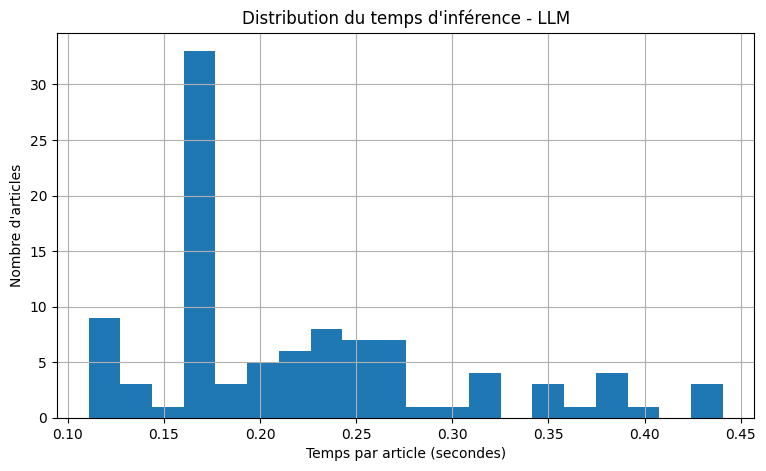


CONFIGURATION LLM
Model : Qwen/Qwen2.5-1.5B-Instruct
Méthode : Zero-shot prompting
Fine-tuning : NON
API : NON
API key : NON
Exécution : Kaggle GPU
Max input tokens : 2048
Max new tokens : 5
Sampling : NON
Coût API : 0


In [12]:
# ================================================================
# LLM OPEN-SOURCE SUR KAGGLE
# ZERO-SHOT FAKE / REAL
#
# Modèle : Qwen2.5-1.5B-Instruct
#
# 0 = Fake
# 1 = Real
#
# PAS D'API KEY
# ================================================================


# ================================================================
# 0. INSTALLATION
# ================================================================

!pip install -q -U transformers accelerate sentencepiece


# ================================================================
# 1. IMPORTS
# ================================================================

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ================================================================
# 2. REPRODUCTIBILITÉ
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ================================================================
# 3. DEVICE
# ================================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("Device :", device)

if torch.cuda.is_available():

    print(
        "GPU :",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# 4. VÉRIFIER test_df
# ================================================================

# Le code suppose que test_df existe déjà.
#
# Il doit contenir :
# content
# label
#
# label :
# 0 = Fake
# 1 = Real


print(
    "\nColonnes test_df :",
    test_df.columns.tolist()
)


assert "content" in test_df.columns, \
    "La colonne content n'existe pas."

assert "label" in test_df.columns, \
    "La colonne label n'existe pas."


print(
    "Nombre total d'articles Test :",
    len(test_df)
)


print(
    "\nDistribution :"
)

print(
    test_df["label"]
    .value_counts()
    .sort_index()
)


# ================================================================
# 5. CRÉER UN ÉCHANTILLON STRATIFIÉ
# ================================================================

# Pour commencer :
# 50 Fake + 50 Real = 100 articles
#
# Quand tout fonctionne :
# mettre N_PER_CLASS = 250
# pour obtenir 500 articles.

N_PER_CLASS = 50


fake_sample = (

    test_df[
        test_df["label"] == 0
    ]

    .sample(
        n=N_PER_CLASS,
        random_state=SEED
    )
)


real_sample = (

    test_df[
        test_df["label"] == 1
    ]

    .sample(
        n=N_PER_CLASS,
        random_state=SEED
    )
)


llm_test = pd.concat(

    [
        fake_sample,
        real_sample
    ],

    ignore_index=True
)


# Mélanger Fake et Real
llm_test = (

    llm_test

    .sample(
        frac=1,
        random_state=SEED
    )

    .reset_index(drop=True)
)


print(
    "\n===================================="
)

print(
    "ÉCHANTILLON LLM"
)

print(
    "===================================="
)


print(
    "Nombre articles :",
    len(llm_test)
)


print(
    "\nDistribution :"
)

print(
    llm_test["label"]
    .value_counts()
    .sort_index()
)


# ================================================================
# 6. MODÈLE LLM
# ================================================================

MODEL_NAME = (
    "Qwen/Qwen2.5-1.5B-Instruct"
)


print(
    "\nModèle :",
    MODEL_NAME
)


# ================================================================
# 7. CHARGER TOKENIZER
# ================================================================

start_loading = time.perf_counter()


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# Si aucun pad token
if tokenizer.pad_token is None:

    tokenizer.pad_token = (
        tokenizer.eos_token
    )


# ================================================================
# 8. CHARGER LE LLM
# ================================================================

if torch.cuda.is_available():

    model = AutoModelForCausalLM.from_pretrained(

        MODEL_NAME,

        torch_dtype=torch.float16,

        device_map="auto"
    )

else:

    model = AutoModelForCausalLM.from_pretrained(

        MODEL_NAME,

        torch_dtype=torch.float32
    )

    model.to(device)


model.eval()


loading_time = (
    time.perf_counter()
    -
    start_loading
)


print(
    "\nLLM chargé."
)

print(
    f"Temps de chargement : "
    f"{loading_time:.2f} secondes"
)


print(
    "Type poids :",
    next(model.parameters()).dtype
)


# ================================================================
# 9. PROMPT SYSTEM
# ================================================================

SYSTEM_PROMPT = """
You are a binary news classification system.

Your task is to classify a news article as either:

FAKE
or
REAL

Return ONLY one word:

FAKE
or
REAL

Do not explain your answer.
Do not add punctuation.
"""


# ================================================================
# 10. FONCTION DE CLASSIFICATION
# ================================================================

def classify_article_llm(
    content,
    model,
    tokenizer
):

    # ------------------------------------------------------------
    # Limiter le texte
    # ------------------------------------------------------------

    content = str(content)


    # ------------------------------------------------------------
    # Messages pour modèle instruct
    # ------------------------------------------------------------

    messages = [

        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },

        {
            "role": "user",
            "content": (
                "Classify the following news article.\n\n"
                f"ARTICLE:\n{content}"
            )
        }
    ]


    # ------------------------------------------------------------
    # Transformer conversation → prompt Qwen
    # ------------------------------------------------------------

    prompt = tokenizer.apply_chat_template(

        messages,

        tokenize=False,

        add_generation_prompt=True
    )


    # ------------------------------------------------------------
    # Tokenisation
    # ------------------------------------------------------------

    inputs = tokenizer(

        prompt,

        return_tensors="pt",

        truncation=True,

        max_length=2048
    )


    # Envoyer sur le device du modèle
    inputs = {

        key: value.to(model.device)

        for key, value in inputs.items()
    }


    # ------------------------------------------------------------
    # Synchroniser GPU avant mesure
    # ------------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.synchronize()


    start = time.perf_counter()


    # ------------------------------------------------------------
    # Génération
    # ------------------------------------------------------------

    with torch.no_grad():

        outputs = model.generate(

            **inputs,

            max_new_tokens=5,

            do_sample=False,

            pad_token_id=tokenizer.eos_token_id
        )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    latency = (
        time.perf_counter()
        -
        start
    )


    # ------------------------------------------------------------
    # Garder uniquement les tokens générés
    # ------------------------------------------------------------

    generated_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]


    answer = tokenizer.decode(

        generated_tokens,

        skip_special_tokens=True
    )


    answer = (
        answer
        .strip()
        .upper()
    )


    # ------------------------------------------------------------
    # Convertir vers labels numériques
    # ------------------------------------------------------------

    if answer.startswith("FAKE"):

        prediction = 0

    elif answer.startswith("REAL"):

        prediction = 1

    else:

        prediction = None


    return (
        prediction,
        answer,
        latency
    )


# ================================================================
# 11. TEST SUR UN SEUL ARTICLE AVANT LE TEST COMPLET
# ================================================================

example = llm_test.iloc[0]


print(
    "\n===================================="
)

print(
    "TEST SUR 1 ARTICLE"
)

print(
    "===================================="
)


prediction, answer, latency = classify_article_llm(

    example["content"],

    model,

    tokenizer
)


print(
    "Vrai label :",
    (
        "Real"
        if example["label"] == 1
        else "Fake"
    )
)


print(
    "Réponse LLM :",
    answer
)


print(
    "Prediction numérique :",
    prediction
)


print(
    f"Temps : {latency:.4f} secondes"
)


# ================================================================
# 12. TEST COMPLET
# ================================================================

llm_predictions = []

llm_true_labels = []

llm_answers = []

llm_latencies = []

valid_indices = []

failed_indices = []


if torch.cuda.is_available():

    torch.cuda.synchronize()


start_total_test = (
    time.perf_counter()
)


print(
    "\n===================================="
)

print(
    "DÉBUT TEST LLM"
)

print(
    "===================================="
)


for i in range(
    len(llm_test)
):


    row = llm_test.iloc[i]


    try:


        prediction, answer, latency = (
            classify_article_llm(

                row["content"],

                model,

                tokenizer
            )
        )


        # --------------------------------------------------------
        # Réponse invalide
        # --------------------------------------------------------

        if prediction is None:

            print(
                f"Réponse invalide article {i}:",
                answer
            )

            failed_indices.append(i)

            continue


        # --------------------------------------------------------
        # Sauvegarder résultats
        # --------------------------------------------------------

        llm_predictions.append(
            prediction
        )


        llm_true_labels.append(
            int(row["label"])
        )


        llm_answers.append(
            answer
        )


        llm_latencies.append(
            latency
        )


        valid_indices.append(
            i
        )


        # --------------------------------------------------------
        # Progression
        # --------------------------------------------------------

        if (
            (i + 1) % 10 == 0
            or i == 0
        ):

            print(

                f"{i+1}/{len(llm_test)}"

                f" | vrai="
                f"{int(row['label'])}"

                f" | prédit="
                f"{prediction}"

                f" | temps="
                f"{latency:.3f}s"
            )


    except Exception as e:


        print(
            f"Erreur article {i}:",
            str(e)
        )


        failed_indices.append(
            i
        )


# ================================================================
# 13. TEMPS TOTAL TEST
# ================================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()


total_test_time = (

    time.perf_counter()

    -
    start_total_test
)


print(
    "\n===================================="
)

print(
    "TEST LLM TERMINÉ"
)

print(
    "===================================="
)


print(
    "Prédictions valides :",
    len(llm_predictions)
)


print(
    "Réponses invalides :",
    len(failed_indices)
)


print(
    f"Temps total Test : "
    f"{total_test_time:.2f} secondes"
)


# ================================================================
# 14. TRANSFORMER EN NUMPY
# ================================================================

y_llm_true = np.array(
    llm_true_labels
)


y_llm_pred = np.array(
    llm_predictions
)


# Vérification
if len(y_llm_true) == 0:

    raise RuntimeError(
        "Aucune prédiction valide."
    )


# ================================================================
# 15. MÉTRIQUES
# ================================================================

llm_accuracy = accuracy_score(

    y_llm_true,

    y_llm_pred
)


llm_balanced_accuracy = (
    balanced_accuracy_score(

        y_llm_true,

        y_llm_pred
    )
)


# ------------------------------------------------
# MACRO
# ------------------------------------------------

llm_precision_macro = (
    precision_score(

        y_llm_true,

        y_llm_pred,

        average="macro",

        zero_division=0
    )
)


llm_recall_macro = (
    recall_score(

        y_llm_true,

        y_llm_pred,

        average="macro",

        zero_division=0
    )
)


llm_f1_macro = (
    f1_score(

        y_llm_true,

        y_llm_pred,

        average="macro",

        zero_division=0
    )
)


# ------------------------------------------------
# WEIGHTED
# ------------------------------------------------

llm_precision_weighted = (
    precision_score(

        y_llm_true,

        y_llm_pred,

        average="weighted",

        zero_division=0
    )
)


llm_recall_weighted = (
    recall_score(

        y_llm_true,

        y_llm_pred,

        average="weighted",

        zero_division=0
    )
)


llm_f1_weighted = (
    f1_score(

        y_llm_true,

        y_llm_pred,

        average="weighted",

        zero_division=0
    )
)


# ------------------------------------------------
# MCC
# ------------------------------------------------

llm_mcc = matthews_corrcoef(

    y_llm_true,

    y_llm_pred
)


# ================================================================
# 16. TEMPS MOYEN / ARTICLE
# ================================================================

average_latency = np.mean(
    llm_latencies
)


median_latency = np.median(
    llm_latencies
)


min_latency = np.min(
    llm_latencies
)


max_latency = np.max(
    llm_latencies
)


# ================================================================
# 17. TABLEAU FINAL
# ================================================================

llm_results = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Balanced Accuracy",

        "Precision Macro",

        "Recall Macro",

        "F1 Macro",

        "Precision Weighted",

        "Recall Weighted",

        "F1 Weighted",

        "MCC",

        "Model Loading Time (s)",

        "Total Test Time (s)",

        "Average Latency / Article (s)",

        "Median Latency / Article (s)",

        "Min Latency / Article (s)",

        "Max Latency / Article (s)",

        "Valid Predictions",

        "Invalid Predictions"
    ],


    "Value": [

        llm_accuracy,

        llm_balanced_accuracy,

        llm_precision_macro,

        llm_recall_macro,

        llm_f1_macro,

        llm_precision_weighted,

        llm_recall_weighted,

        llm_f1_weighted,

        llm_mcc,

        loading_time,

        total_test_time,

        average_latency,

        median_latency,

        min_latency,

        max_latency,

        len(llm_predictions),

        len(failed_indices)
    ]
})


print(
    "\n===================================="
)

print(
    "RÉSULTATS LLM ZERO-SHOT"
)

print(
    "===================================="
)


display(
    llm_results.round(6)
)


# ================================================================
# 18. CLASSIFICATION REPORT
# ================================================================

print(
    "\n===================================="
)

print(
    "CLASSIFICATION REPORT"
)

print(
    "====================================\n"
)


print(

    classification_report(

        y_llm_true,

        y_llm_pred,

        target_names=[
            "Fake",
            "Real"
        ],

        digits=4,

        zero_division=0
    )
)


# ================================================================
# 19. CONFUSION MATRIX
# ================================================================

cm_llm = confusion_matrix(

    y_llm_true,

    y_llm_pred
)


print(
    "\nConfusion Matrix :"
)

print(
    cm_llm
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_llm,

    display_labels=[
        "Fake",
        "Real"
    ]
)


disp.plot()


plt.title(
    "Confusion Matrix - Qwen2.5 Zero-shot"
)


plt.show()


# ================================================================
# 20. TABLEAU DÉTAILLÉ DES PRÉDICTIONS
# ================================================================

llm_output = pd.DataFrame({

    "true_label":
        llm_true_labels,

    "prediction":
        llm_predictions,

    "answer":
        llm_answers,

    "latency_seconds":
        llm_latencies
})


llm_output[
    "true_class"
] = llm_output[
    "true_label"
].map({

    0: "Fake",

    1: "Real"
})


llm_output[
    "predicted_class"
] = llm_output[
    "prediction"
].map({

    0: "Fake",

    1: "Real"
})


llm_output[
    "correct"
] = (

    llm_output[
        "true_label"
    ]

    ==

    llm_output[
        "prediction"
    ]
)


print(
    "\n===================================="
)

print(
    "EXEMPLES DE PRÉDICTIONS"
)

print(
    "===================================="
)


display(
    llm_output.head(20)
)


# ================================================================
# 21. AFFICHER UNIQUEMENT LES ERREURS
# ================================================================

llm_errors = (

    llm_output[

        llm_output[
            "correct"
        ] == False

    ]

    .copy()
)


print(
    "\nNombre d'erreurs :",
    len(llm_errors)
)


display(
    llm_errors.head(30)
)


# ================================================================
# 22. LATENCE - DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(9, 5)
)


plt.hist(
    llm_latencies,
    bins=20
)


plt.xlabel(
    "Temps par article (secondes)"
)


plt.ylabel(
    "Nombre d'articles"
)


plt.title(
    "Distribution du temps d'inférence - LLM"
)


plt.grid()


plt.show()


# ================================================================
# 23. RÉSUMÉ FINAL
# ================================================================

print(
    "\n===================================="
)

print(
    "CONFIGURATION LLM"
)

print(
    "===================================="
)


print(
    "Model :",
    MODEL_NAME
)

print(
    "Méthode : Zero-shot prompting"
)

print(
    "Fine-tuning : NON"
)

print(
    "API : NON"
)

print(
    "API key : NON"
)

print(
    "Exécution : Kaggle GPU"
)

print(
    "Max input tokens : 2048"
)

print(
    "Max new tokens : 5"
)

print(
    "Sampling : NON"
)

print(
    "Coût API : 0"
)